In [1]:
import json
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

from traev.analysis.scoring import enumerate_env_list, show_score_results
from traev.analysis.sensitivity import load_sensitivity, show_sensitivity_results
from traev.analysis.clustering import summarize_favorable_rs_ts_clusters

warnings.filterwarnings("ignore")

sns.set_theme(
    context='paper',
    style='ticks',
    palette='muted',
    font='sans-serif',
    font_scale=2,
    rc={'figure.figsize': (10, 6)},
)


In [2]:
RESULTS_DIR = Path('results')
PIGMENT_RESULTS_DIR = RESULTS_DIR / 'pigment_sensitivity' / 'ra_0009'
AROMATIC_RESULTS_DIR = RESULTS_DIR / 'aromatic_sensitivity' / 'ra_0009'
PIGMENT_SENSITIVITY_DIR = RESULTS_DIR / 'pigment_sensitivity'
AROMATIC_SENSITIVITY_DIR = RESULTS_DIR / 'aromatic_sensitivity'
SENSITIVITY_CONFIG_PATH = Path("sensitivity_config.json")
K_MIN = 1
env_df = pd.read_csv('data/ale_envs.csv', index_col=0)


# 1 Pigment

In [3]:
pigment_names = ['Bikaverin', 'Indigoidine']
pigment_colors = ['#B52A5C', '#2D3E90']

PIGMENT_SCORE_KWARGS = dict(
    env_df=env_df,
    env_list=pigment_names,
    n_mutations=50,
    k_min=K_MIN,
    same_desired_trait=False,
    colors=pigment_colors,
)


## 1.1 Experimental results (Kakko von Koch et al., 2025)

In [4]:
def plot_experimental_results(pigment_names, colors, medium_name, input_dir='data/pigment_exp_results', output_dir=str(PIGMENT_RESULTS_DIR / 'figures')):
    for i, pigment_name in enumerate(pigment_names):
        data = pd.read_csv(f'{input_dir}/{pigment_name.lower()}_{medium_name.lower()}.csv')

        replicate_columns = ['Replicate Producing 1', 'Replicate Producing 2', 'Replicate Producing 3', 'Replicate Producing 4']
        data['Mean'] = data[replicate_columns].mean(axis=1)
        data['StdError'] = data[replicate_columns].sem(axis=1)

        x = data['Transfer'].values.reshape(-1, 1)
        y = data['Mean'].values
        error = data['StdError'].values
        color = colors[i % len(colors)]

        plt.errorbar(x, y, yerr=error, fmt='o', elinewidth=2, capsize=5, color=color, label=pigment_name.capitalize())
        plt.plot(x, y, linestyle='-', color=color, linewidth=1.5)

    plt.xlabel('Transfer')
    plt.ylabel('Replicate Producing %')
    plt.legend([mpatches.Patch(color=c) for c in colors], pigment_names, fontsize=16)

    plt.tight_layout()
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    output_path = Path(output_dir) / f'{medium_name.lower()}_exp_results.png'
    plt.savefig(output_path, bbox_inches='tight', dpi=300)
    plt.close()
    display(Image(filename=str(output_path), width=600))


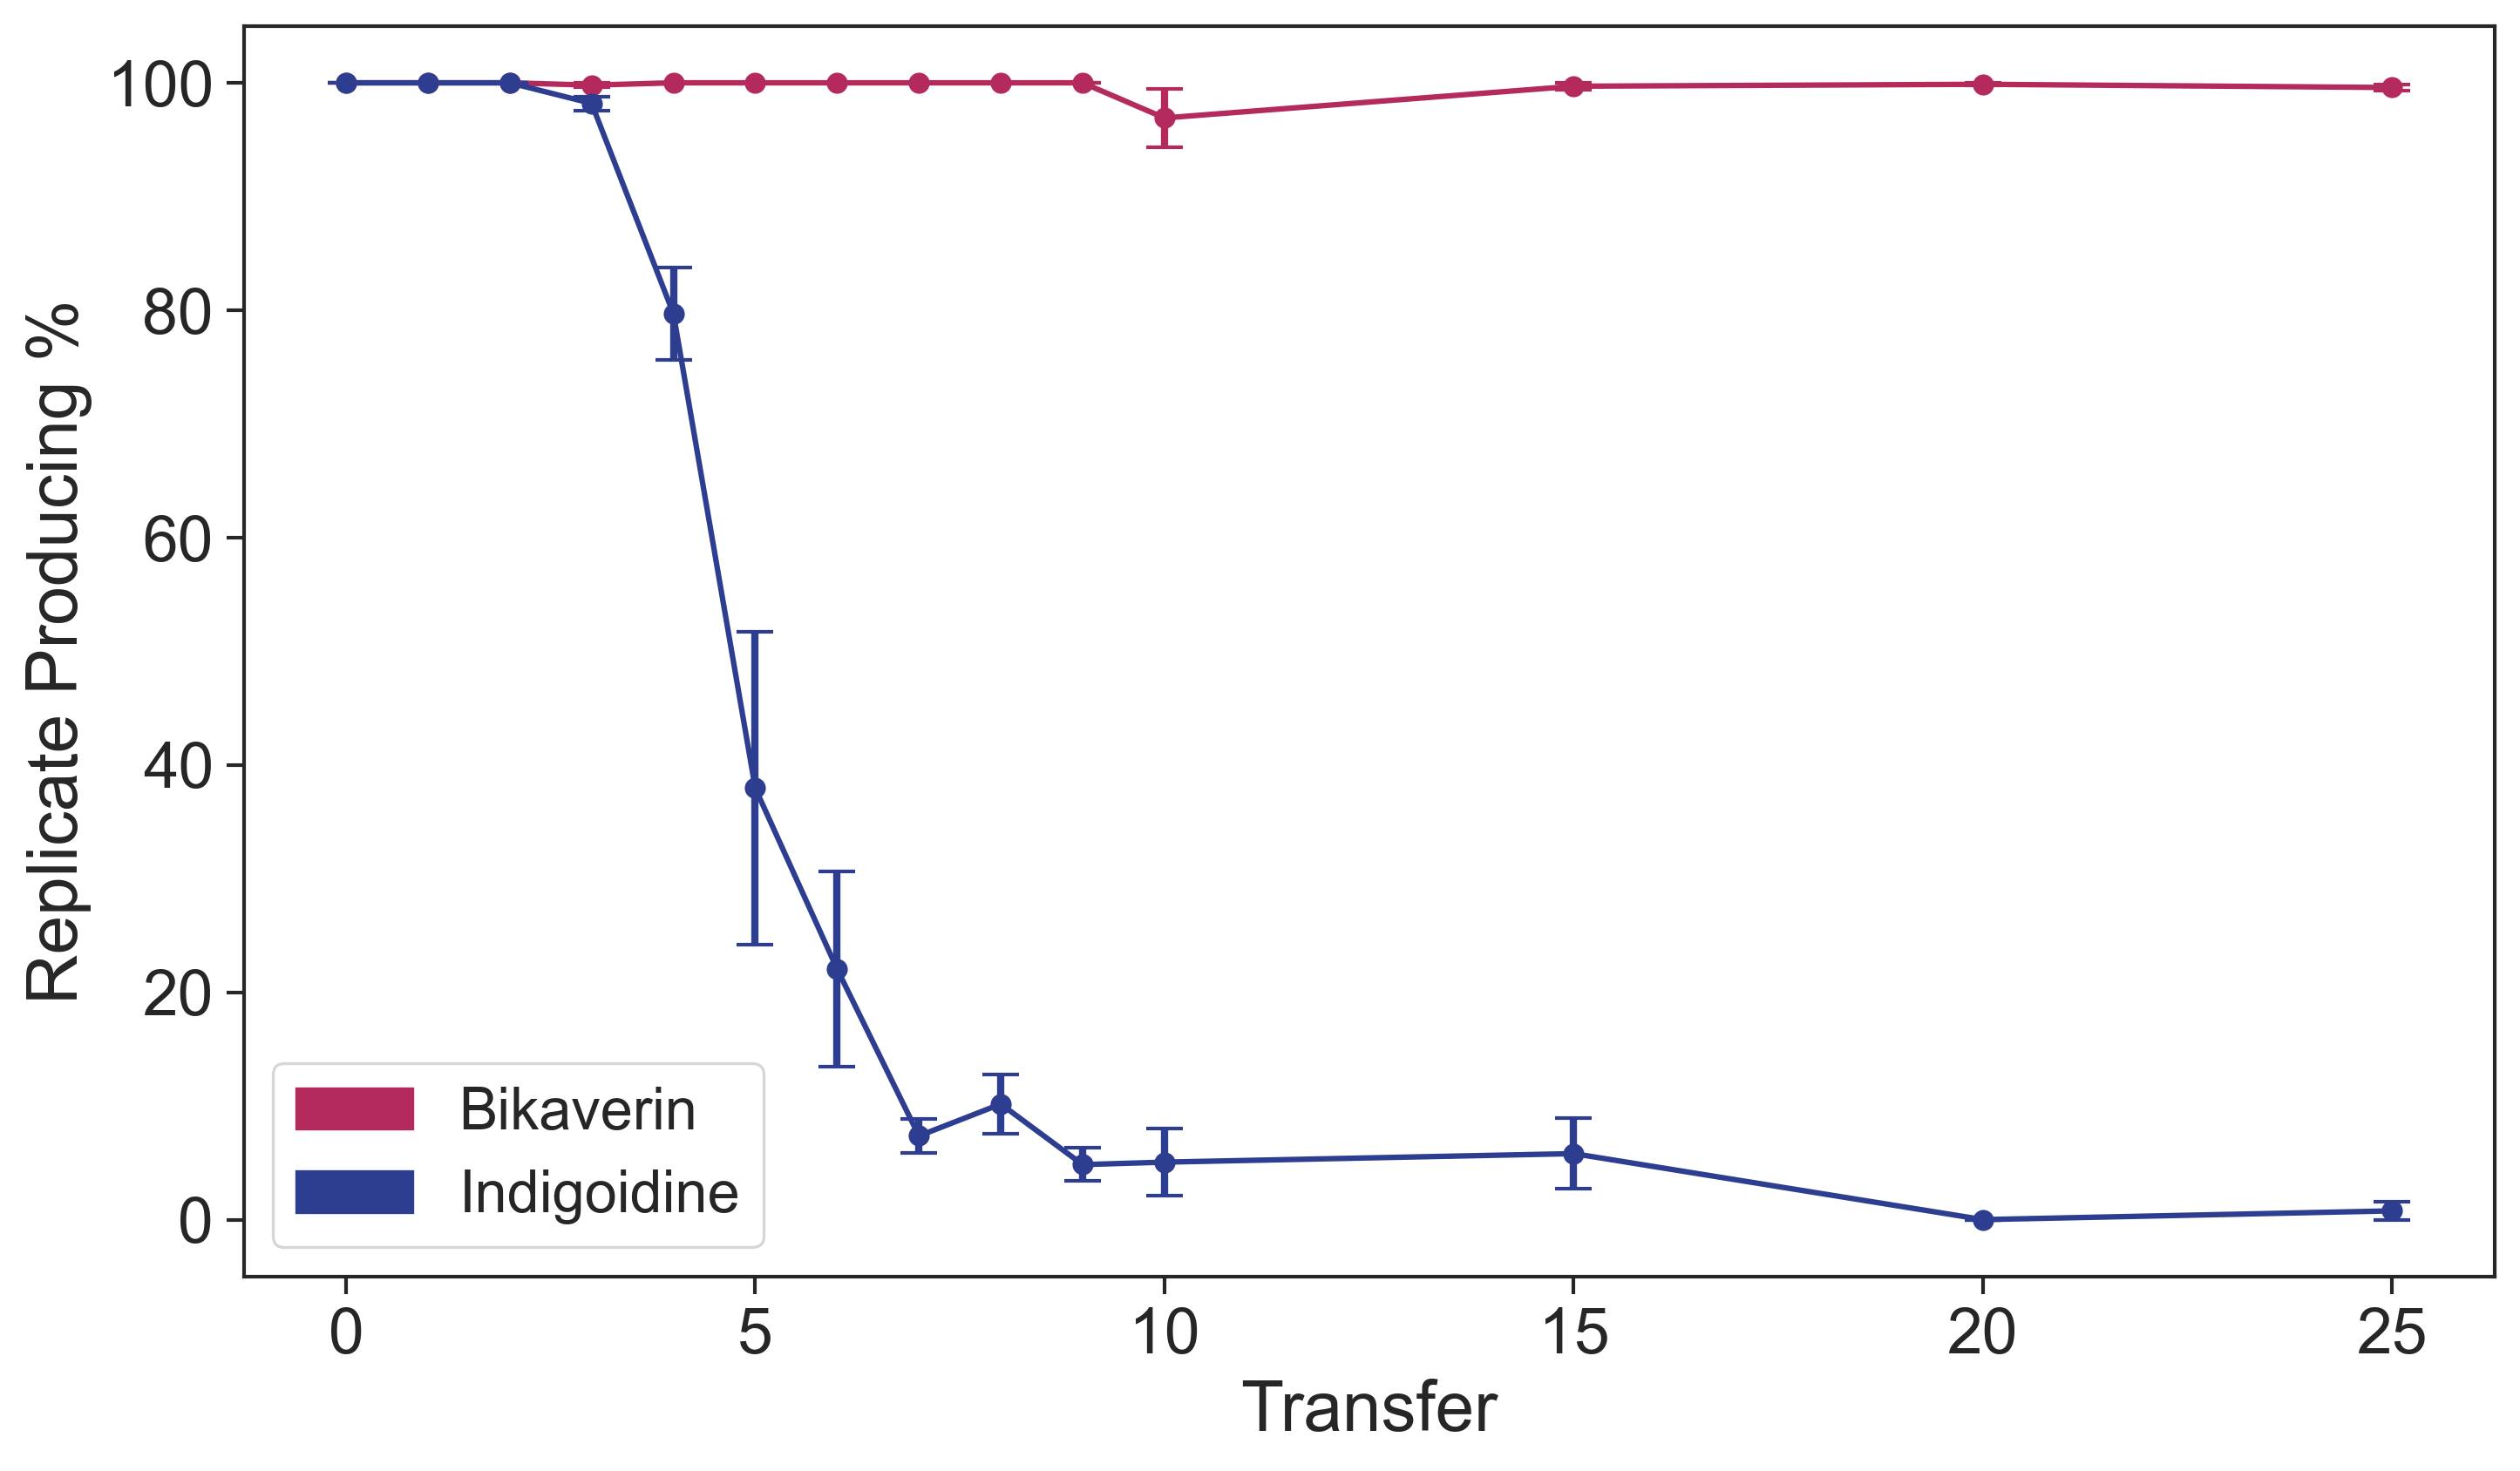

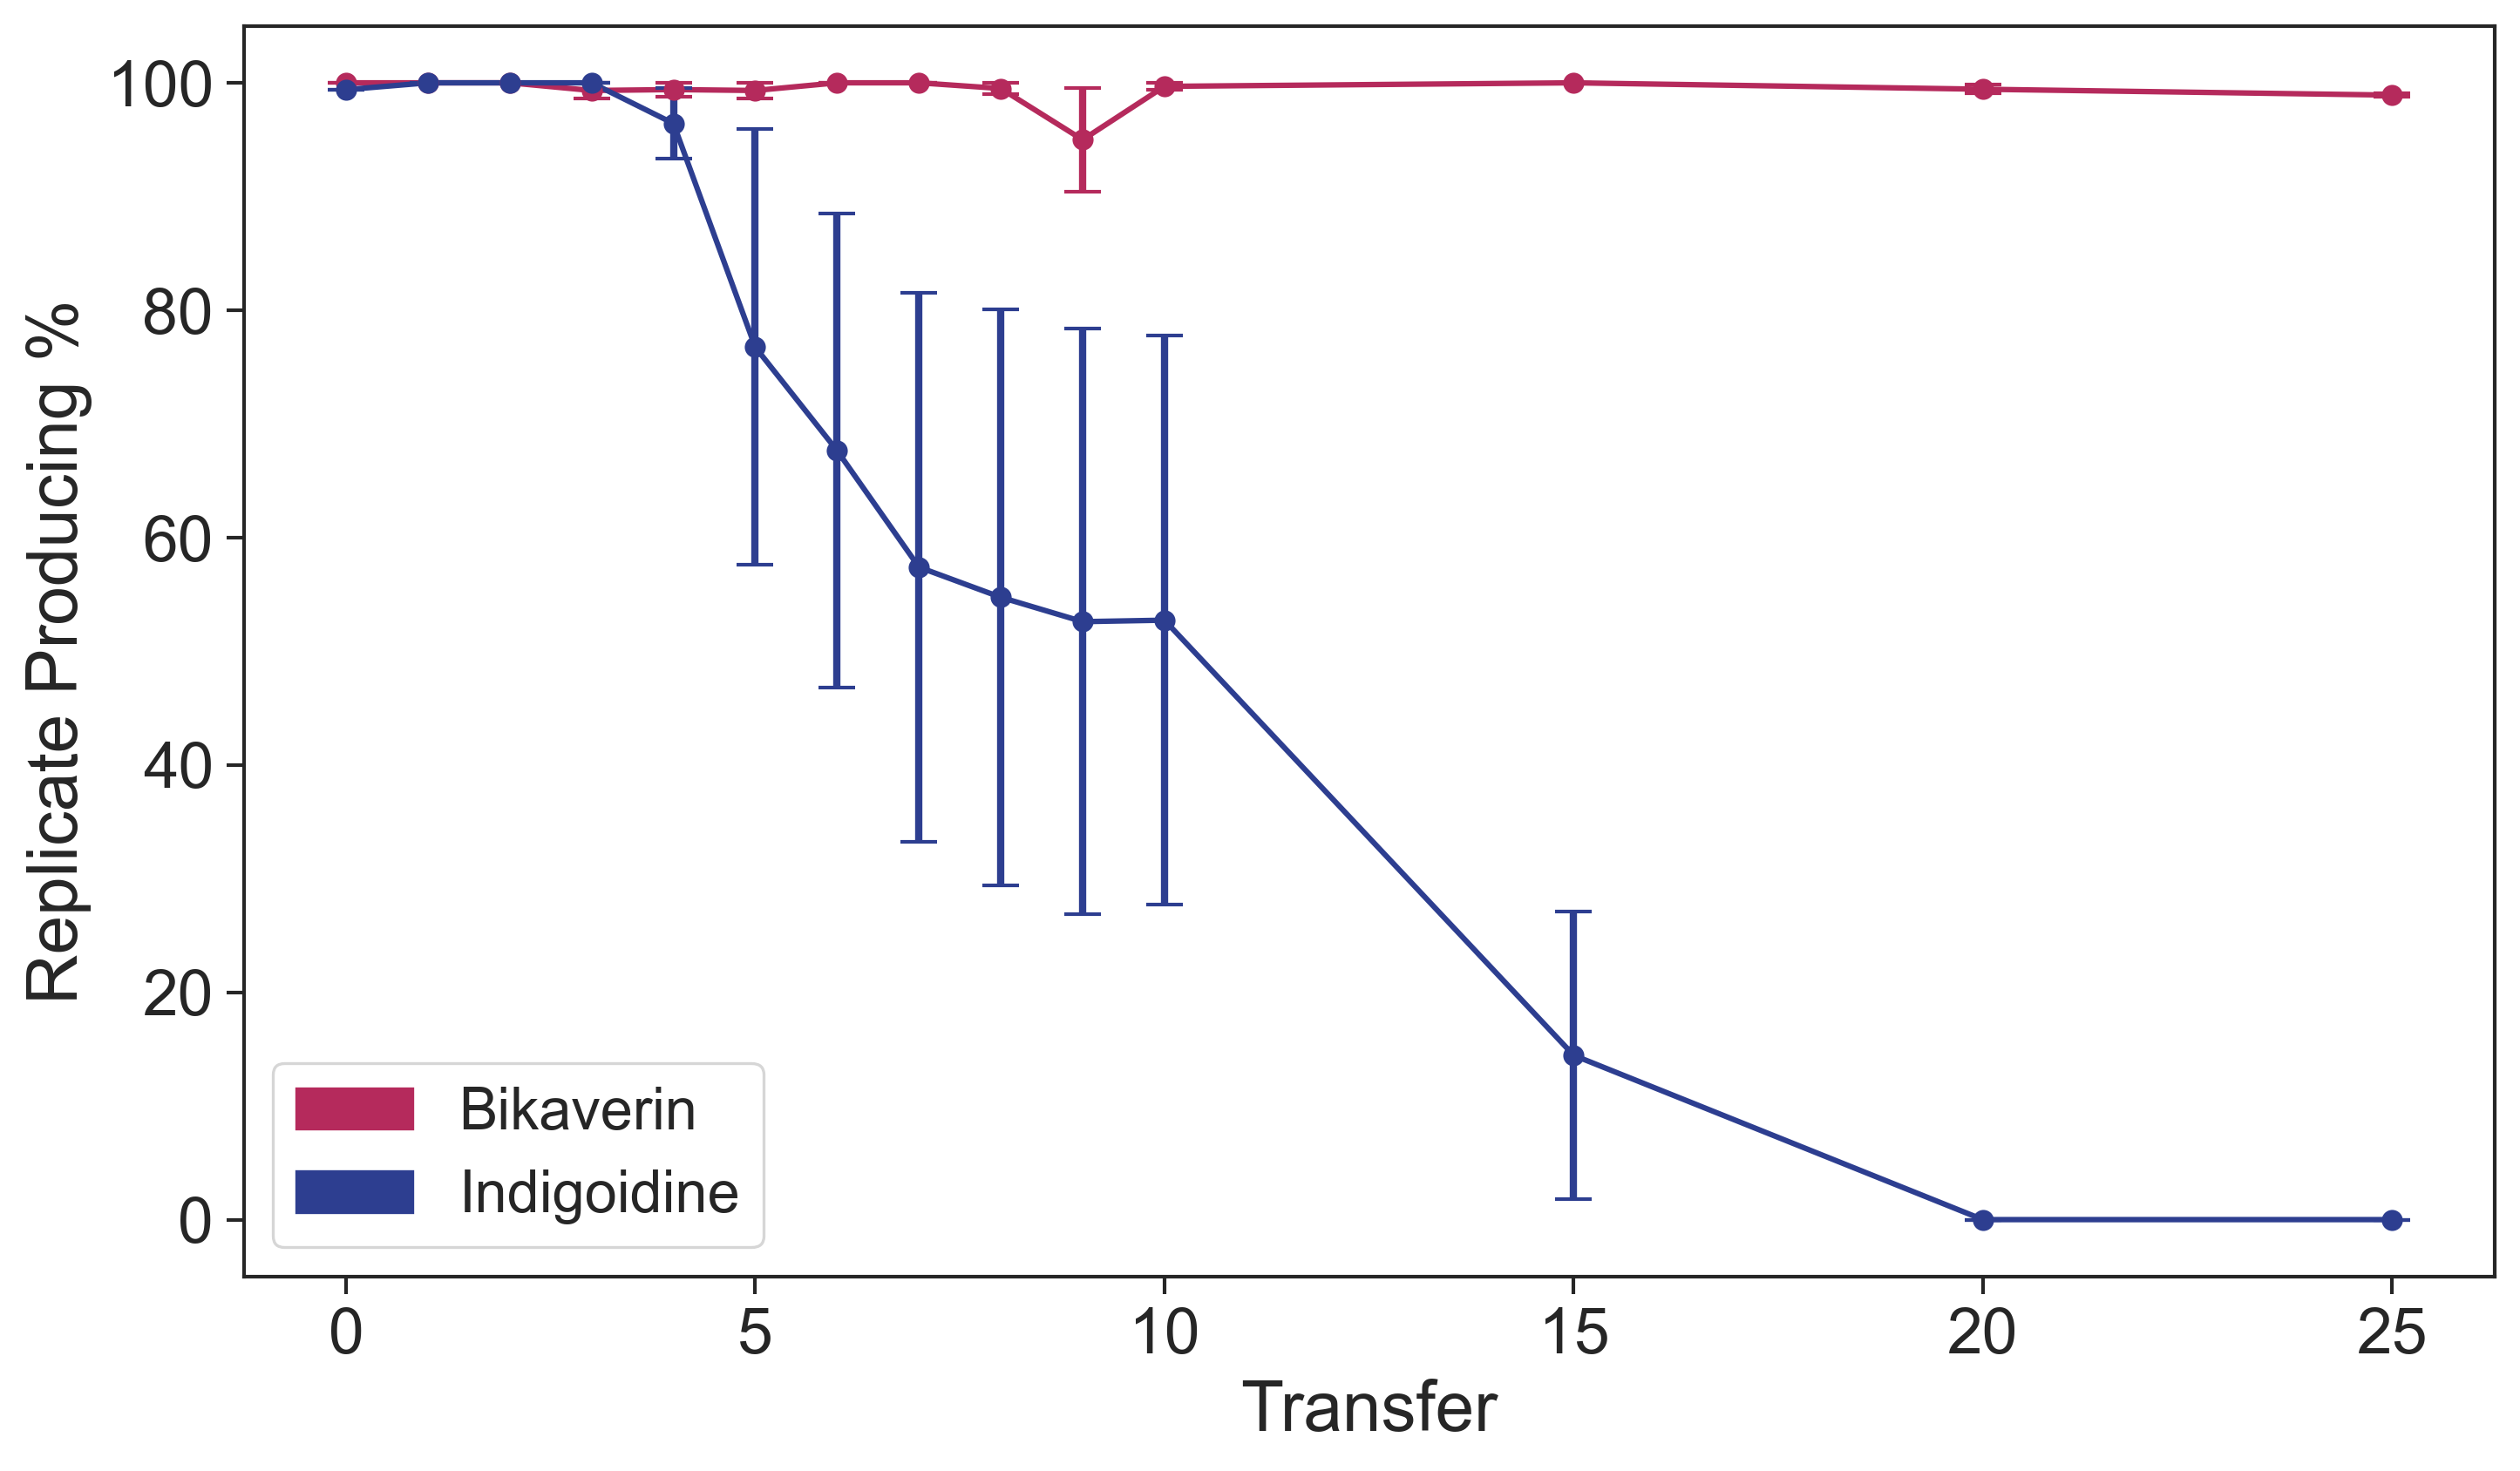

In [5]:
plot_experimental_results(pigment_names, pigment_colors, 'YNB')
plot_experimental_results(pigment_names, pigment_colors, 'YP')

## 1.2 Predictive results

['Bikaverin (Bikaverin) (RS = $4.75\\times 10^{-2}$, TS = $-5.63\\times 10^{-1}$)', 'Indigoidine (Indigoidine) (RS = $1.32\\times 10^{-2}$, TS = $-8.36\\times 10^{-1}$)']


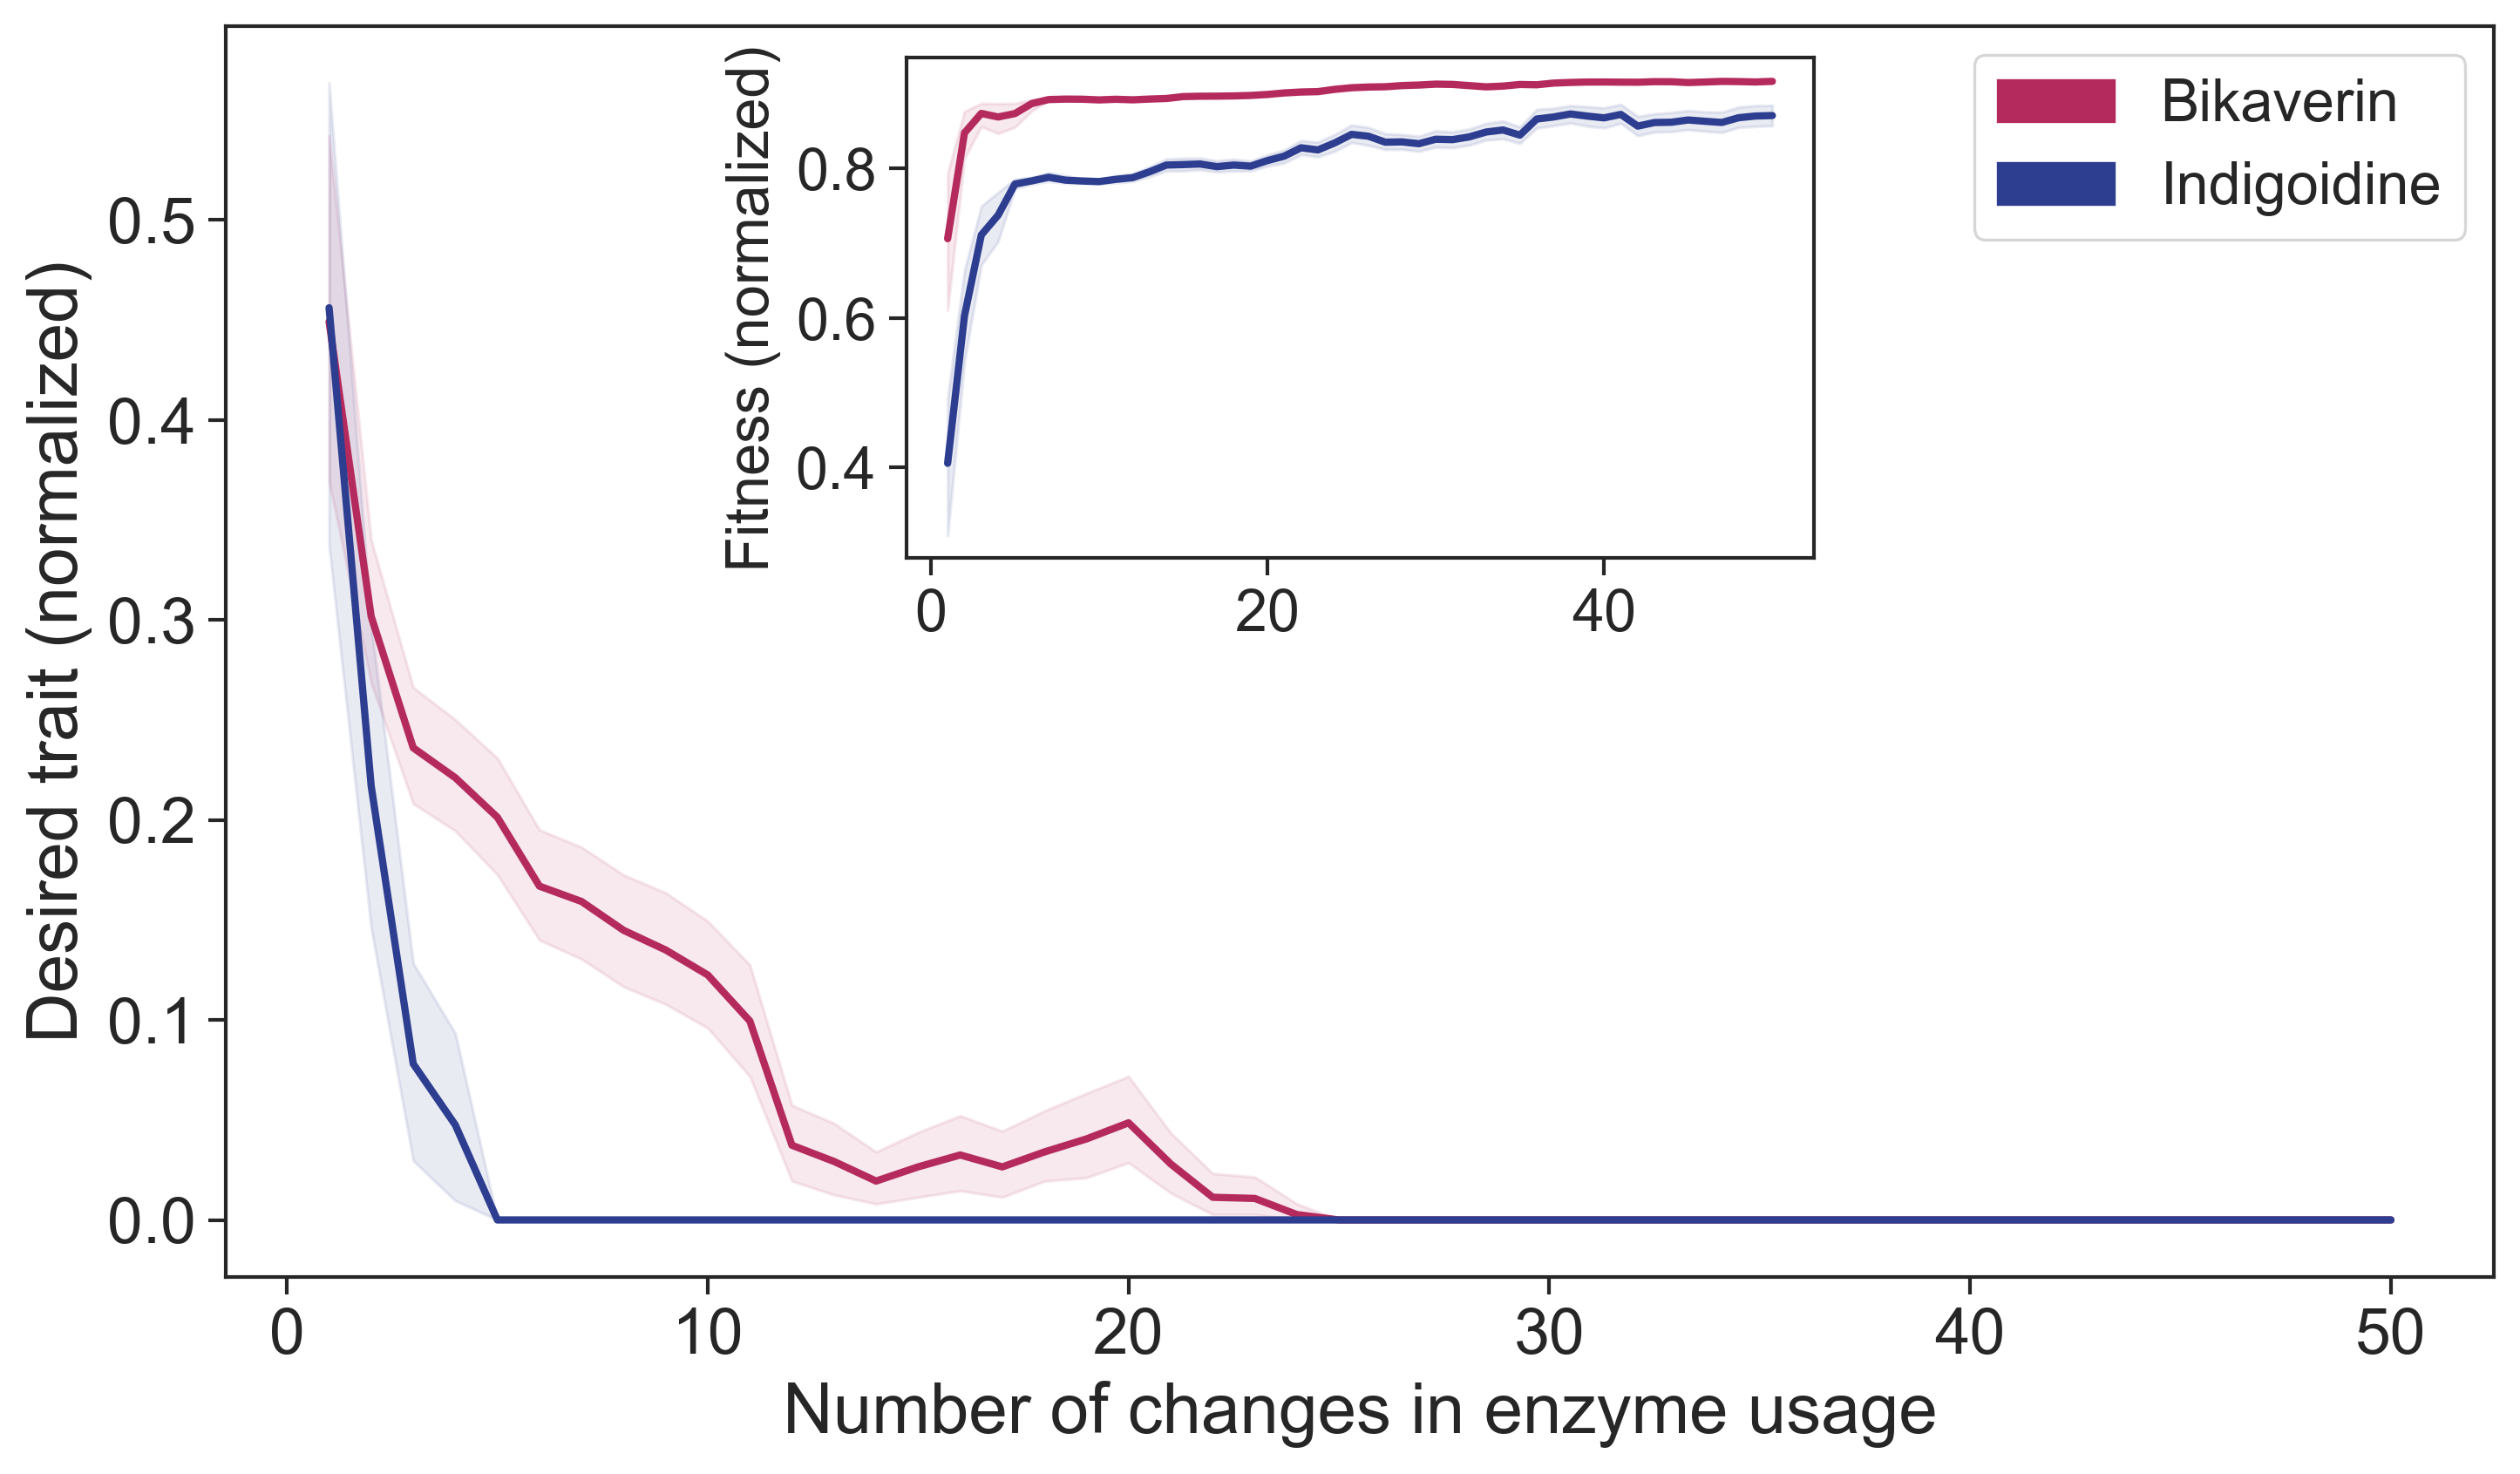

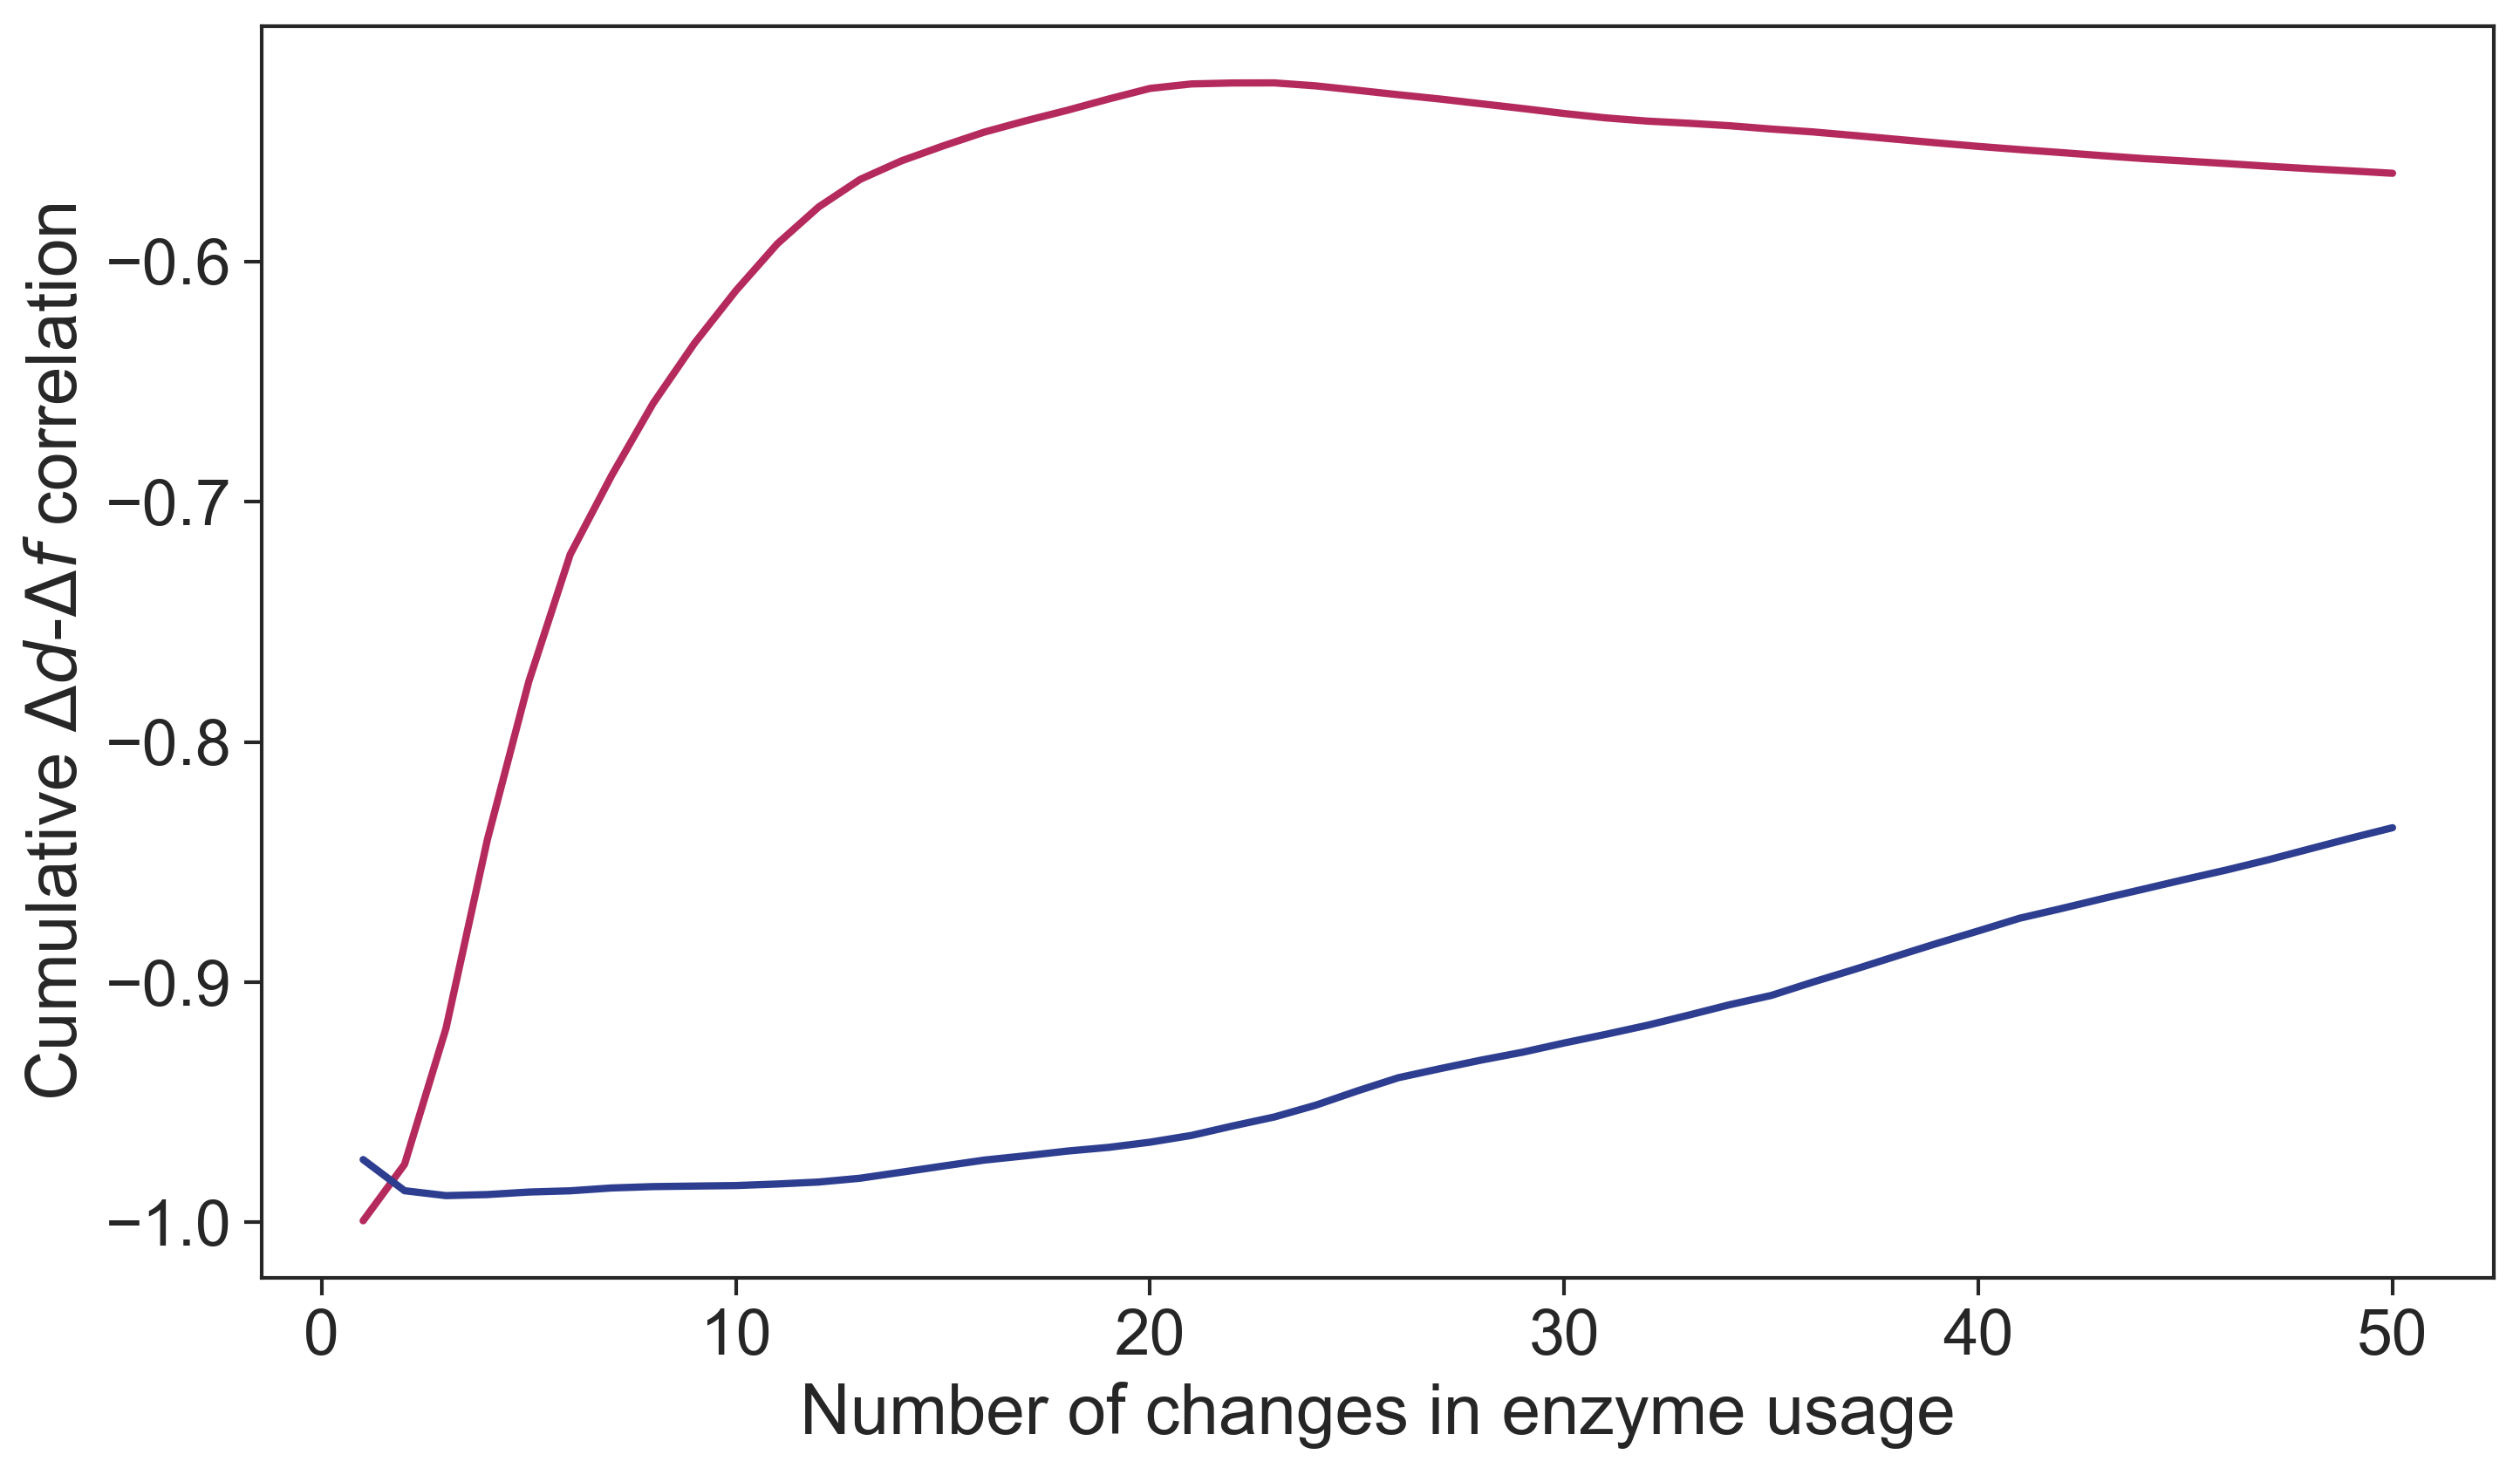

In [6]:
show_score_results(
    input_dir=str(PIGMENT_RESULTS_DIR / 'YNB'),
    **PIGMENT_SCORE_KWARGS,
);


['Bikaverin (Bikaverin) (RS = $2.84\\times 10^{-2}$, TS = $-3.26\\times 10^{-1}$)', 'Indigoidine (Indigoidine) (RS = $9.57\\times 10^{-3}$, TS = $-7.54\\times 10^{-1}$)']


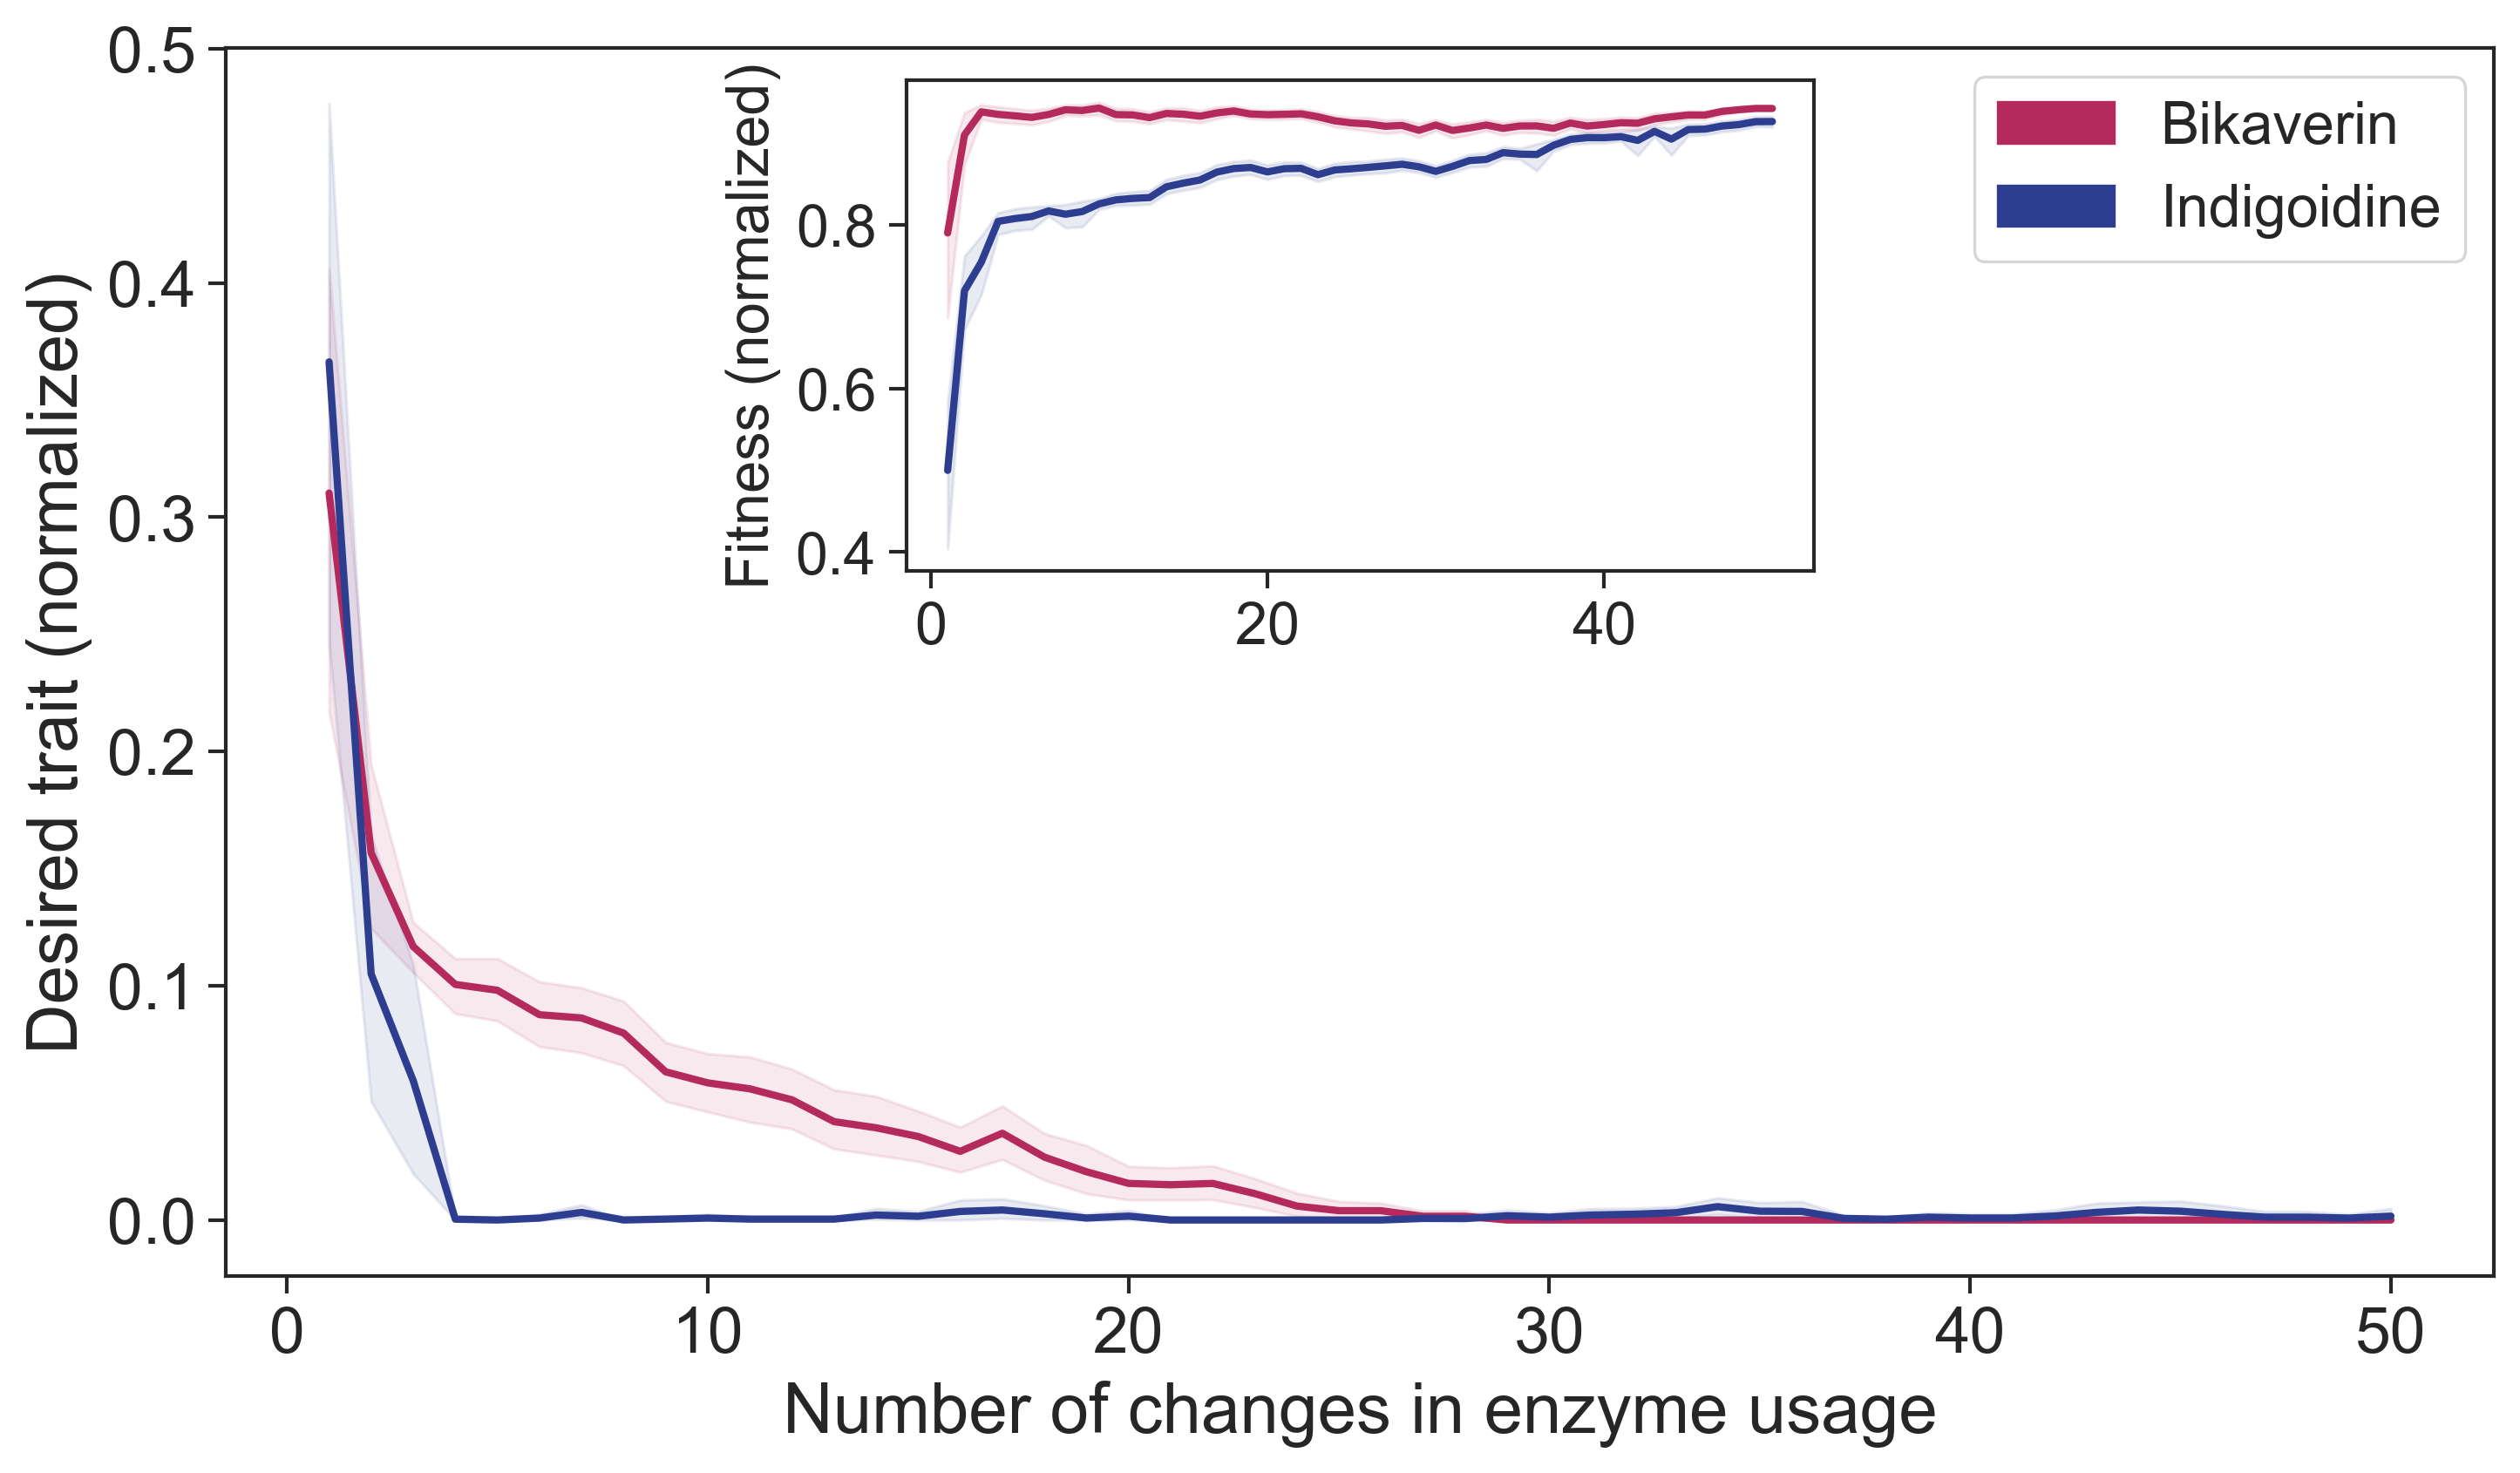

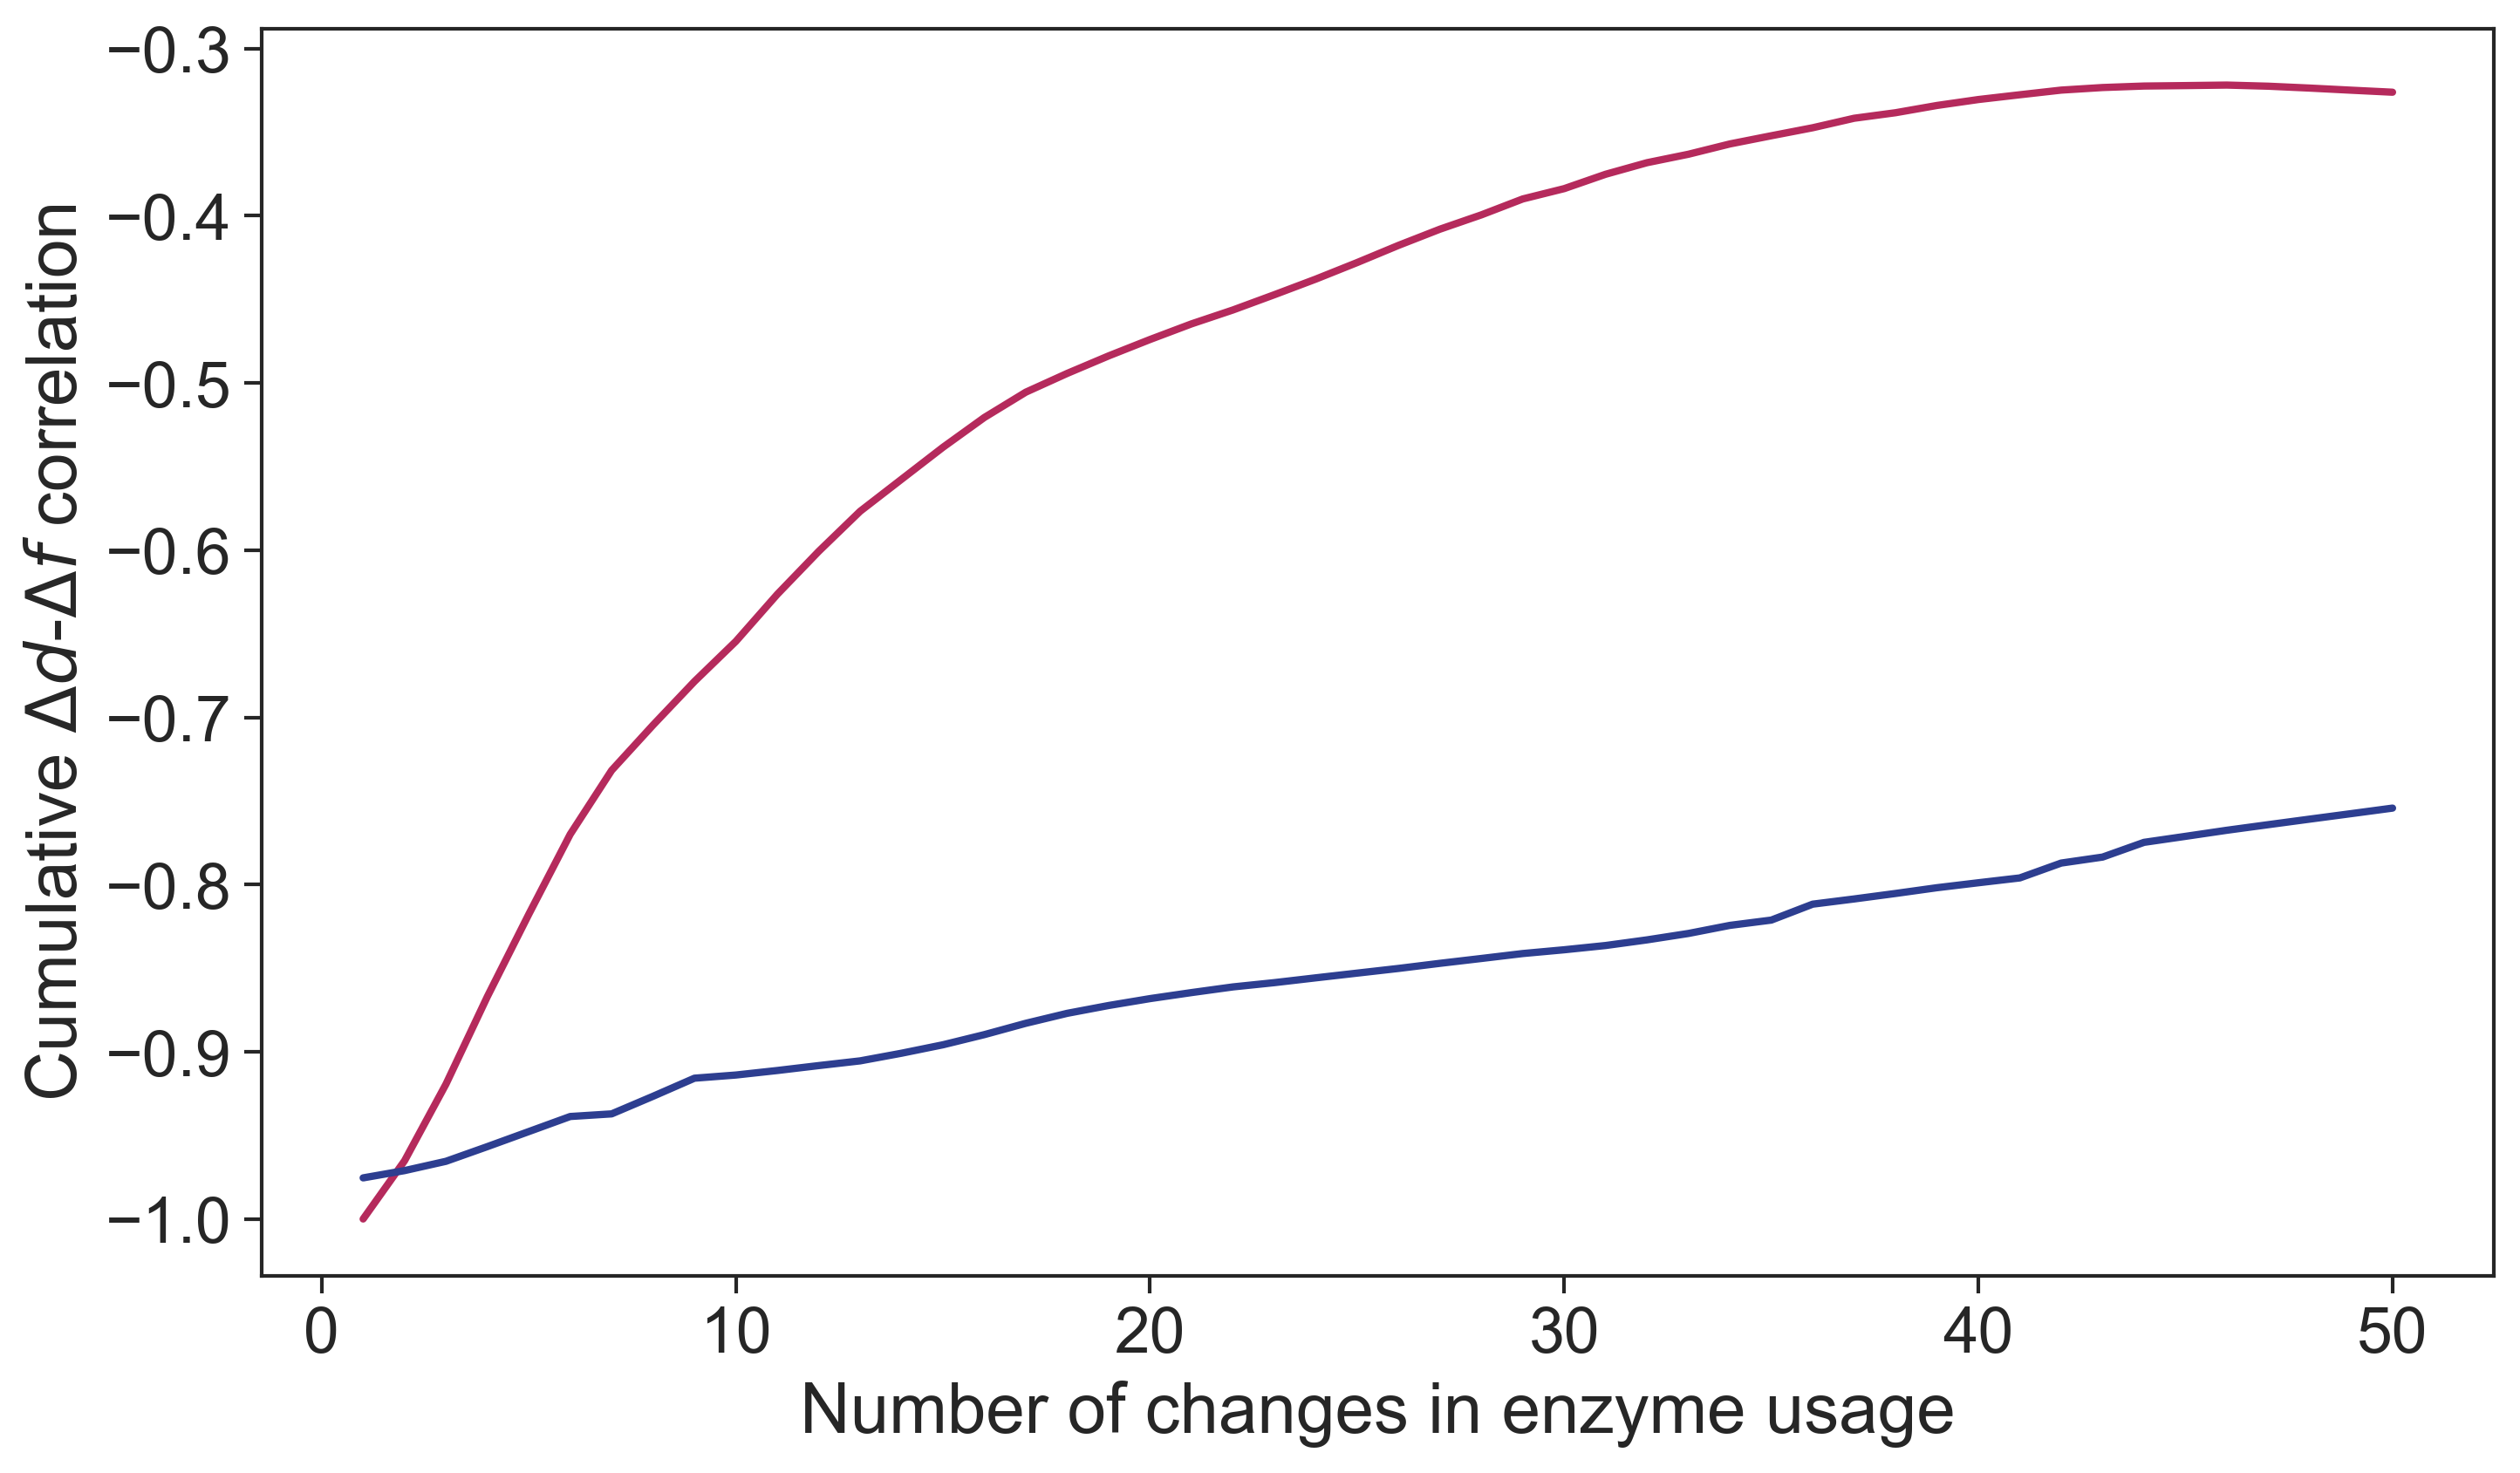

In [7]:
show_score_results(
    input_dir=str(PIGMENT_RESULTS_DIR / 'YP'),
    **PIGMENT_SCORE_KWARGS,
);


## 1.3 Sensitivity analysis

In [8]:
def prepare_pigment_sensitivity_summary(medium, base_dir=PIGMENT_SENSITIVITY_DIR):
    return load_sensitivity(
        facet_value=medium,
        base_dir=base_dir,
        subdir_name=medium,
        ra_pattern='*_ra_results.csv',
        id_from_path=lambda path: path.stem.replace('_ra_results', ''),
        same_desired_trait=False,
        facet_col='medium',
        sort_cols=['medium', 'group_id', 'n_mutations', 'n_samples'],
        should_include_run=lambda params: medium in params.get('mediums', ['YNB', 'YP']),
    )


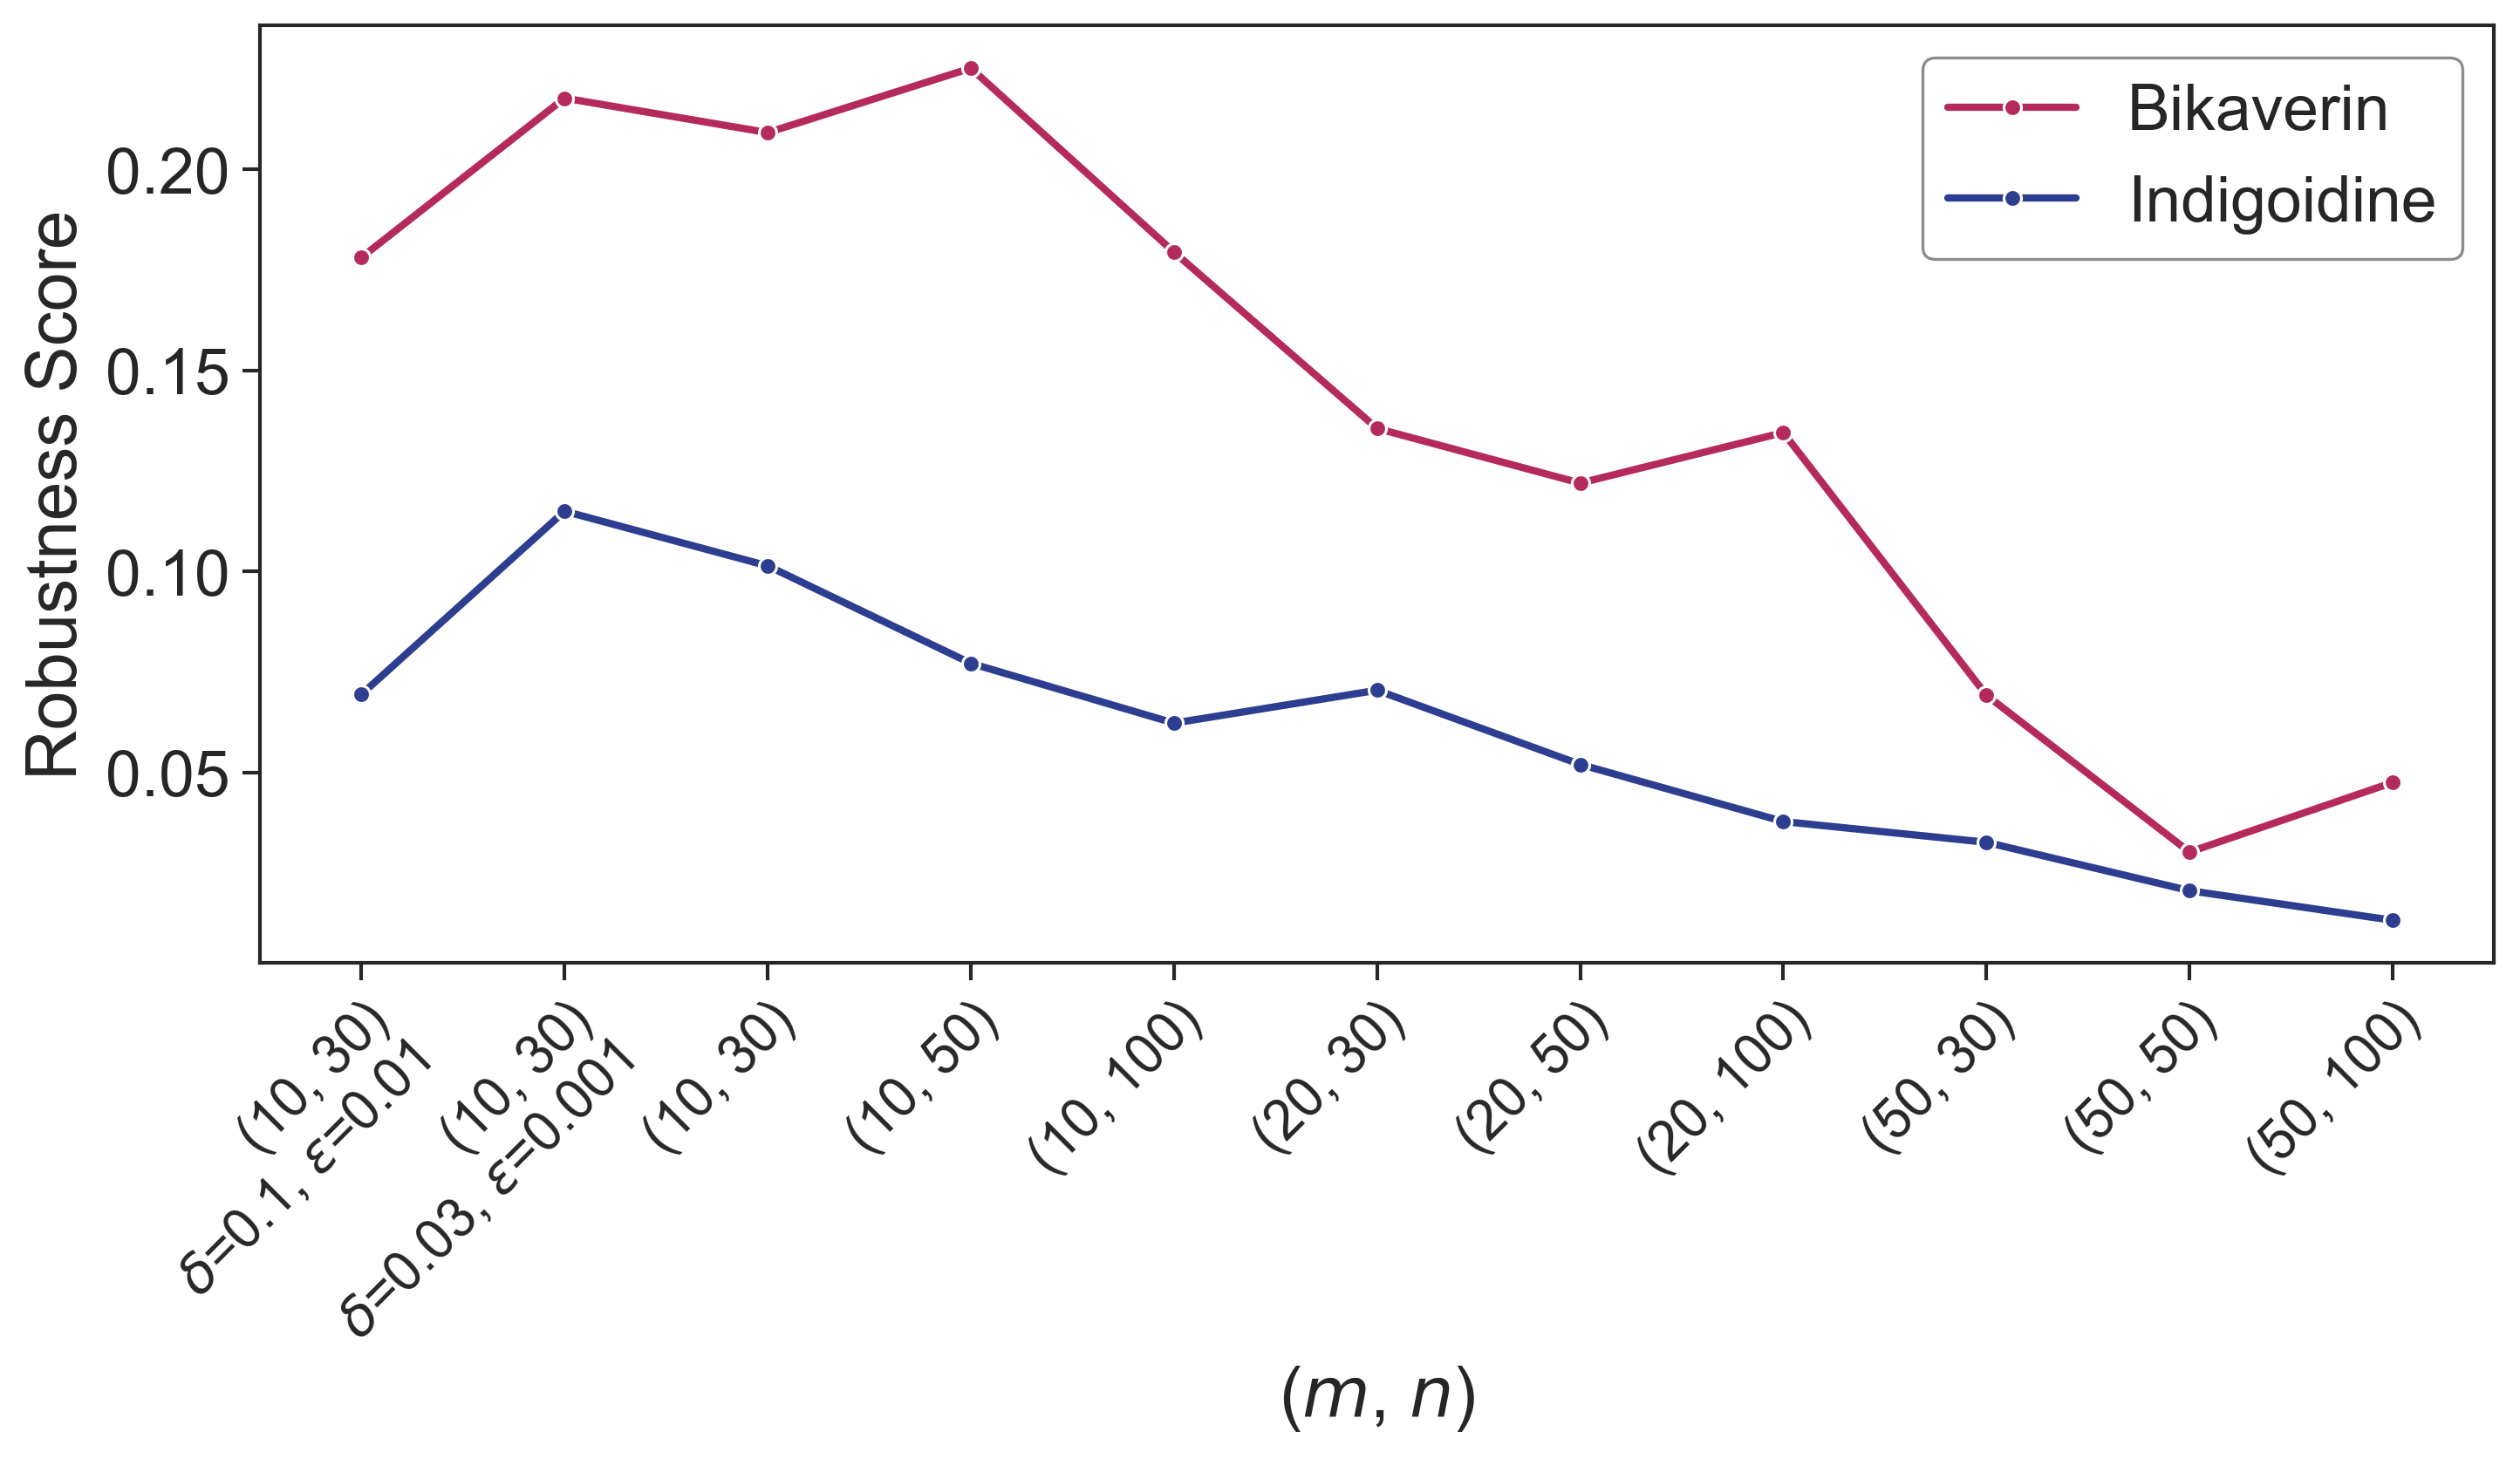

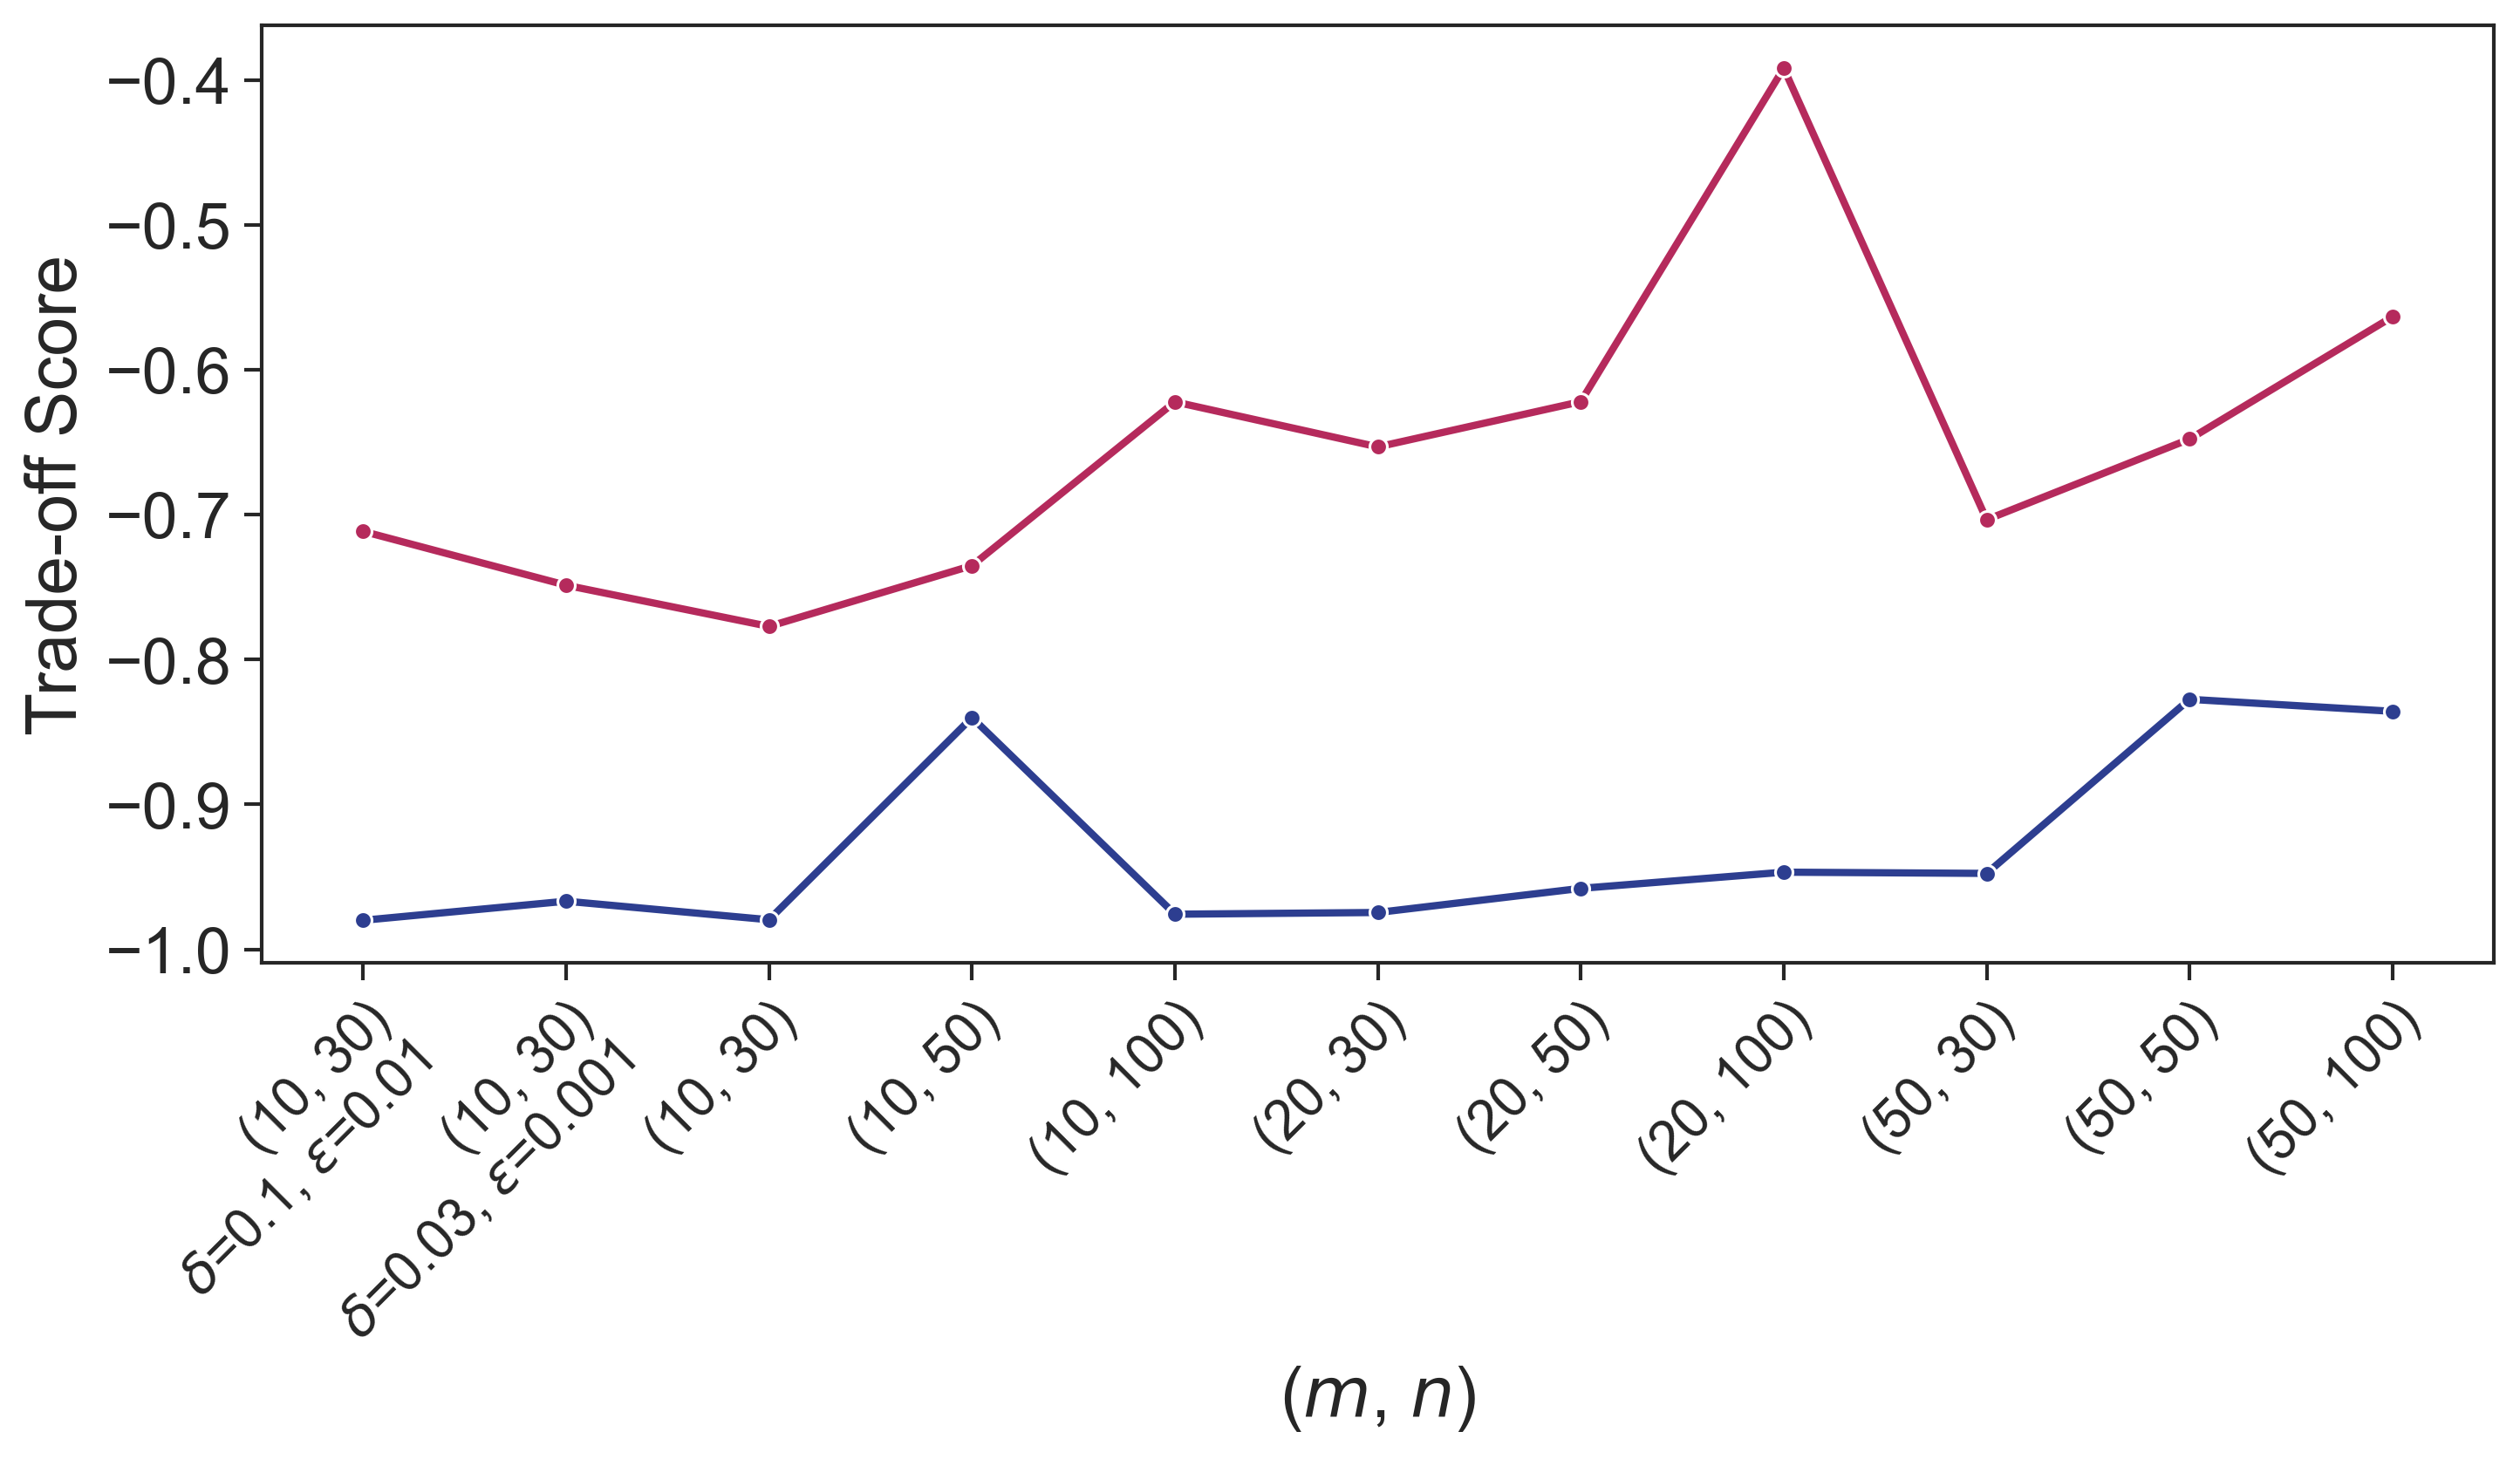

In [9]:
show_sensitivity_results(
    prepare_pigment_sensitivity_summary('YNB'),
    PIGMENT_SENSITIVITY_DIR,
    'ynb_pigment',
    [name.lower() for name in pigment_names],
    dict(zip([name.lower() for name in pigment_names], pigment_colors)),
    legend_labels=pigment_names,
);


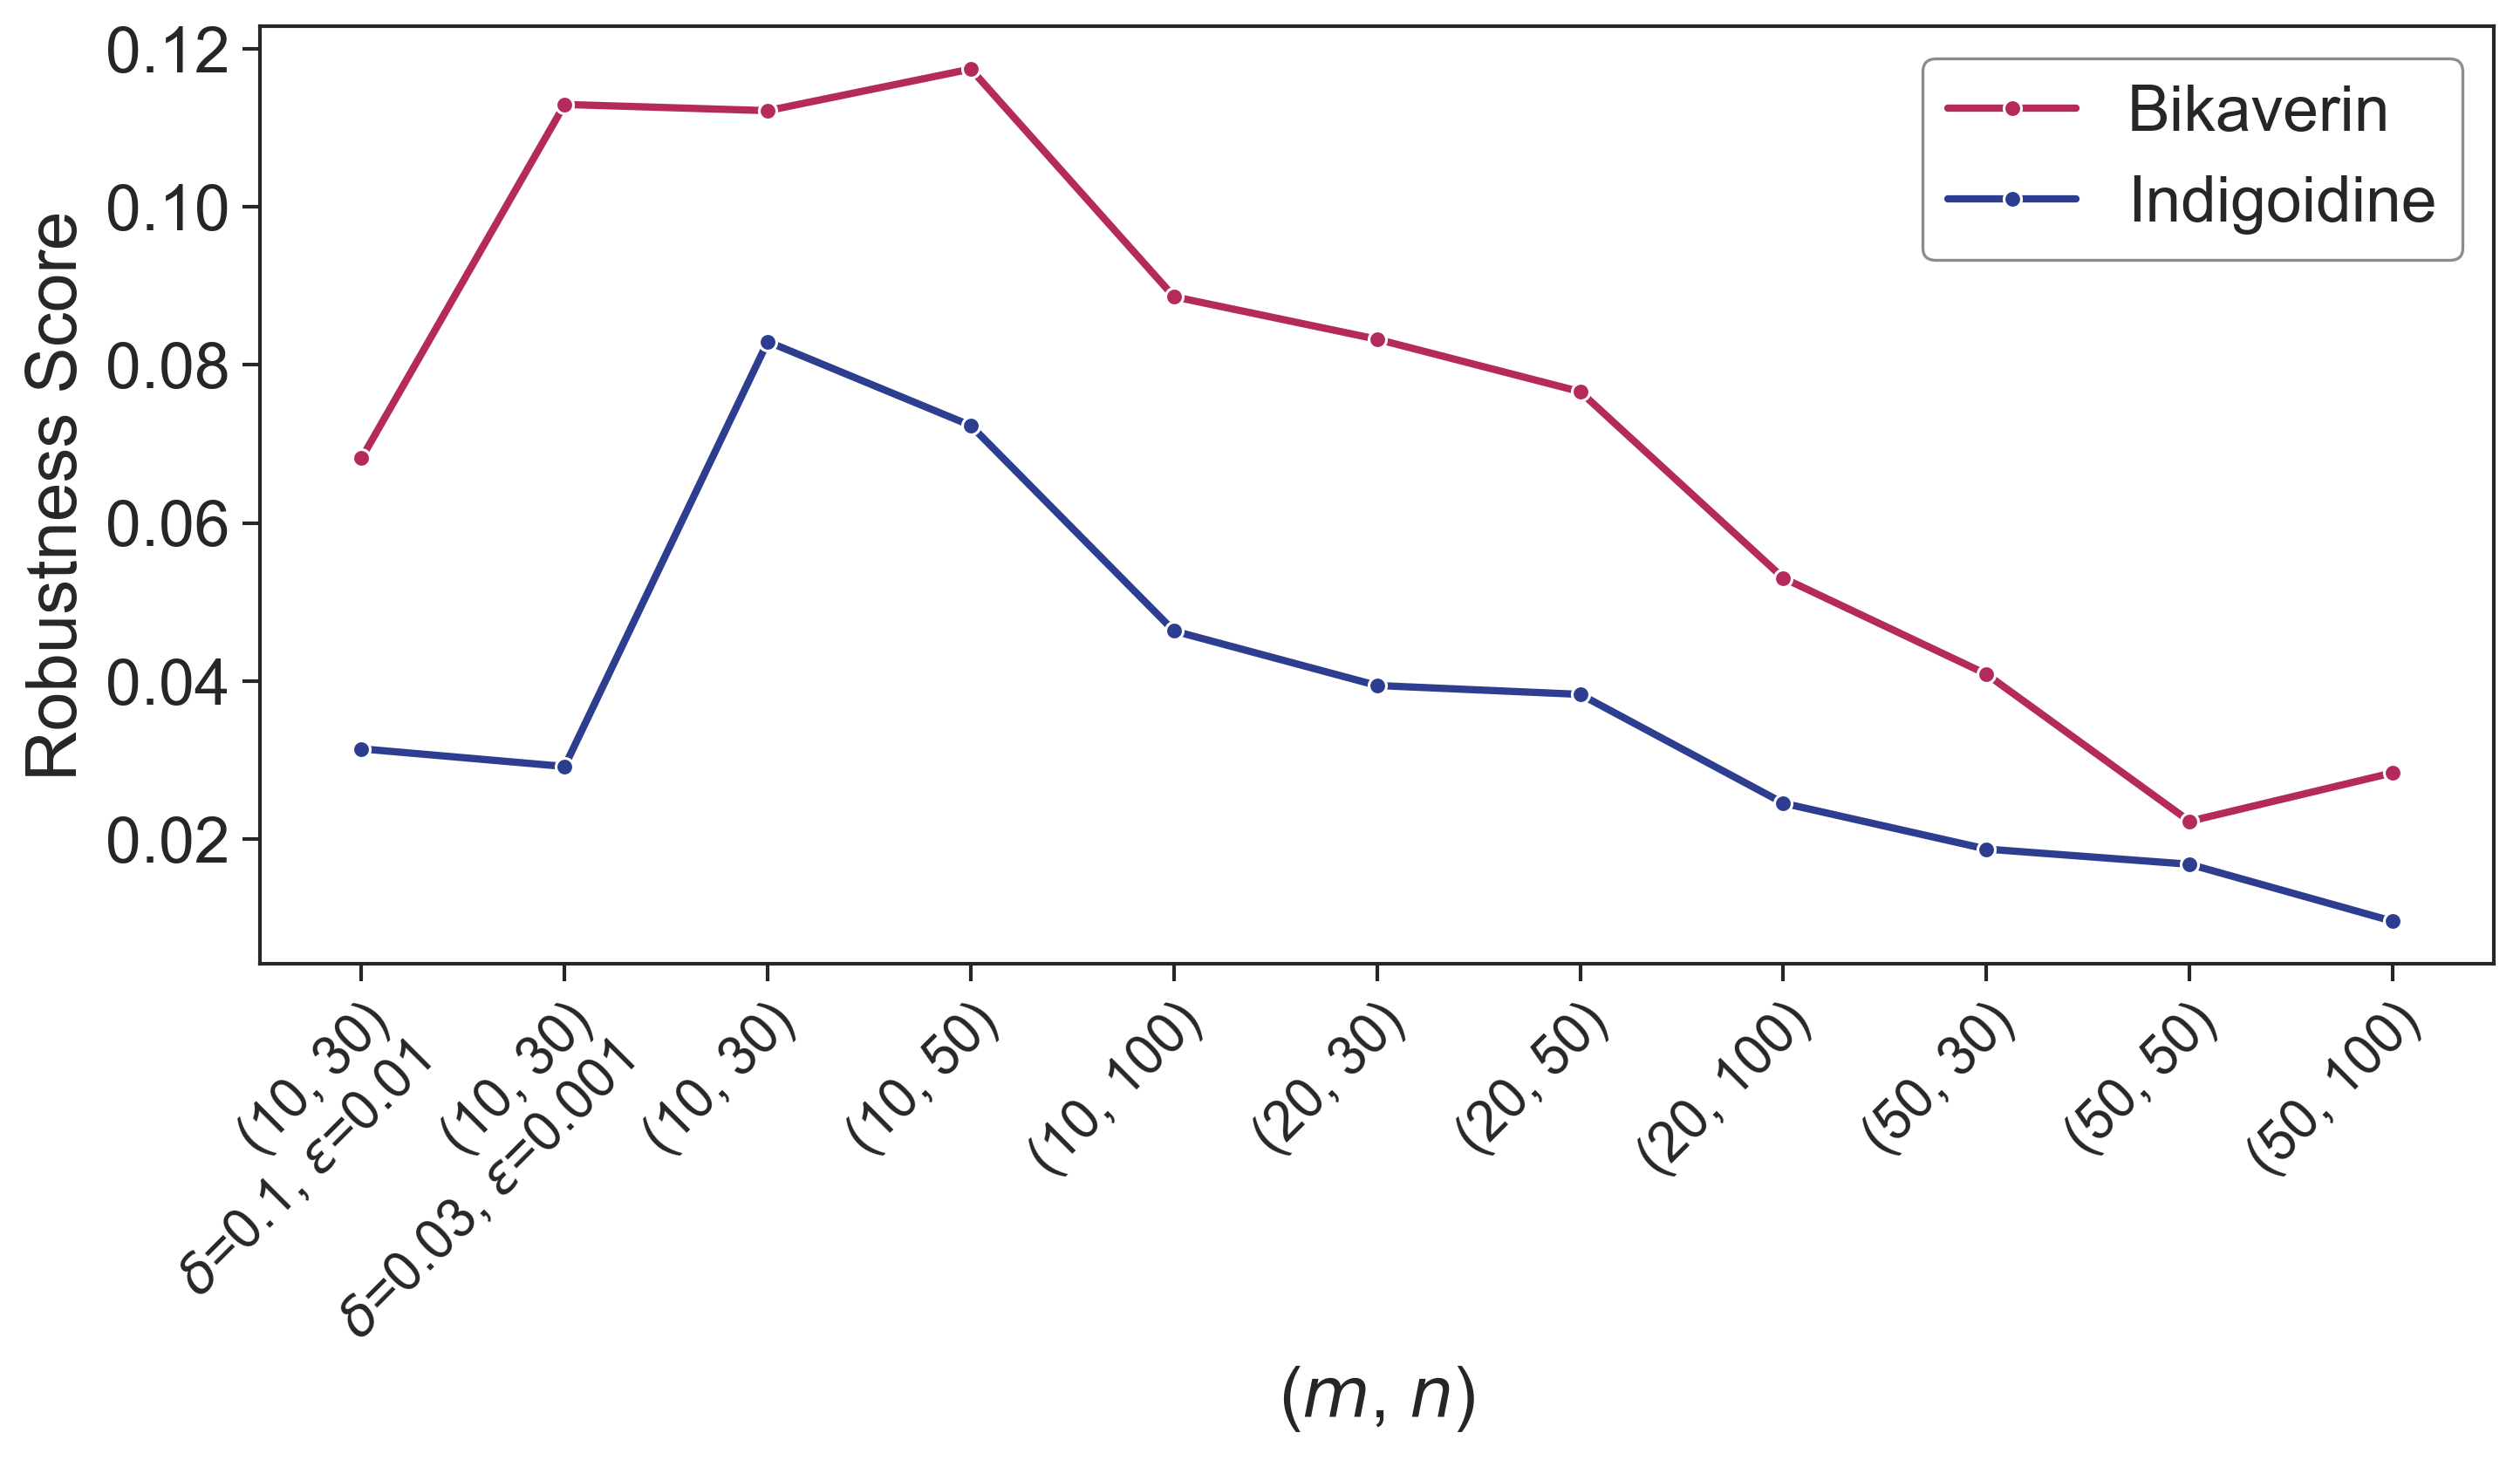

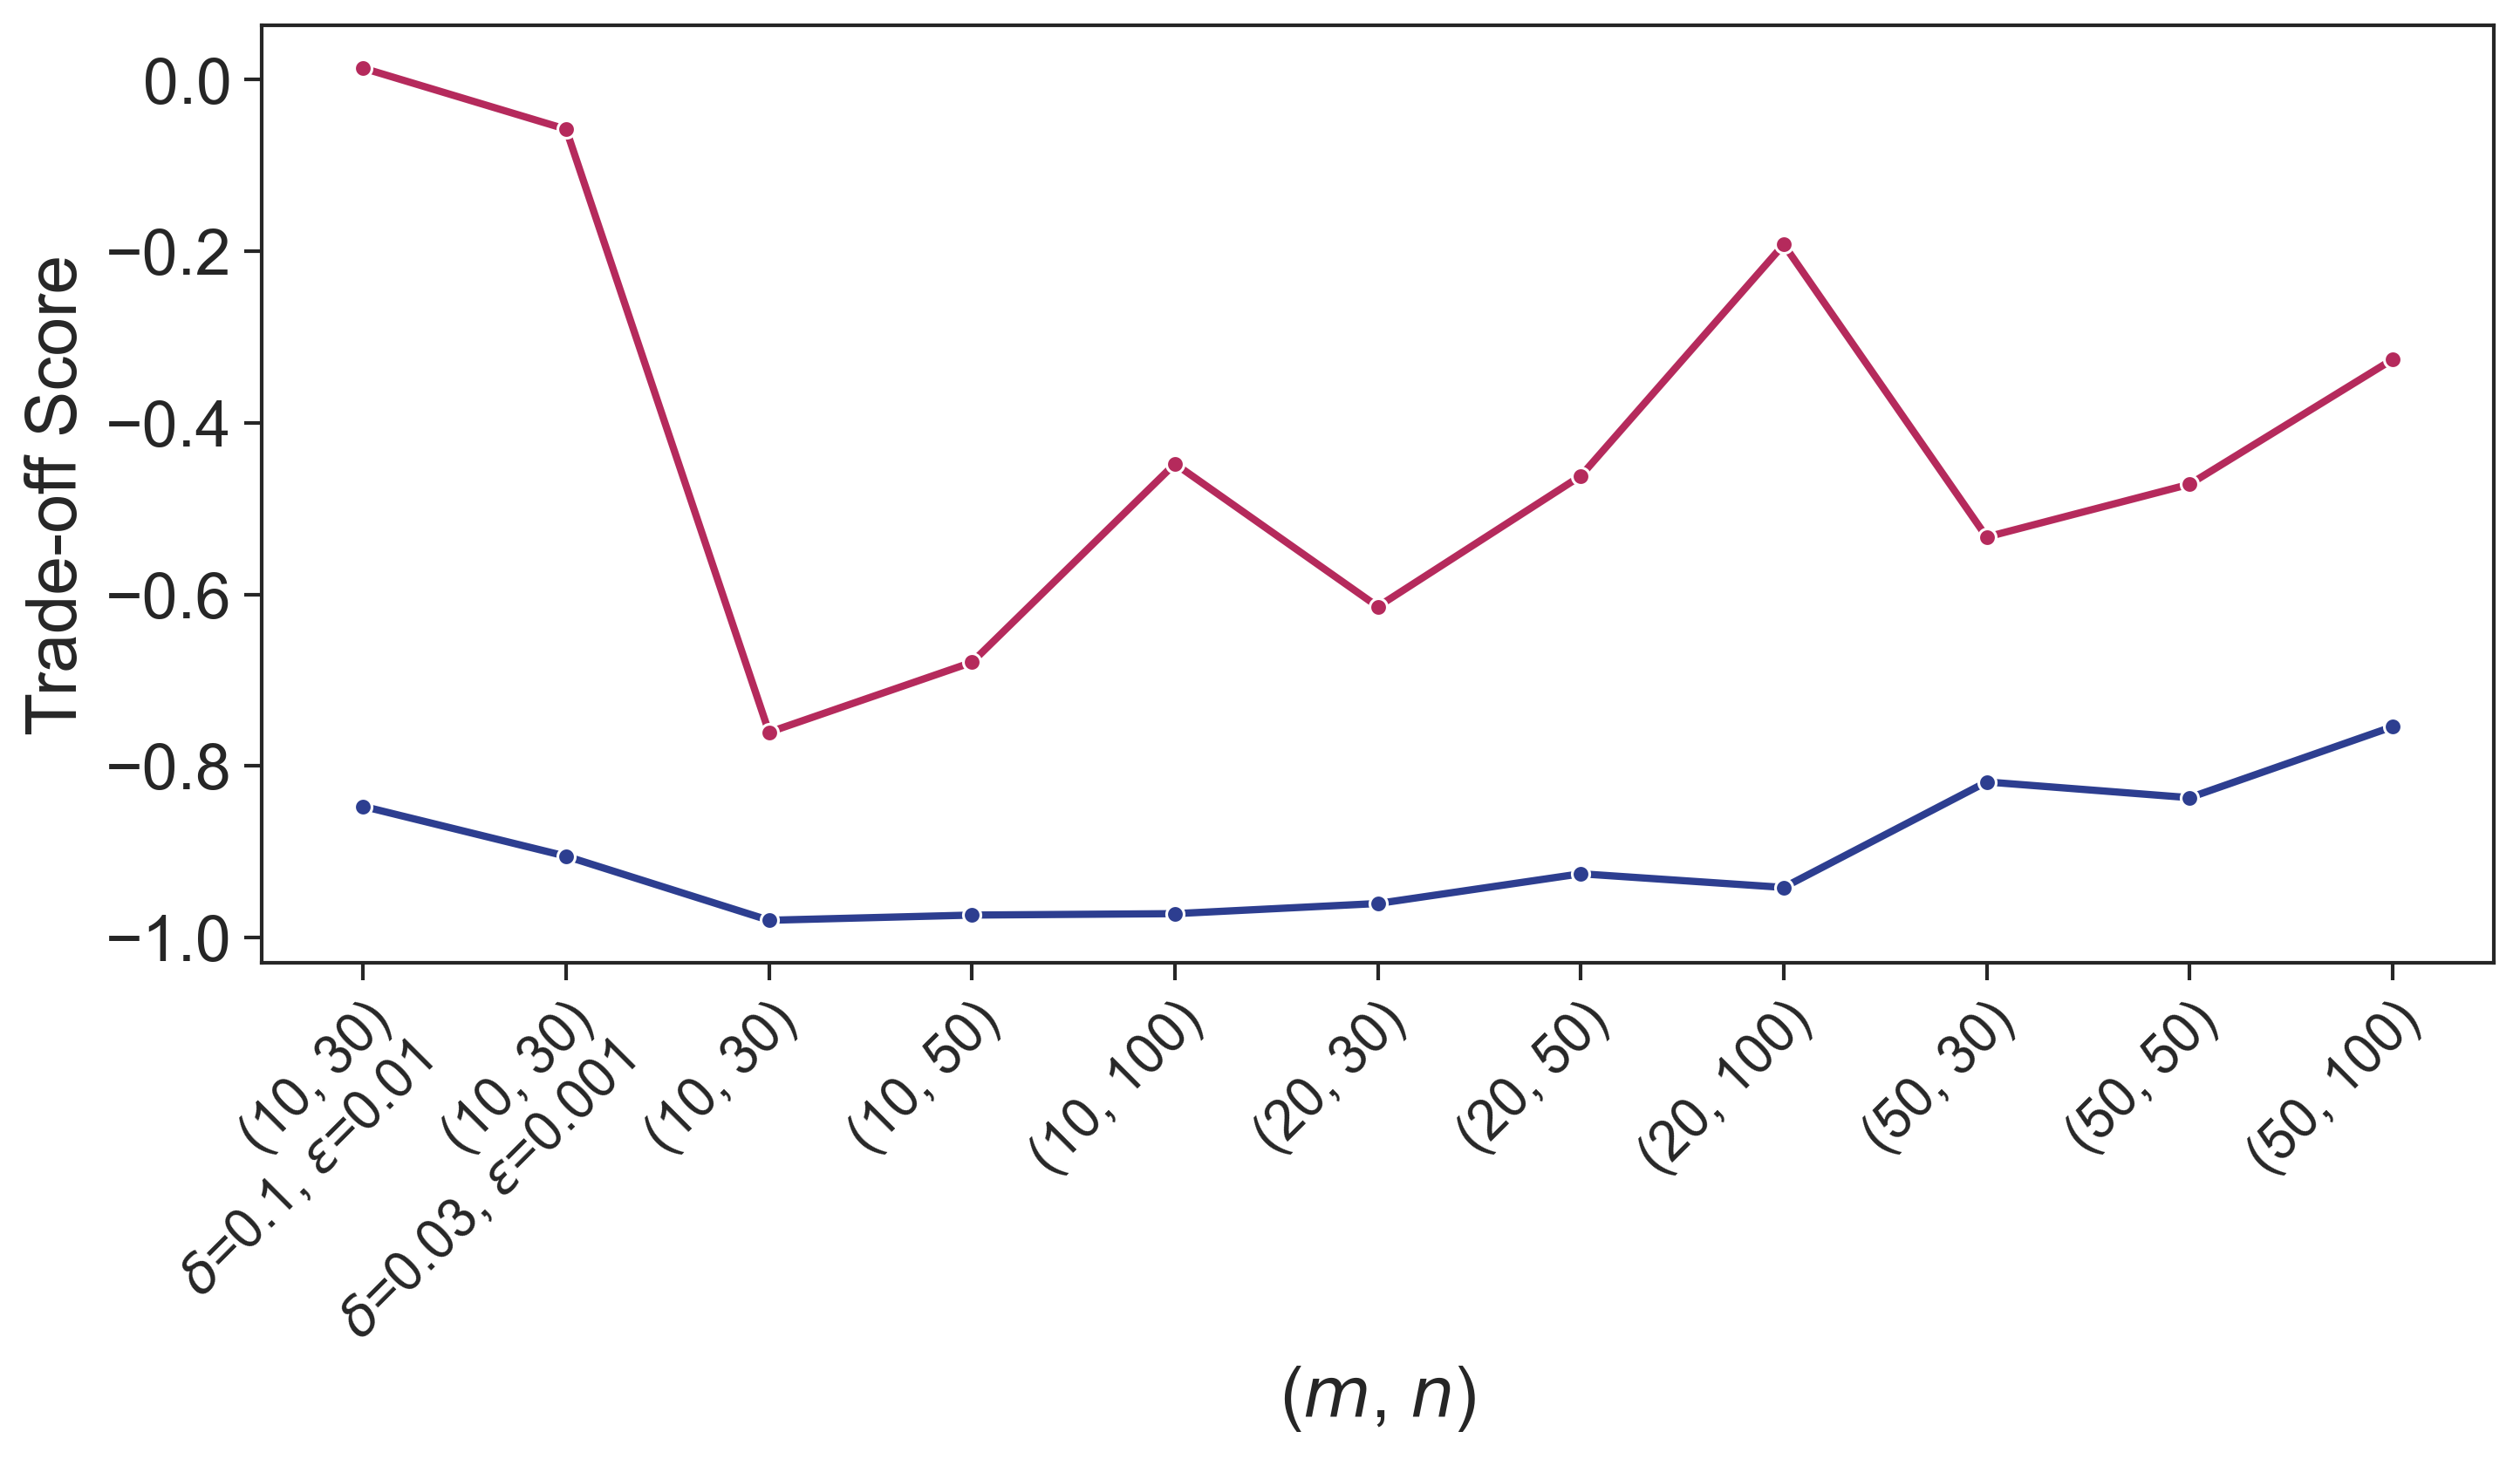

In [10]:
show_sensitivity_results(
    prepare_pigment_sensitivity_summary('YP'),
    PIGMENT_SENSITIVITY_DIR,
    'yp_pigment',
    [name.lower() for name in pigment_names],
    dict(zip([name.lower() for name in pigment_names], pigment_colors)),
    legend_labels=pigment_names,
);


# 2 Aromatic

In [11]:
AROMATIC_SCORE_KWARGS = dict(
    env_df=env_df,
    n_mutations=50,
    k_min=K_MIN,
    same_desired_trait=True,
    colors=plt.get_cmap("tab20").colors,
)


## 2.1 Predictive results

In [12]:
pea_res_df_all, pea_ra_dfs_all = show_score_results(
    input_dir=str(AROMATIC_RESULTS_DIR / 'PEA_ana'),
    **AROMATIC_SCORE_KWARGS,
)
pea_res_df = pea_res_df_all[pea_res_df_all['accepted_count'] > 0].copy()
pea_ra_dfs = [(env_id, ra_df) for env_id, ra_df in pea_ra_dfs_all if env_id in pea_res_df.index]
print(
    f"{len(pea_res_df)}/{len(pea_res_df_all)} strains can produce PEA against perturbations in appl env."
)


322/1171 strains can produce PEA against perturbations in appl env.


['EtOH,Gal,Phe (Env_0160) (RS = $6.21\\times 10^{-2}$, TS = $-2.87\\times 10^{-1}$)', 'EtOH,Glc,Phe (Env_0325) (RS = $5.43\\times 10^{-2}$, TS = $-1.09\\times 10^{-1}$)', 'Gal,Arg,NH$_4$ (Env_0863) (RS = $3.89\\times 10^{-2}$, TS = $5.76\\times 10^{-2}$)', 'Gal,Asn,Glu (Env_0048) (RS = $4.69\\times 10^{-2}$, TS = $1.35\\times 10^{-1}$)', 'Gal,Glu,Trp (Env_0083) (RS = $4.41\\times 10^{-2}$, TS = $3.14\\times 10^{-1}$)', 'Gal,Gol,Ser (Env_0176) (RS = $3.28\\times 10^{-2}$, TS = $-1.42\\times 10^{-2}$)', 'Glc,Ala,Lys (Env_0189) (RS = $5.28\\times 10^{-2}$, TS = $3.24\\times 10^{-1}$)', 'Glc,Ile,Thr (Env_0277) (RS = $3.60\\times 10^{-2}$, TS = $1.56\\times 10^{-1}$)', 'Gol,Lys,Phe (Env_1147) (RS = $5.62\\times 10^{-2}$, TS = $-5.75\\times 10^{-1}$)', 'Gol,Met,Phe (Env_1152) (RS = $5.90\\times 10^{-2}$, TS = $-3.12\\times 10^{-1}$)']


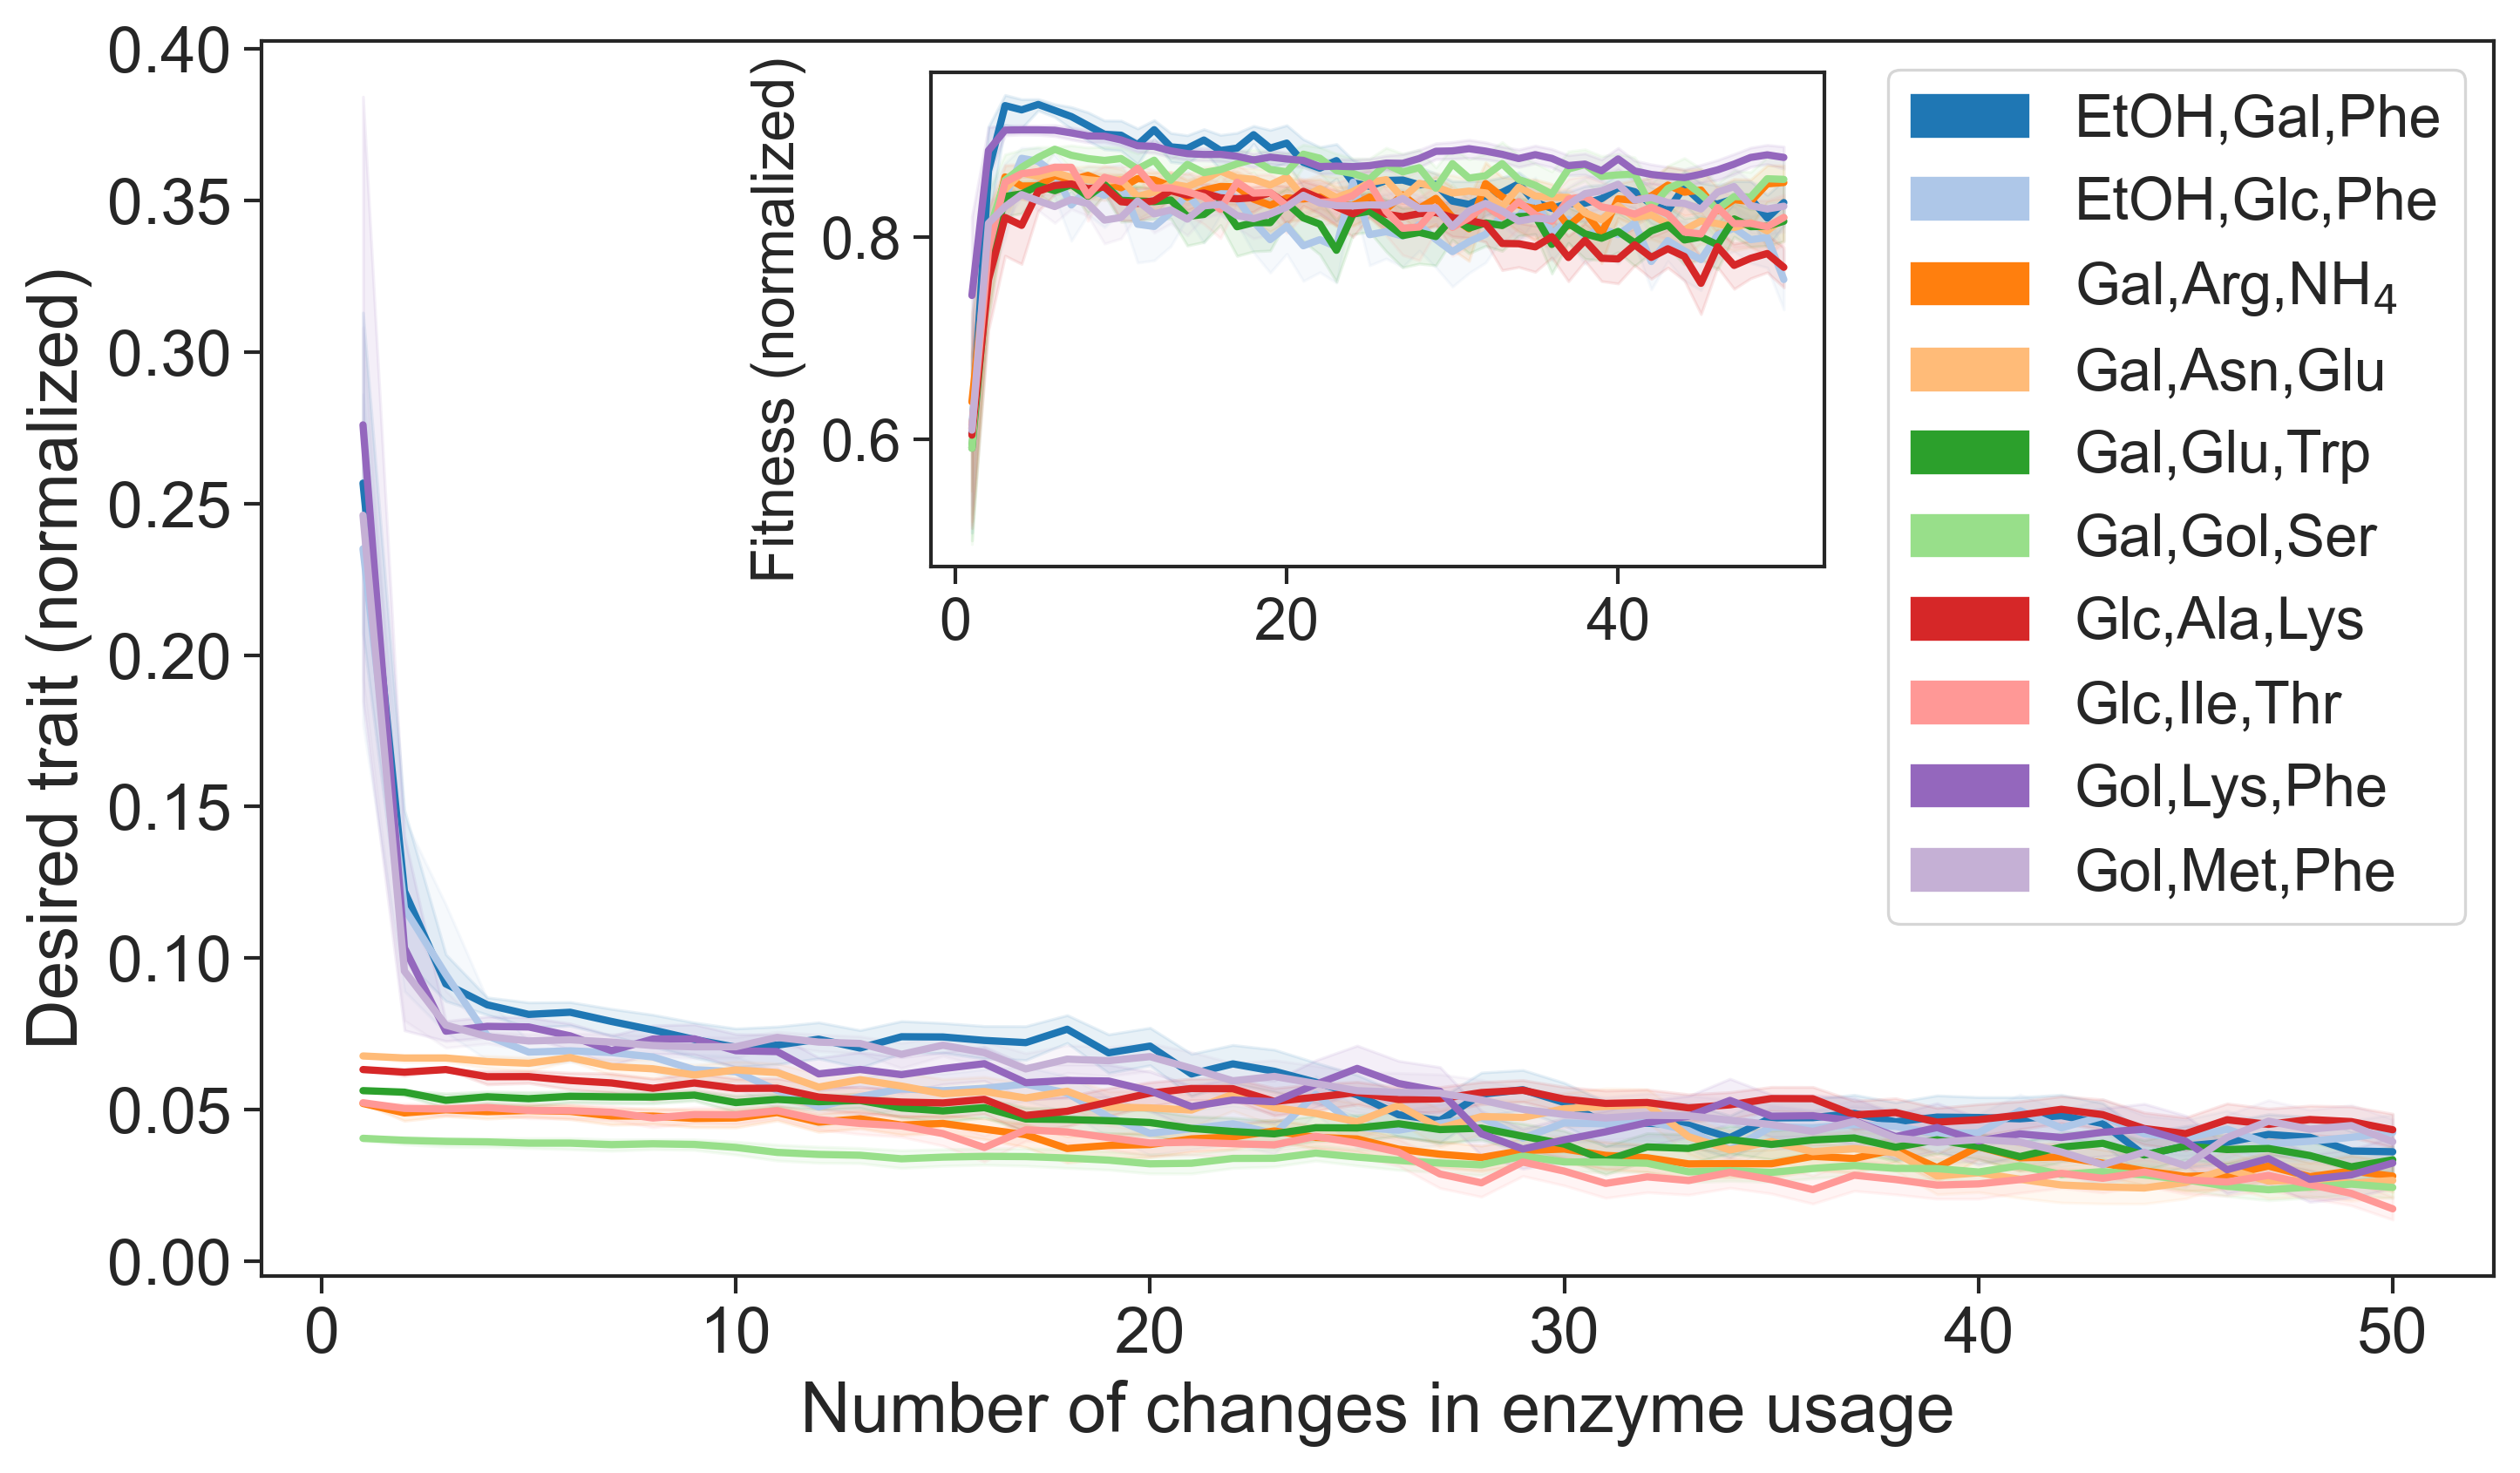

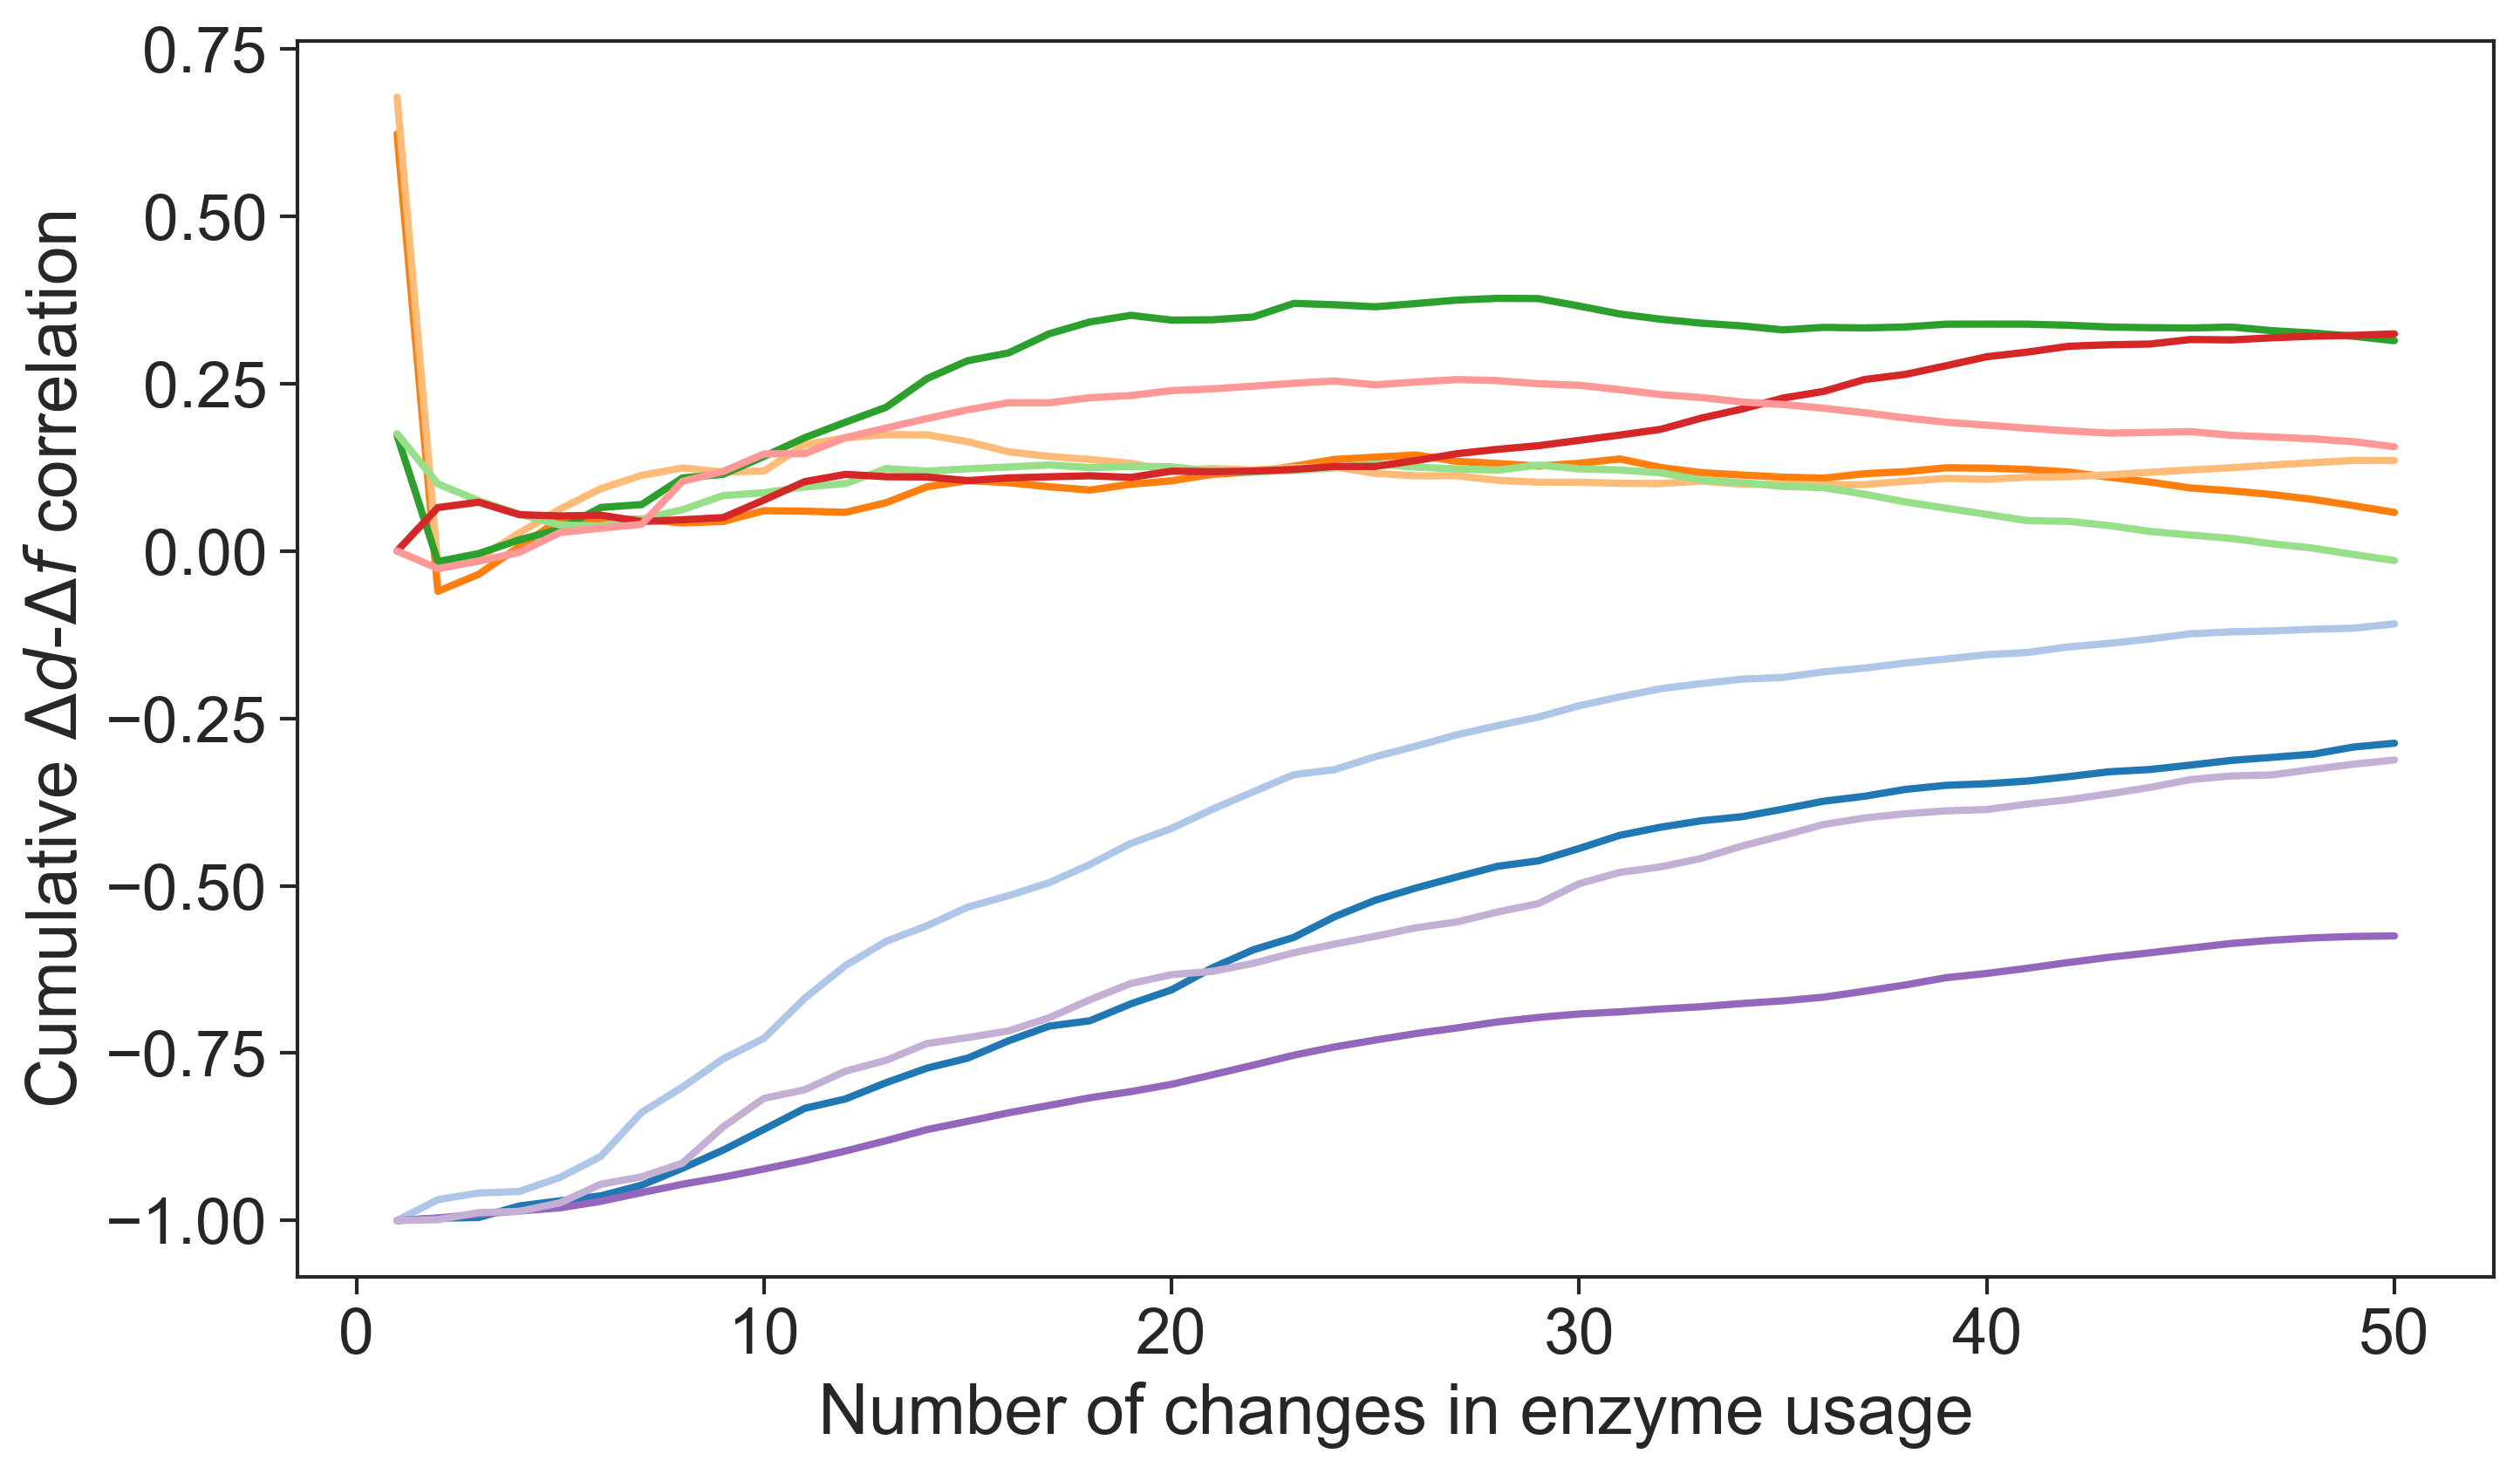

In [13]:
pea_list = enumerate_env_list(pea_res_df, pea_ra_dfs, random_state=10)
show_score_results(
    input_dir=str(AROMATIC_RESULTS_DIR / 'PEA_ana'),
    res_df=pea_res_df,
    ra_dfs=pea_ra_dfs,
    env_list=pea_list,
    **AROMATIC_SCORE_KWARGS,
);


In [14]:
bcha_res_df_all, bcha_ra_dfs_all = show_score_results(
    input_dir=str(AROMATIC_RESULTS_DIR / 'BCHA_ana'),
    **AROMATIC_SCORE_KWARGS,
)
bcha_res_df = bcha_res_df_all[bcha_res_df_all['accepted_count'] > 0].copy()
bcha_ra_dfs = [(env_id, ra_df) for env_id, ra_df in bcha_ra_dfs_all if env_id in bcha_res_df.index]
print(
    f"{len(bcha_res_df)}/{len(bcha_res_df_all)} strains can produce BCHA against perturbations in appl env."
)


499/1171 strains can produce BCHA against perturbations in appl env.


['Ala,Arg,Ser (Env_0351) (RS = $8.35\\times 10^{-2}$, TS = $-7.74\\times 10^{-2}$)', 'EtOH,Arg,Glu (Env_0956) (RS = $9.85\\times 10^{-2}$, TS = $1.62\\times 10^{-2}$)', 'Gal,Ile,Met (Env_0109) (RS = $1.23\\times 10^{-1}$, TS = $-4.75\\times 10^{-1}$)', 'Gal,Ile,NH$_4$ (Env_0869) (RS = $1.12\\times 10^{-1}$, TS = $-3.34\\times 10^{-1}$)', 'Glc,Gol,NH$_4$ (Env_0899) (RS = $7.50\\times 10^{-2}$, TS = $-1.63\\times 10^{-1}$)', 'Glc,Leu,NH$_4$ (Env_0889) (RS = $1.33\\times 10^{-1}$, TS = $-2.64\\times 10^{-1}$)', 'Glc,Leu,Val (Env_0288) (RS = $1.45\\times 10^{-1}$, TS = $-2.83\\times 10^{-1}$)', 'Glc,NH$_4$,Ser (Env_0893) (RS = $8.71\\times 10^{-2}$, TS = $1.79\\times 10^{-2}$)', 'Gol,Gly,Lys (Env_1122) (RS = $1.05\\times 10^{-1}$, TS = $7.38\\times 10^{-2}$)', 'Gol,Ile,Lys (Env_1131) (RS = $1.31\\times 10^{-1}$, TS = $-3.24\\times 10^{-1}$)']


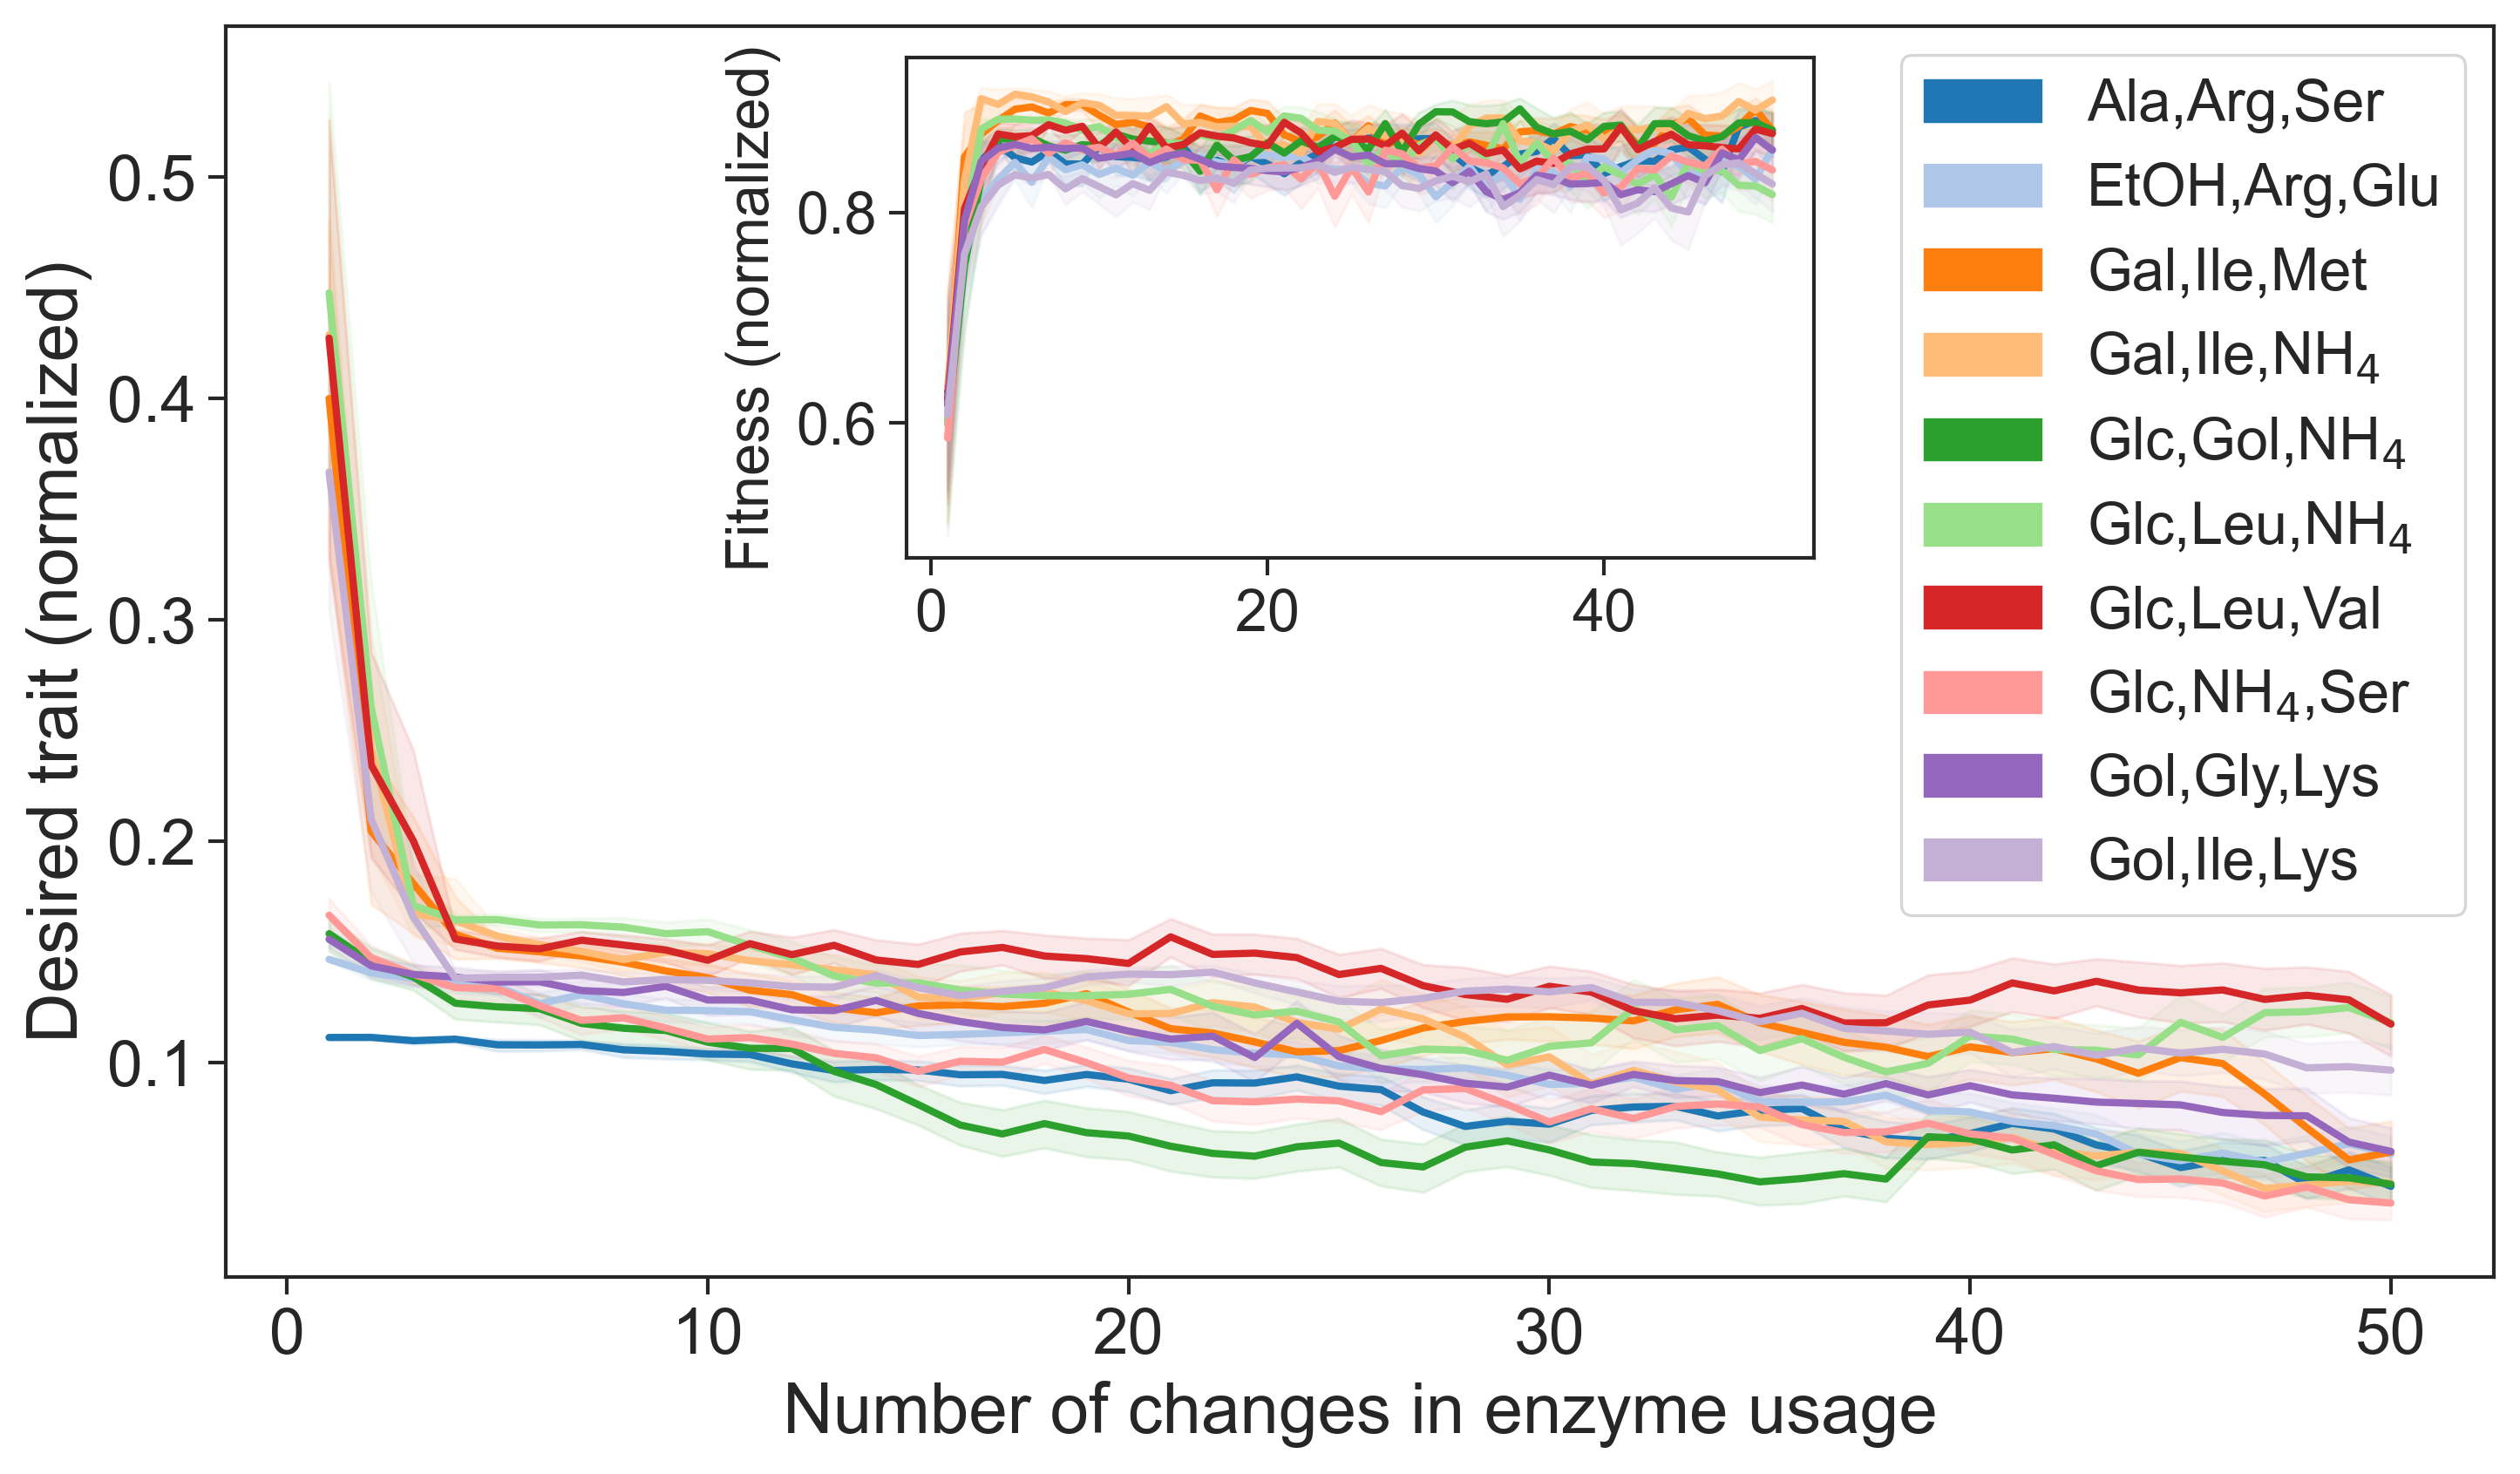

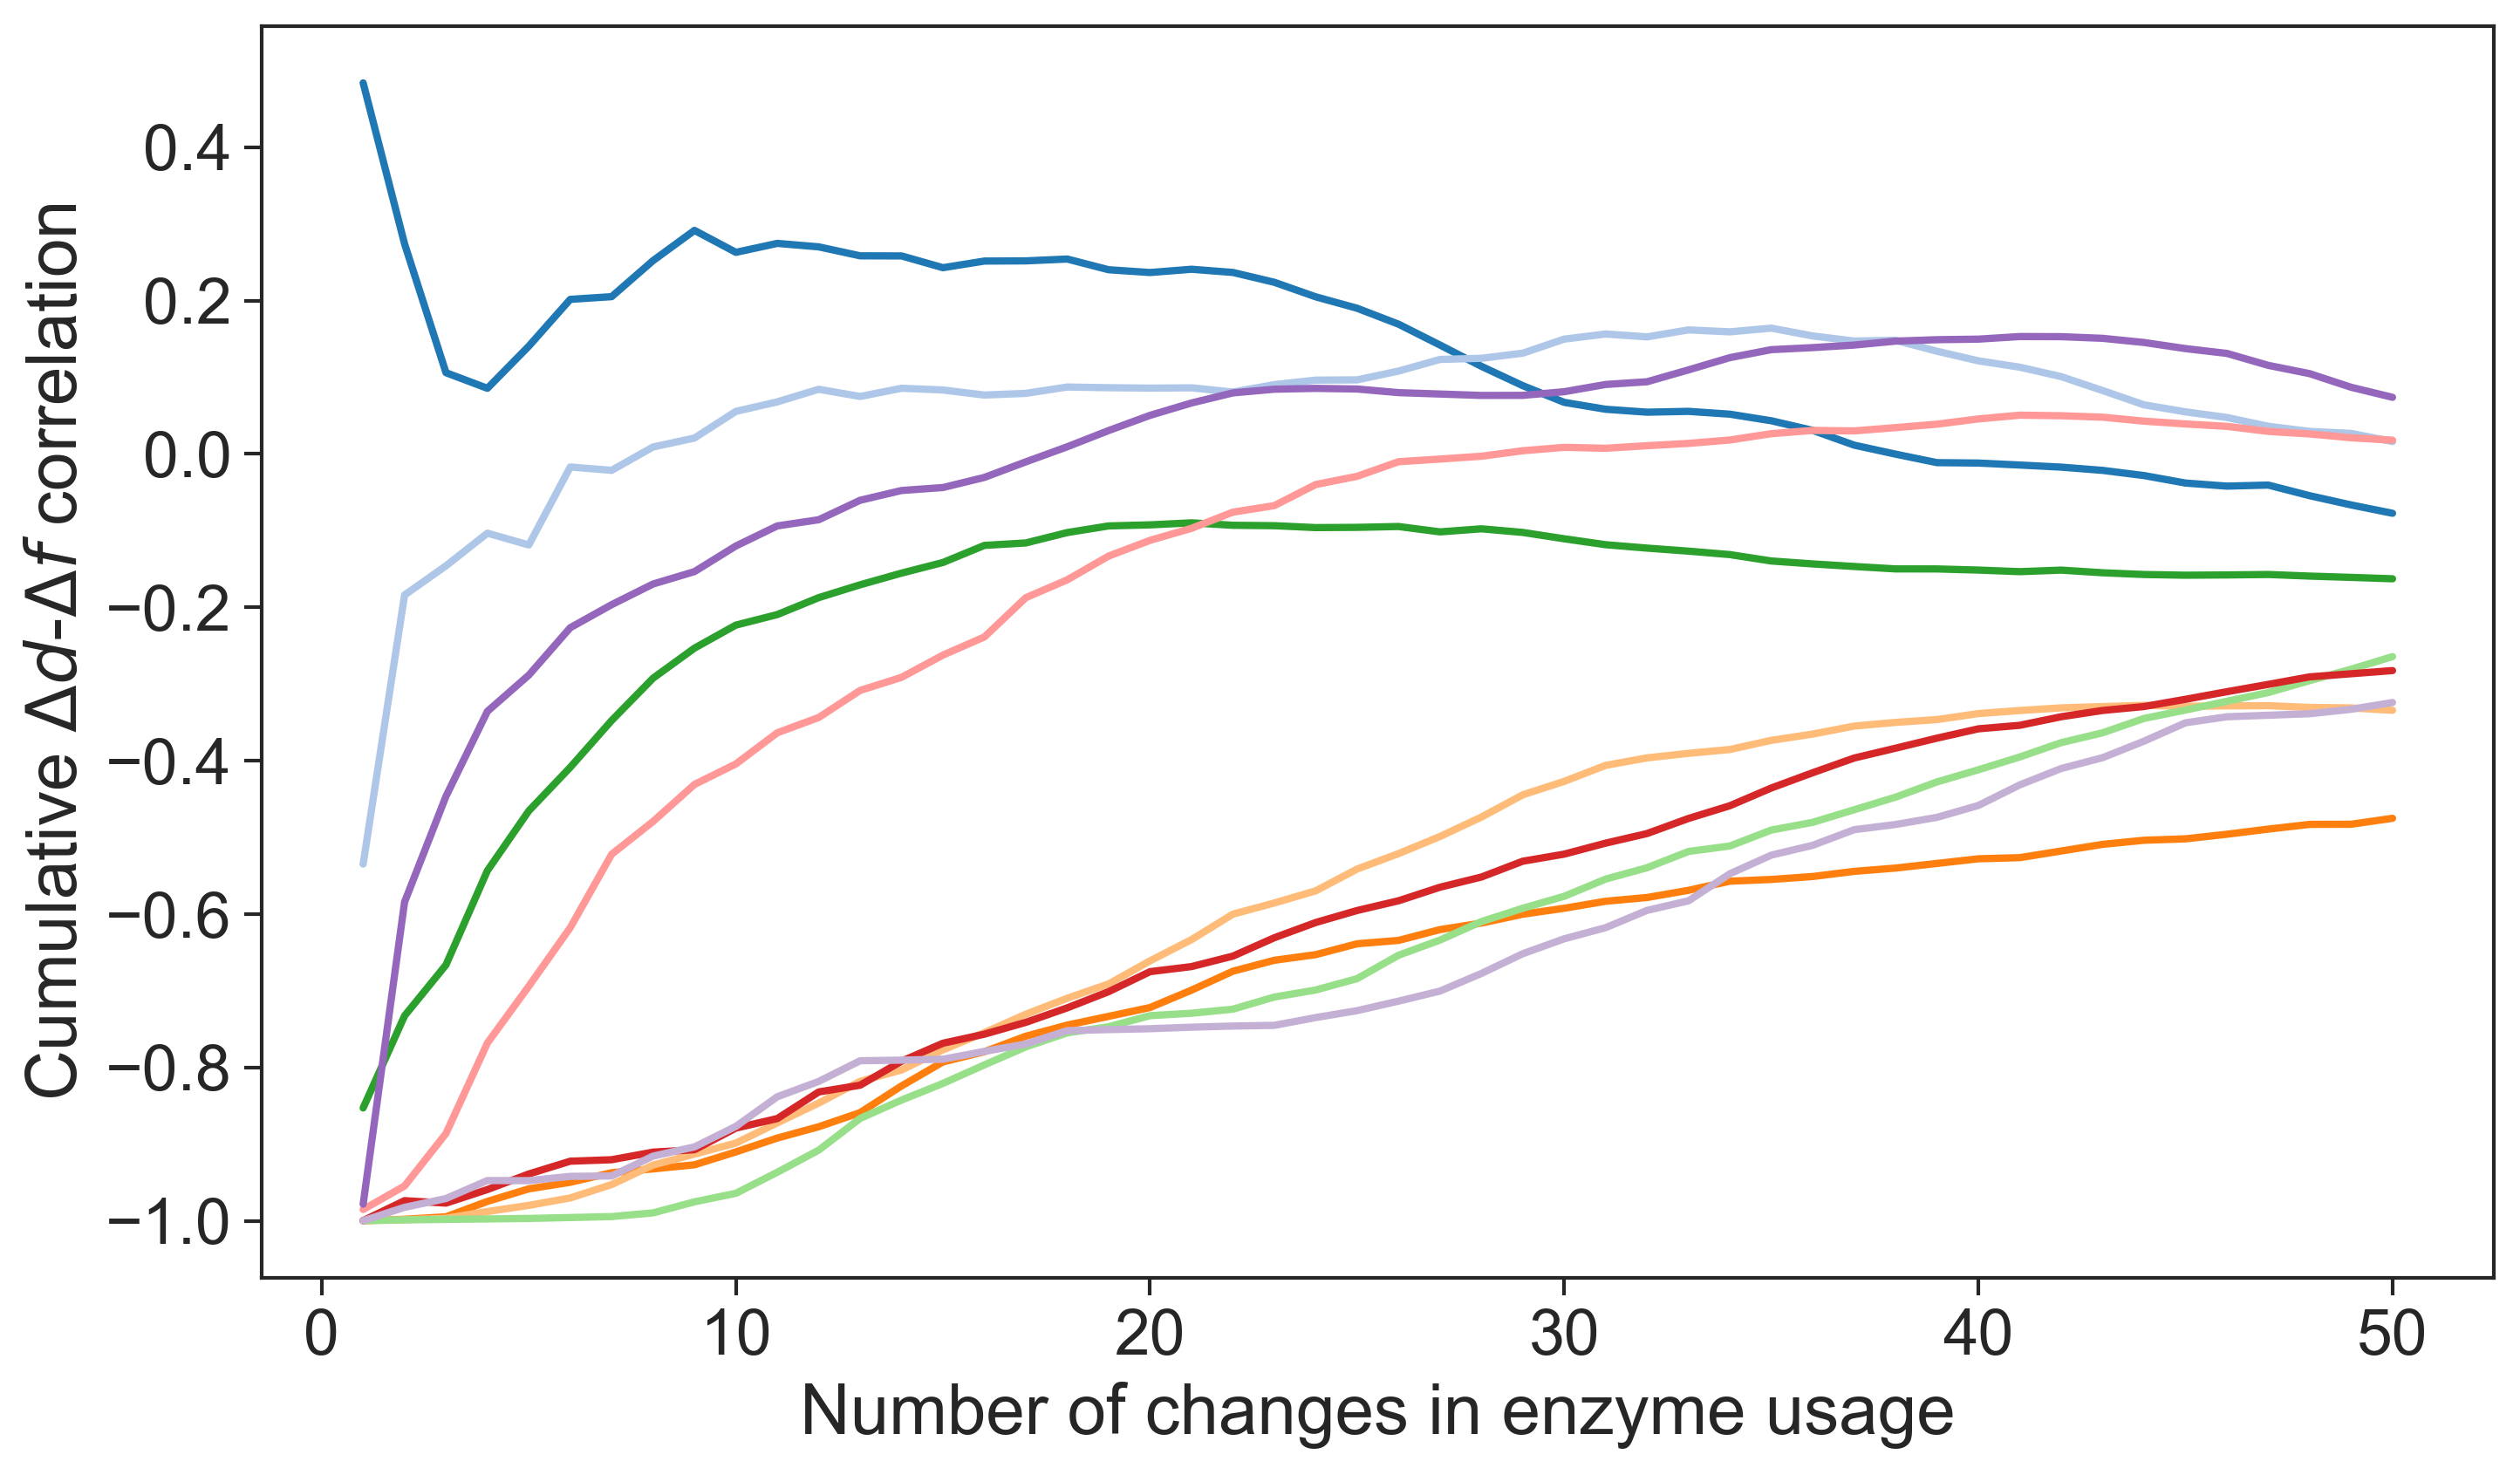

In [15]:
bcha_list = enumerate_env_list(bcha_res_df, bcha_ra_dfs, random_state=10)
show_score_results(
    input_dir=str(AROMATIC_RESULTS_DIR / 'BCHA_ana'),
    res_df=bcha_res_df,
    ra_dfs=bcha_ra_dfs,
    env_list=bcha_list,
    **AROMATIC_SCORE_KWARGS,
);


## 2.3 RS/TS clustering and nutrient enrichment analysis


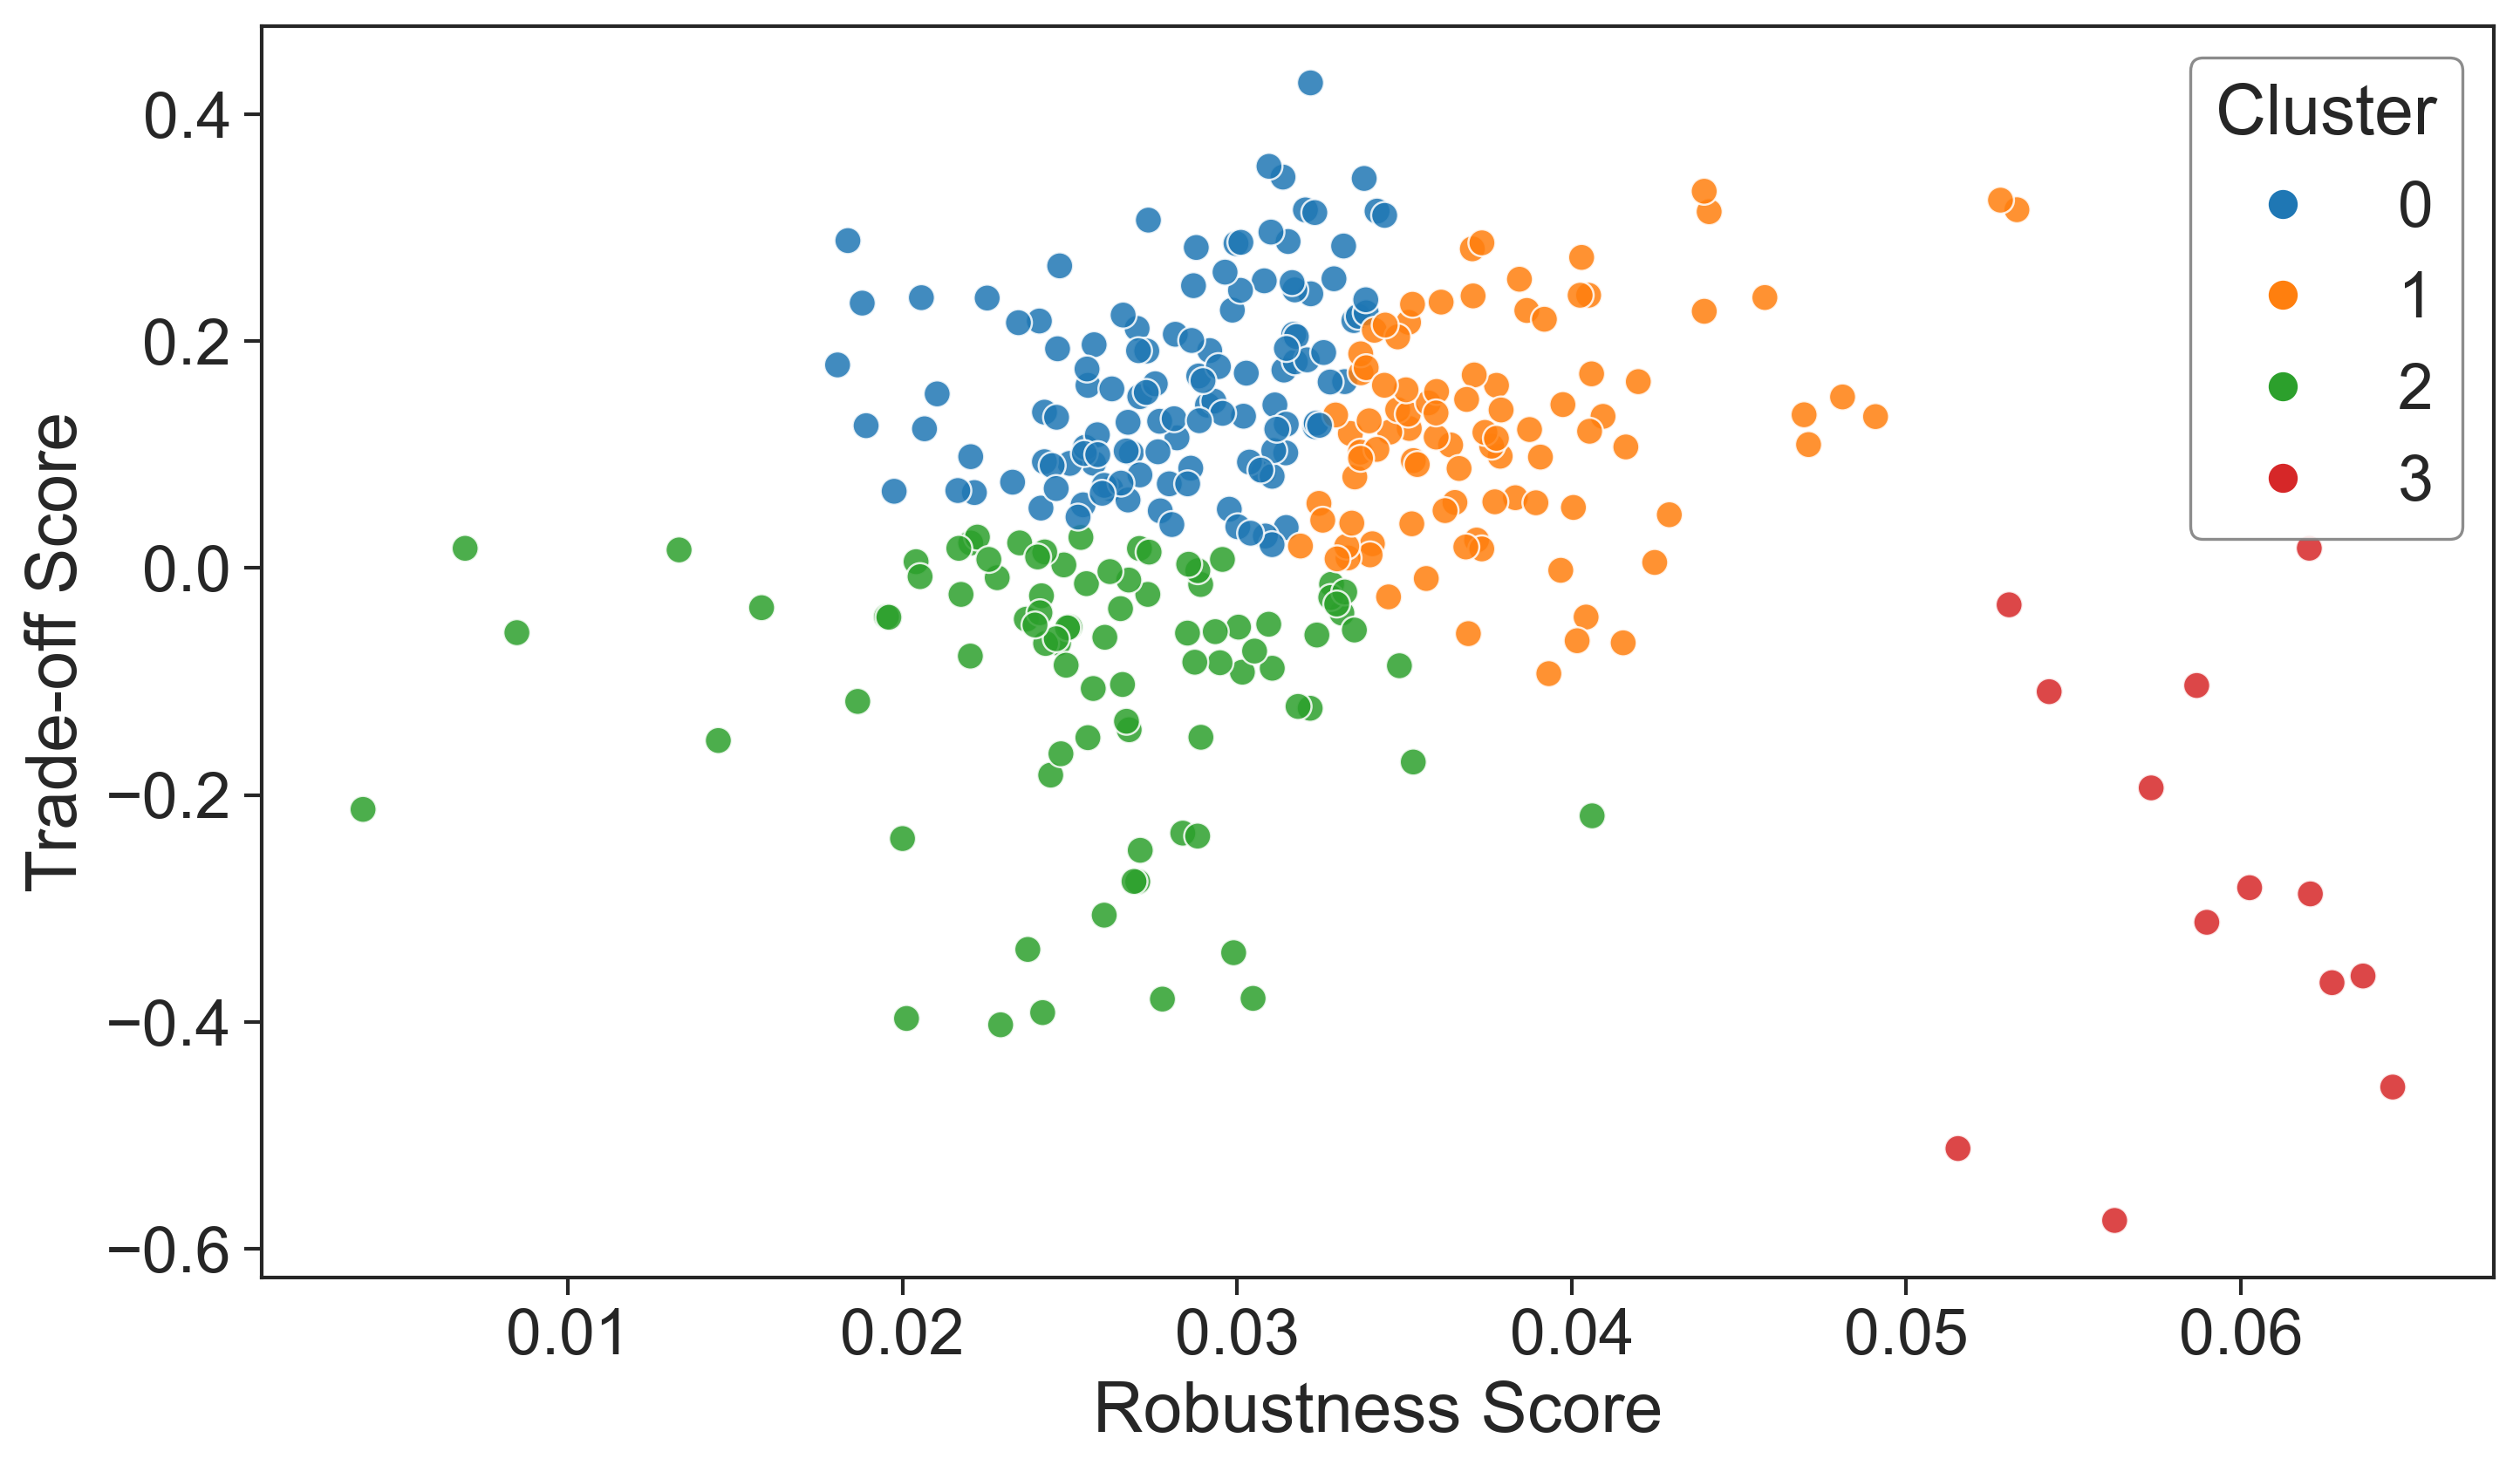

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


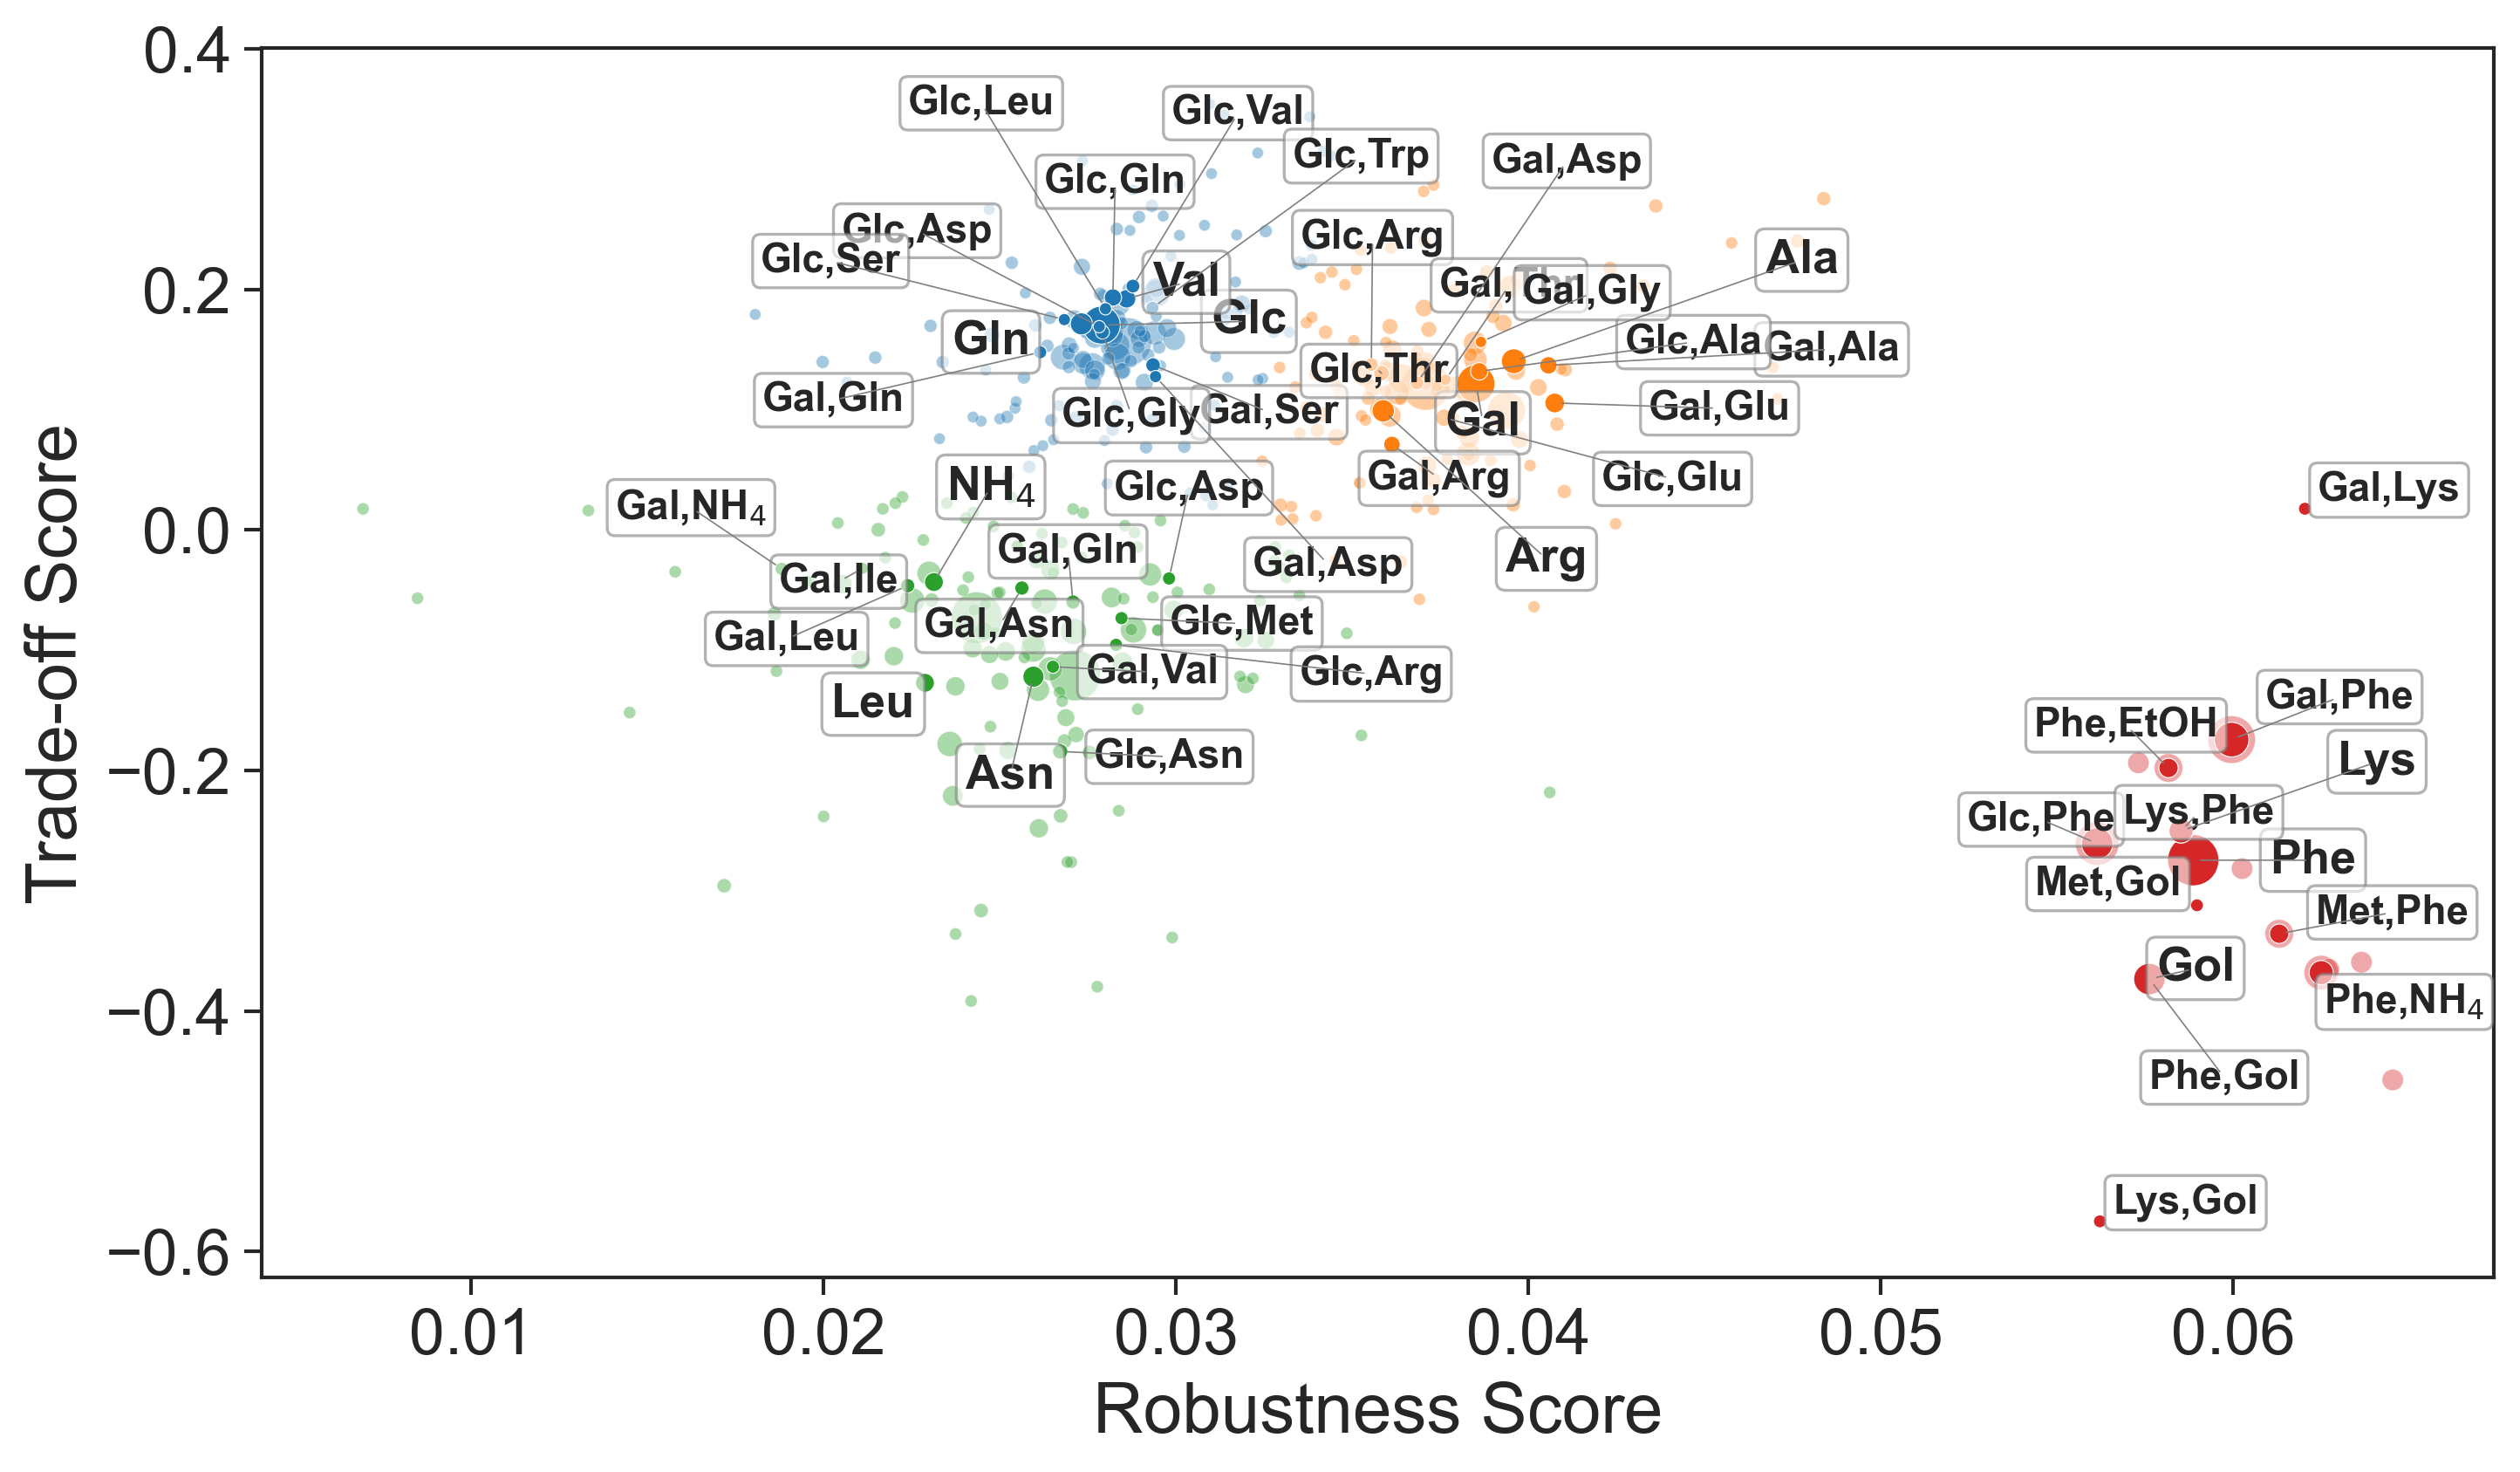

In [16]:
pea_cluster_result = summarize_favorable_rs_ts_clusters(
    pea_res_df,
    env_df,
    'PEA_ana',
    str(AROMATIC_RESULTS_DIR / 'pea_ana_rs_ts_clusters'),
    str(AROMATIC_RESULTS_DIR),
    n_clusters=4,
    random_state=0,
)


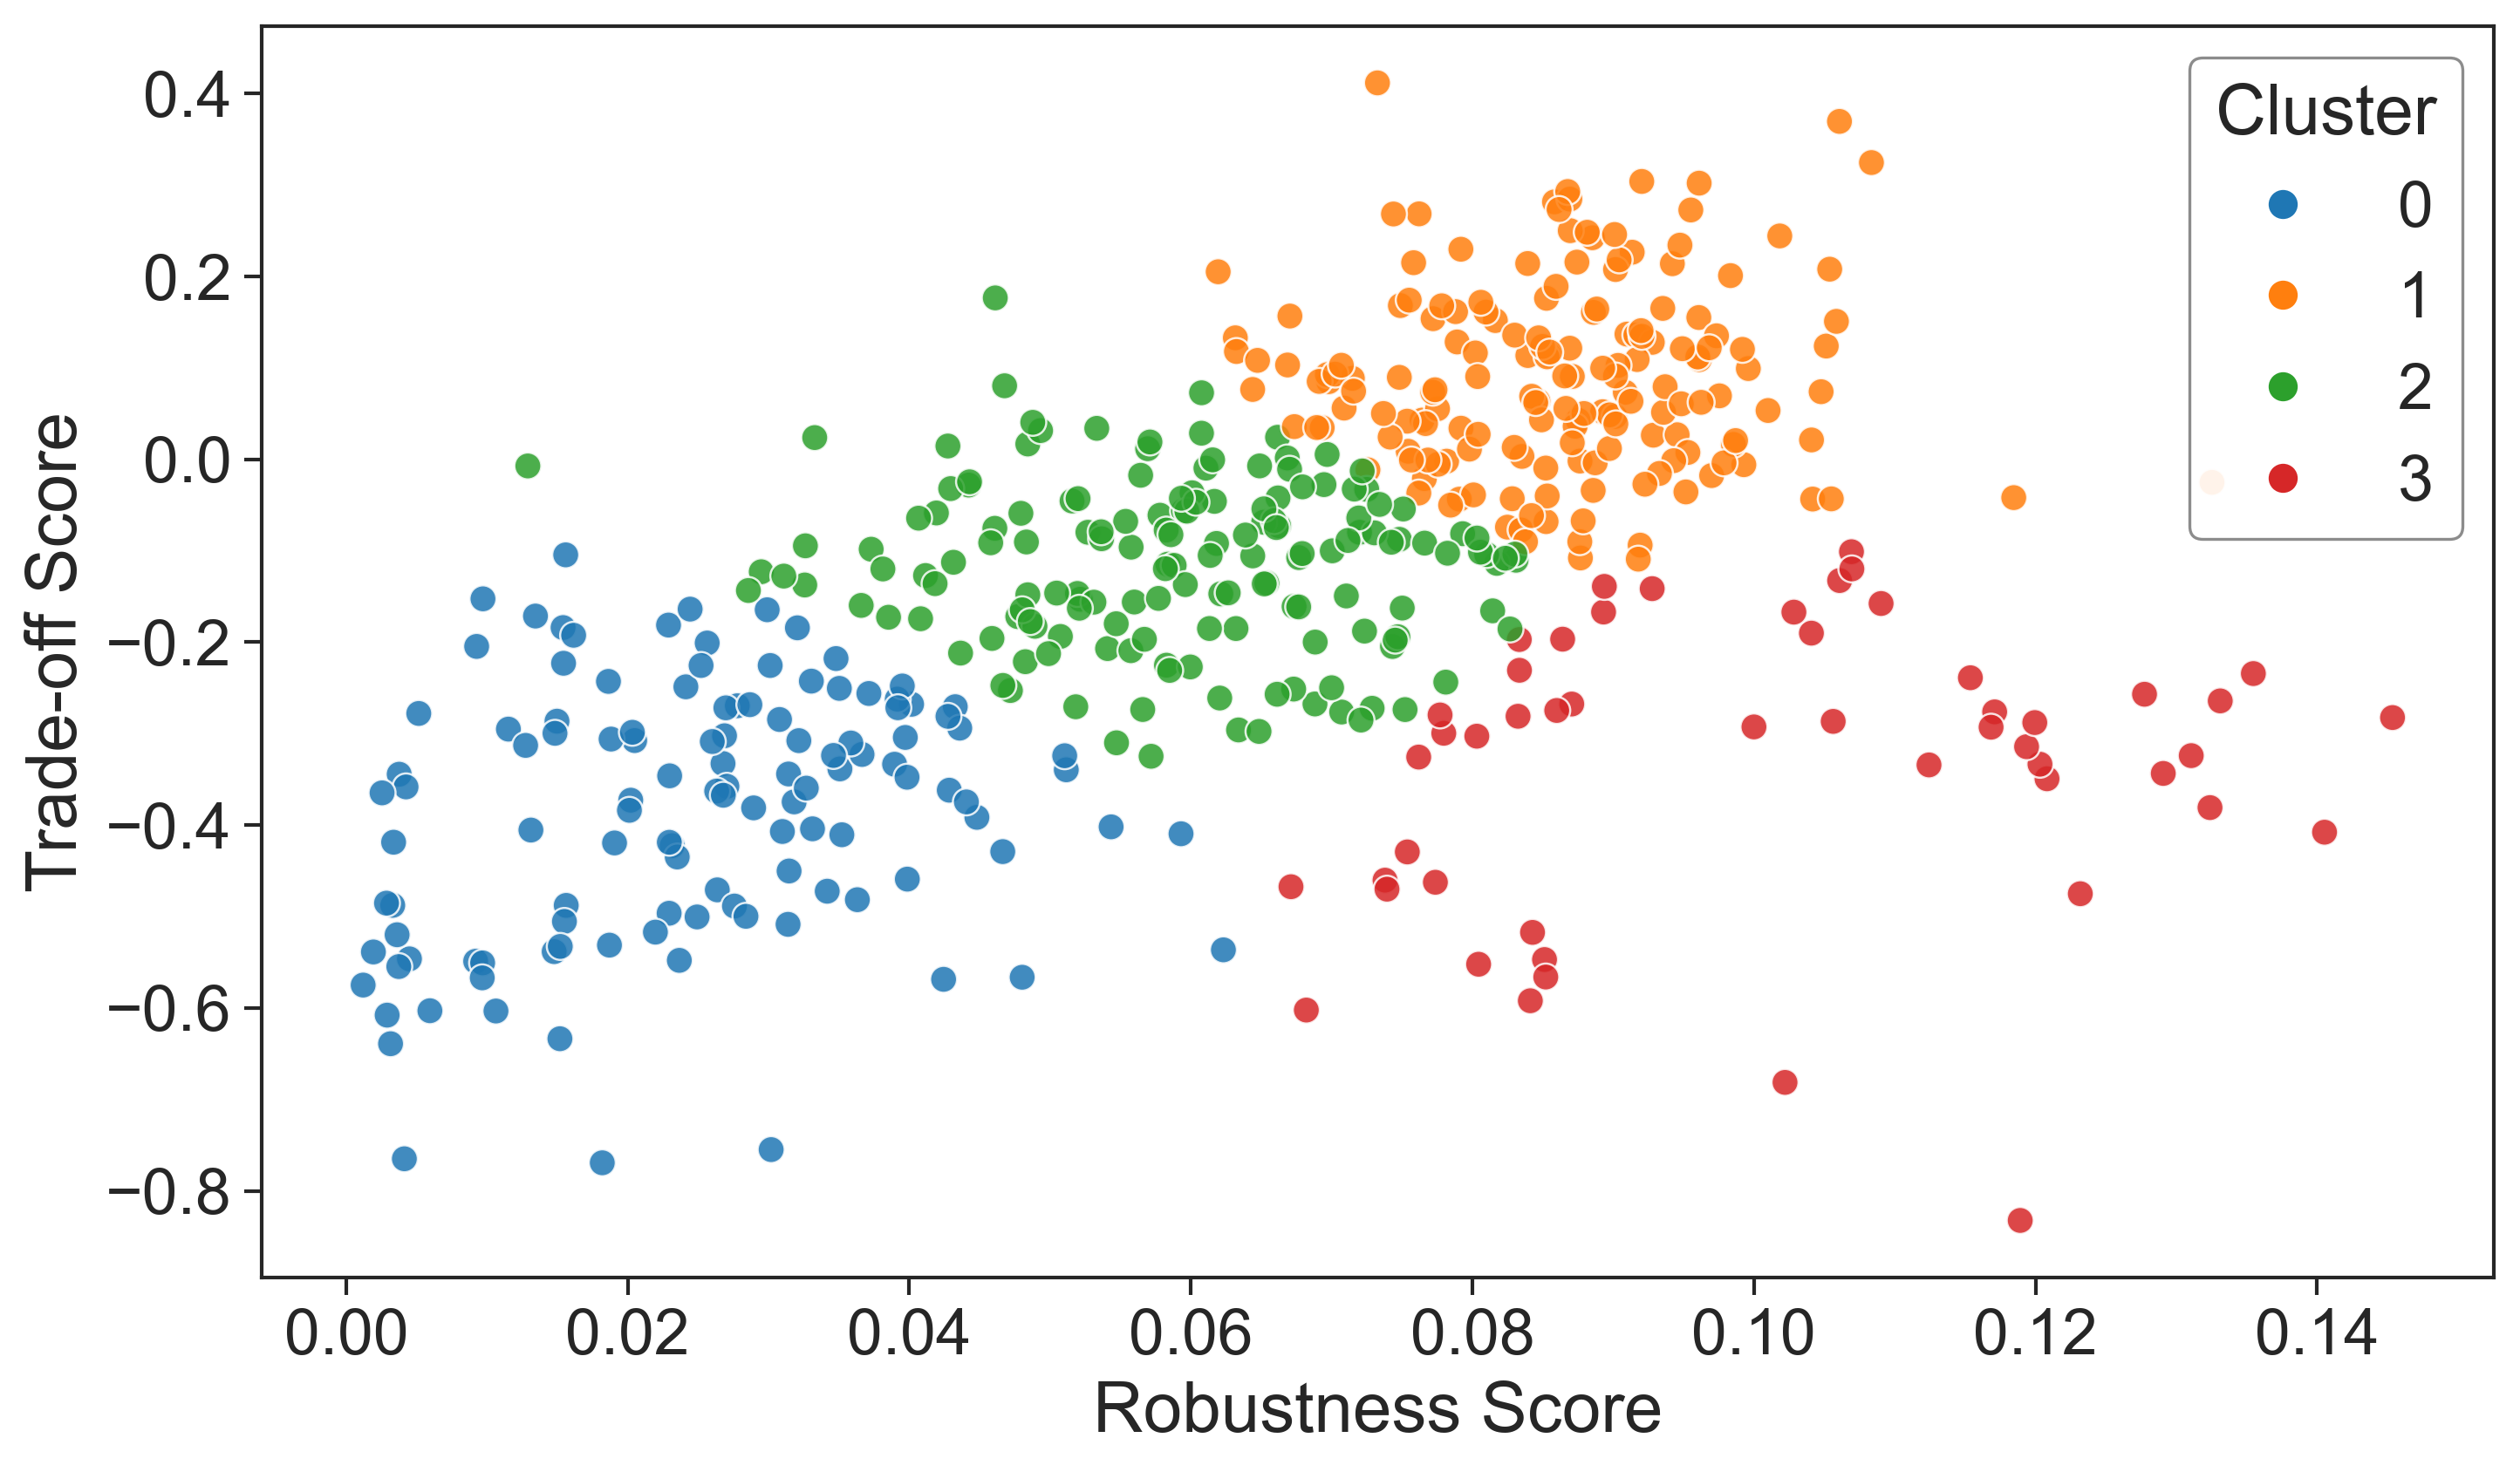

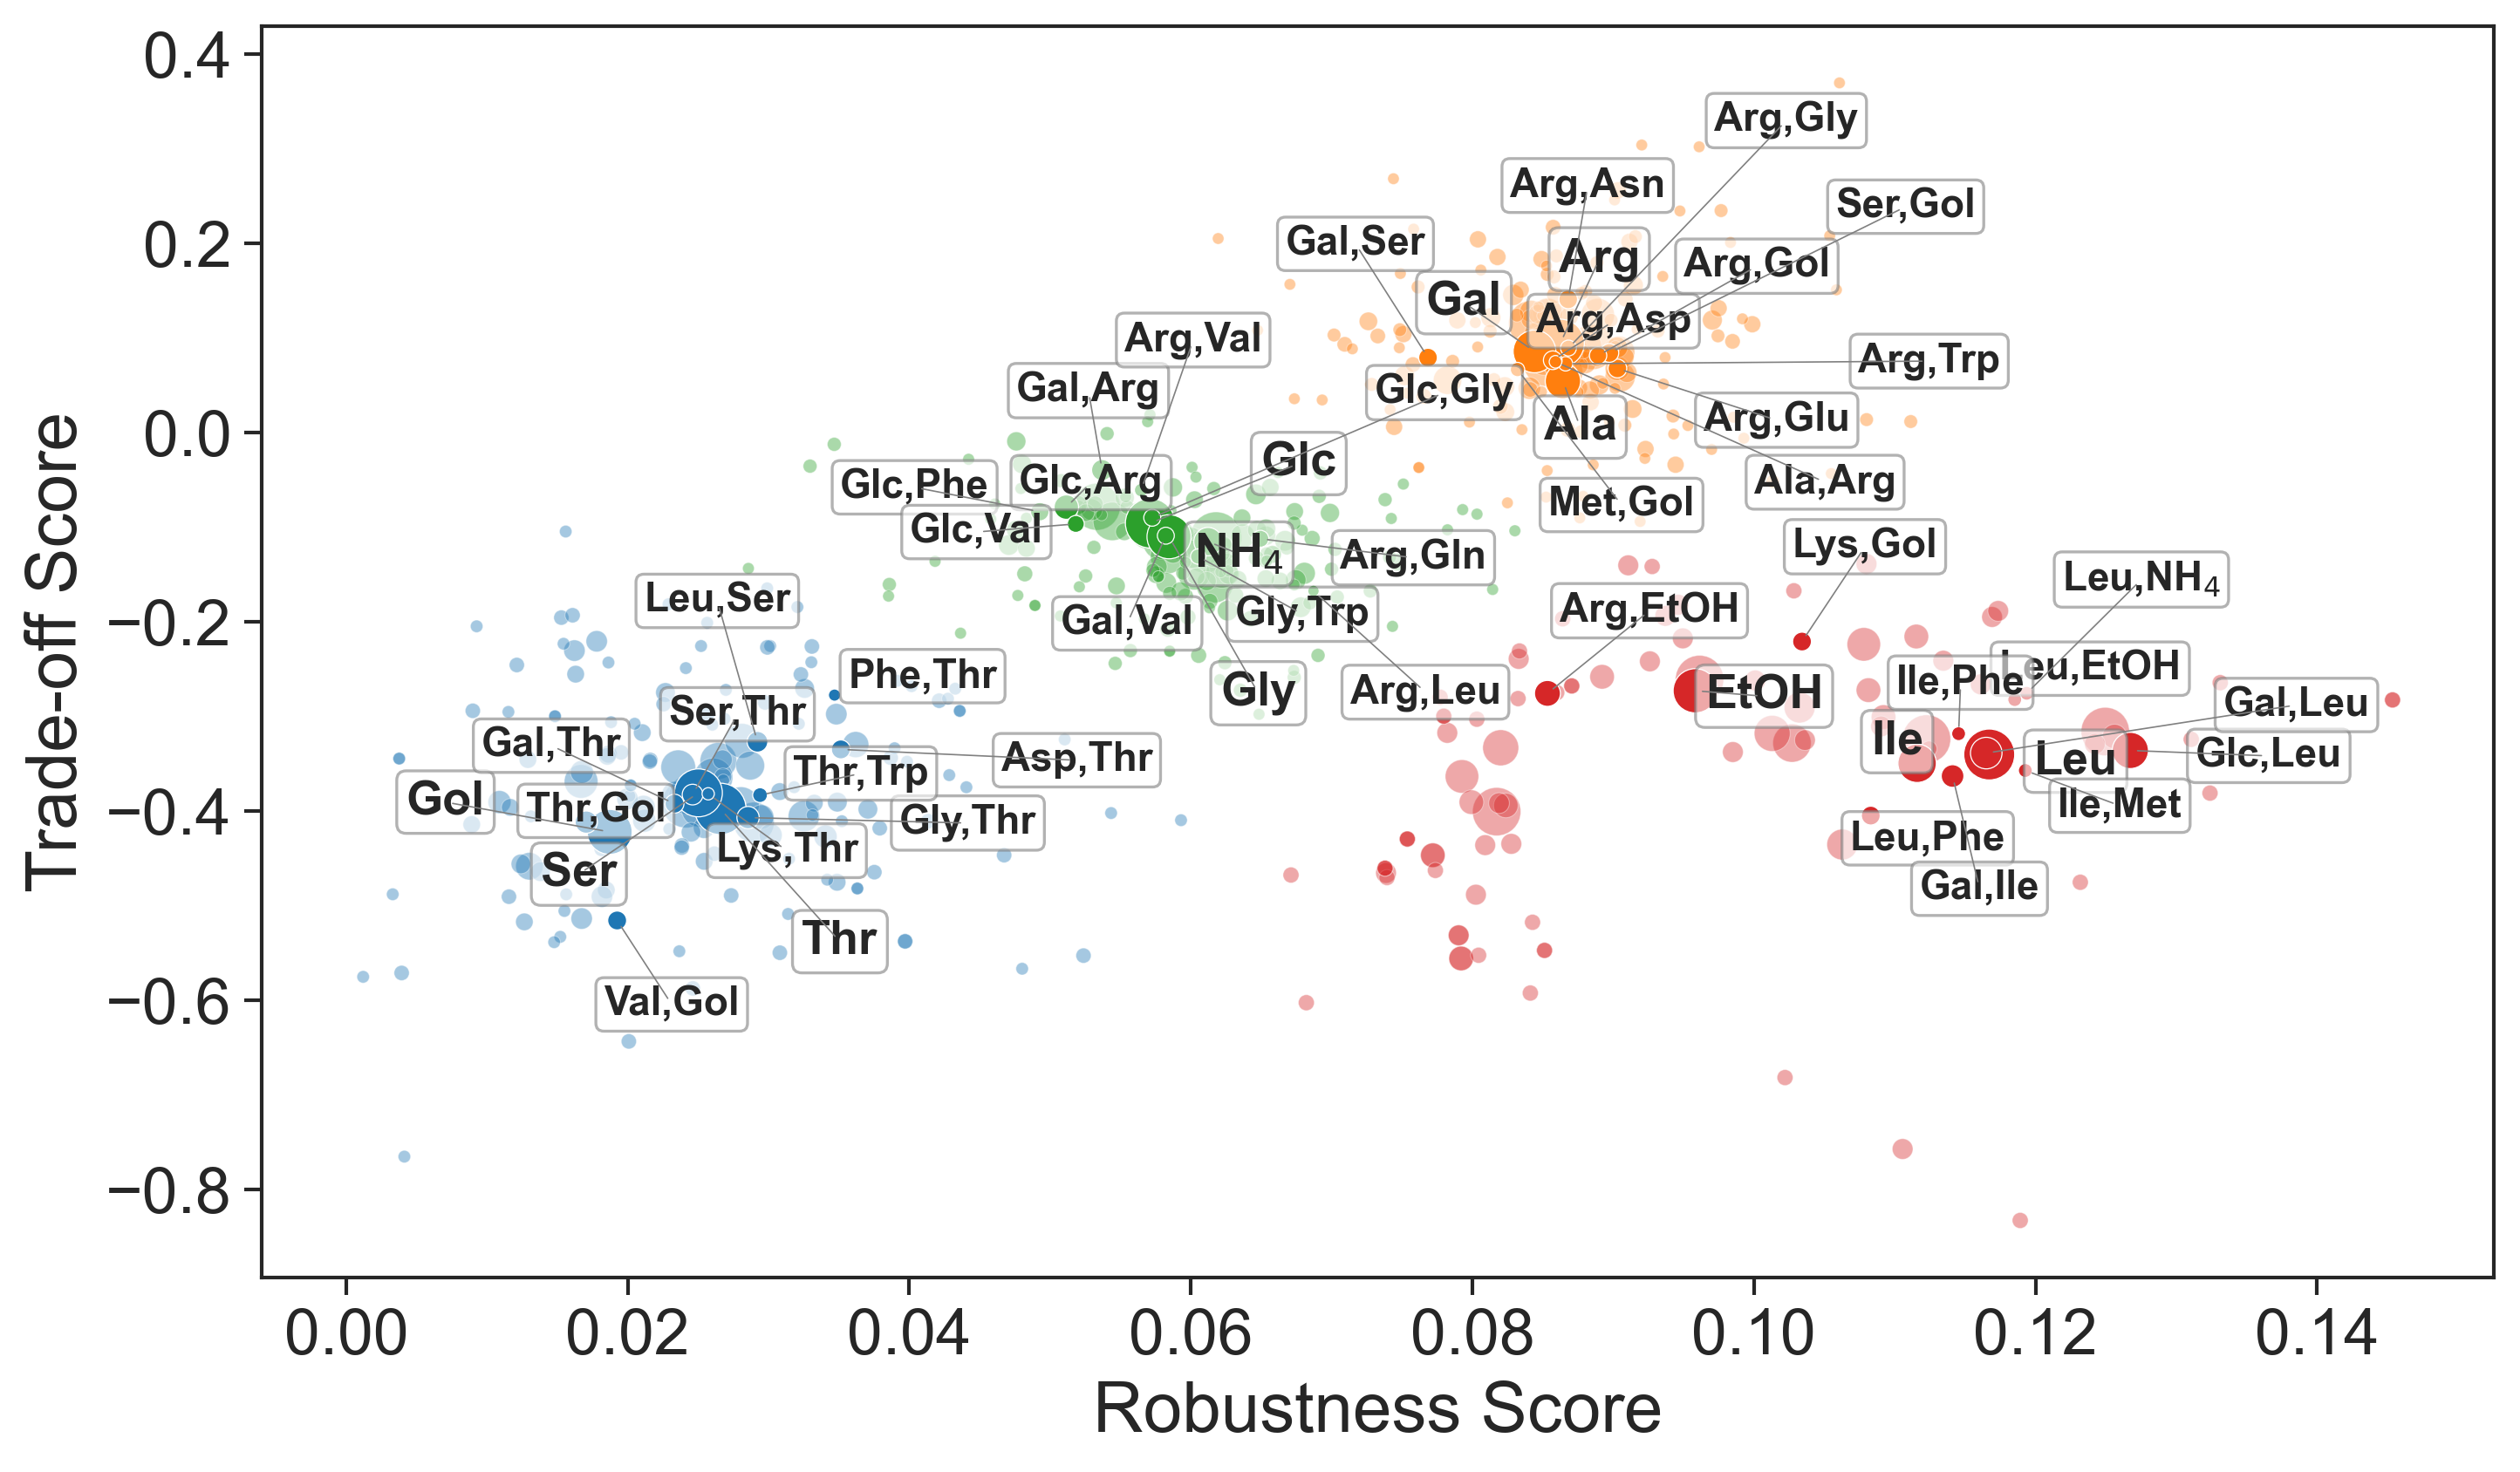

In [17]:
bcha_cluster_result = summarize_favorable_rs_ts_clusters(
    bcha_res_df,
    env_df,
    'BCHA_ana',
    str(AROMATIC_RESULTS_DIR / 'bcha_ana_rs_ts_clusters'),
    str(AROMATIC_RESULTS_DIR),
    n_clusters=4,
    random_state=0,
)


## 2.4 Sensitivity analysis

In [18]:
def prepare_aromatic_sensitivity_summary(target, cluster_result=None, config_path=SENSITIVITY_CONFIG_PATH, base_dir=AROMATIC_SENSITIVITY_DIR):
    config = json.loads(Path(config_path).read_text(encoding='utf-8'))
    aromatic_job = next(job for job in config['jobs'] if job['kind'] == 'aromatic')
    run_specs = pd.DataFrame(aromatic_job['runs']).sort_values(['n_mutations', 'n_samples']).reset_index(drop=True)
    run_specs['custom_tolerance'] = run_specs[['delta', 'epsilon']].notna().any(axis=1)
    run_specs['delta'] = run_specs['delta'].fillna(aromatic_job.get('delta', 1E-2))
    run_specs['epsilon'] = run_specs['epsilon'].fillna(aromatic_job.get('epsilon', 1E-4))
    run_lookup = run_specs.set_index('id')[['n_mutations', 'n_samples', 'delta', 'epsilon', 'custom_tolerance']].to_dict('index')

    summary_df = load_sensitivity(
        facet_value=target,
        base_dir=base_dir,
        subdir_name=target,
        ra_pattern='Env_*_ra_results.csv',
        id_from_path=lambda path: path.stem.replace('_ra_results', ''),
        same_desired_trait=True,
        facet_col='target',
        sort_cols=['target', 'group_id', 'n_mutations', 'n_samples'],
        run_lookup=run_lookup,
    )
    summary_df = summary_df.dropna(subset=['robustness_score', 'tradeoff_score']).copy()
    summary_df = summary_df[~((summary_df['robustness_score'] == 0) & (summary_df['tradeoff_score'] == 0))].copy()

    if cluster_result is None:
        return summary_df

    cluster_map = cluster_result['cluster_df'].set_index('env_id')['rs_ts_cluster']
    assigned_df = summary_df[summary_df['group_id'].isin(cluster_map.index)].copy()
    assigned_df['cluster_id'] = assigned_df['group_id'].map(cluster_map).astype(int)
    trend_df = (
        assigned_df.groupby(['cluster_id', 'run_id', 'n_mutations', 'n_samples', 'delta', 'epsilon', 'custom_tolerance'], as_index=False)
        .agg(
            accepted_count=('accepted_count', 'mean'),
            robustness_score=('robustness_score', 'mean'),
            tradeoff_score=('tradeoff_score', 'mean'),
        )
        .sort_values(['cluster_id', 'n_mutations', 'n_samples', 'run_id'])
        .reset_index(drop=True)
    )
    trend_df['group_id'] = trend_df['cluster_id'].map(lambda x: f'cluster_{int(x)}')
    return trend_df


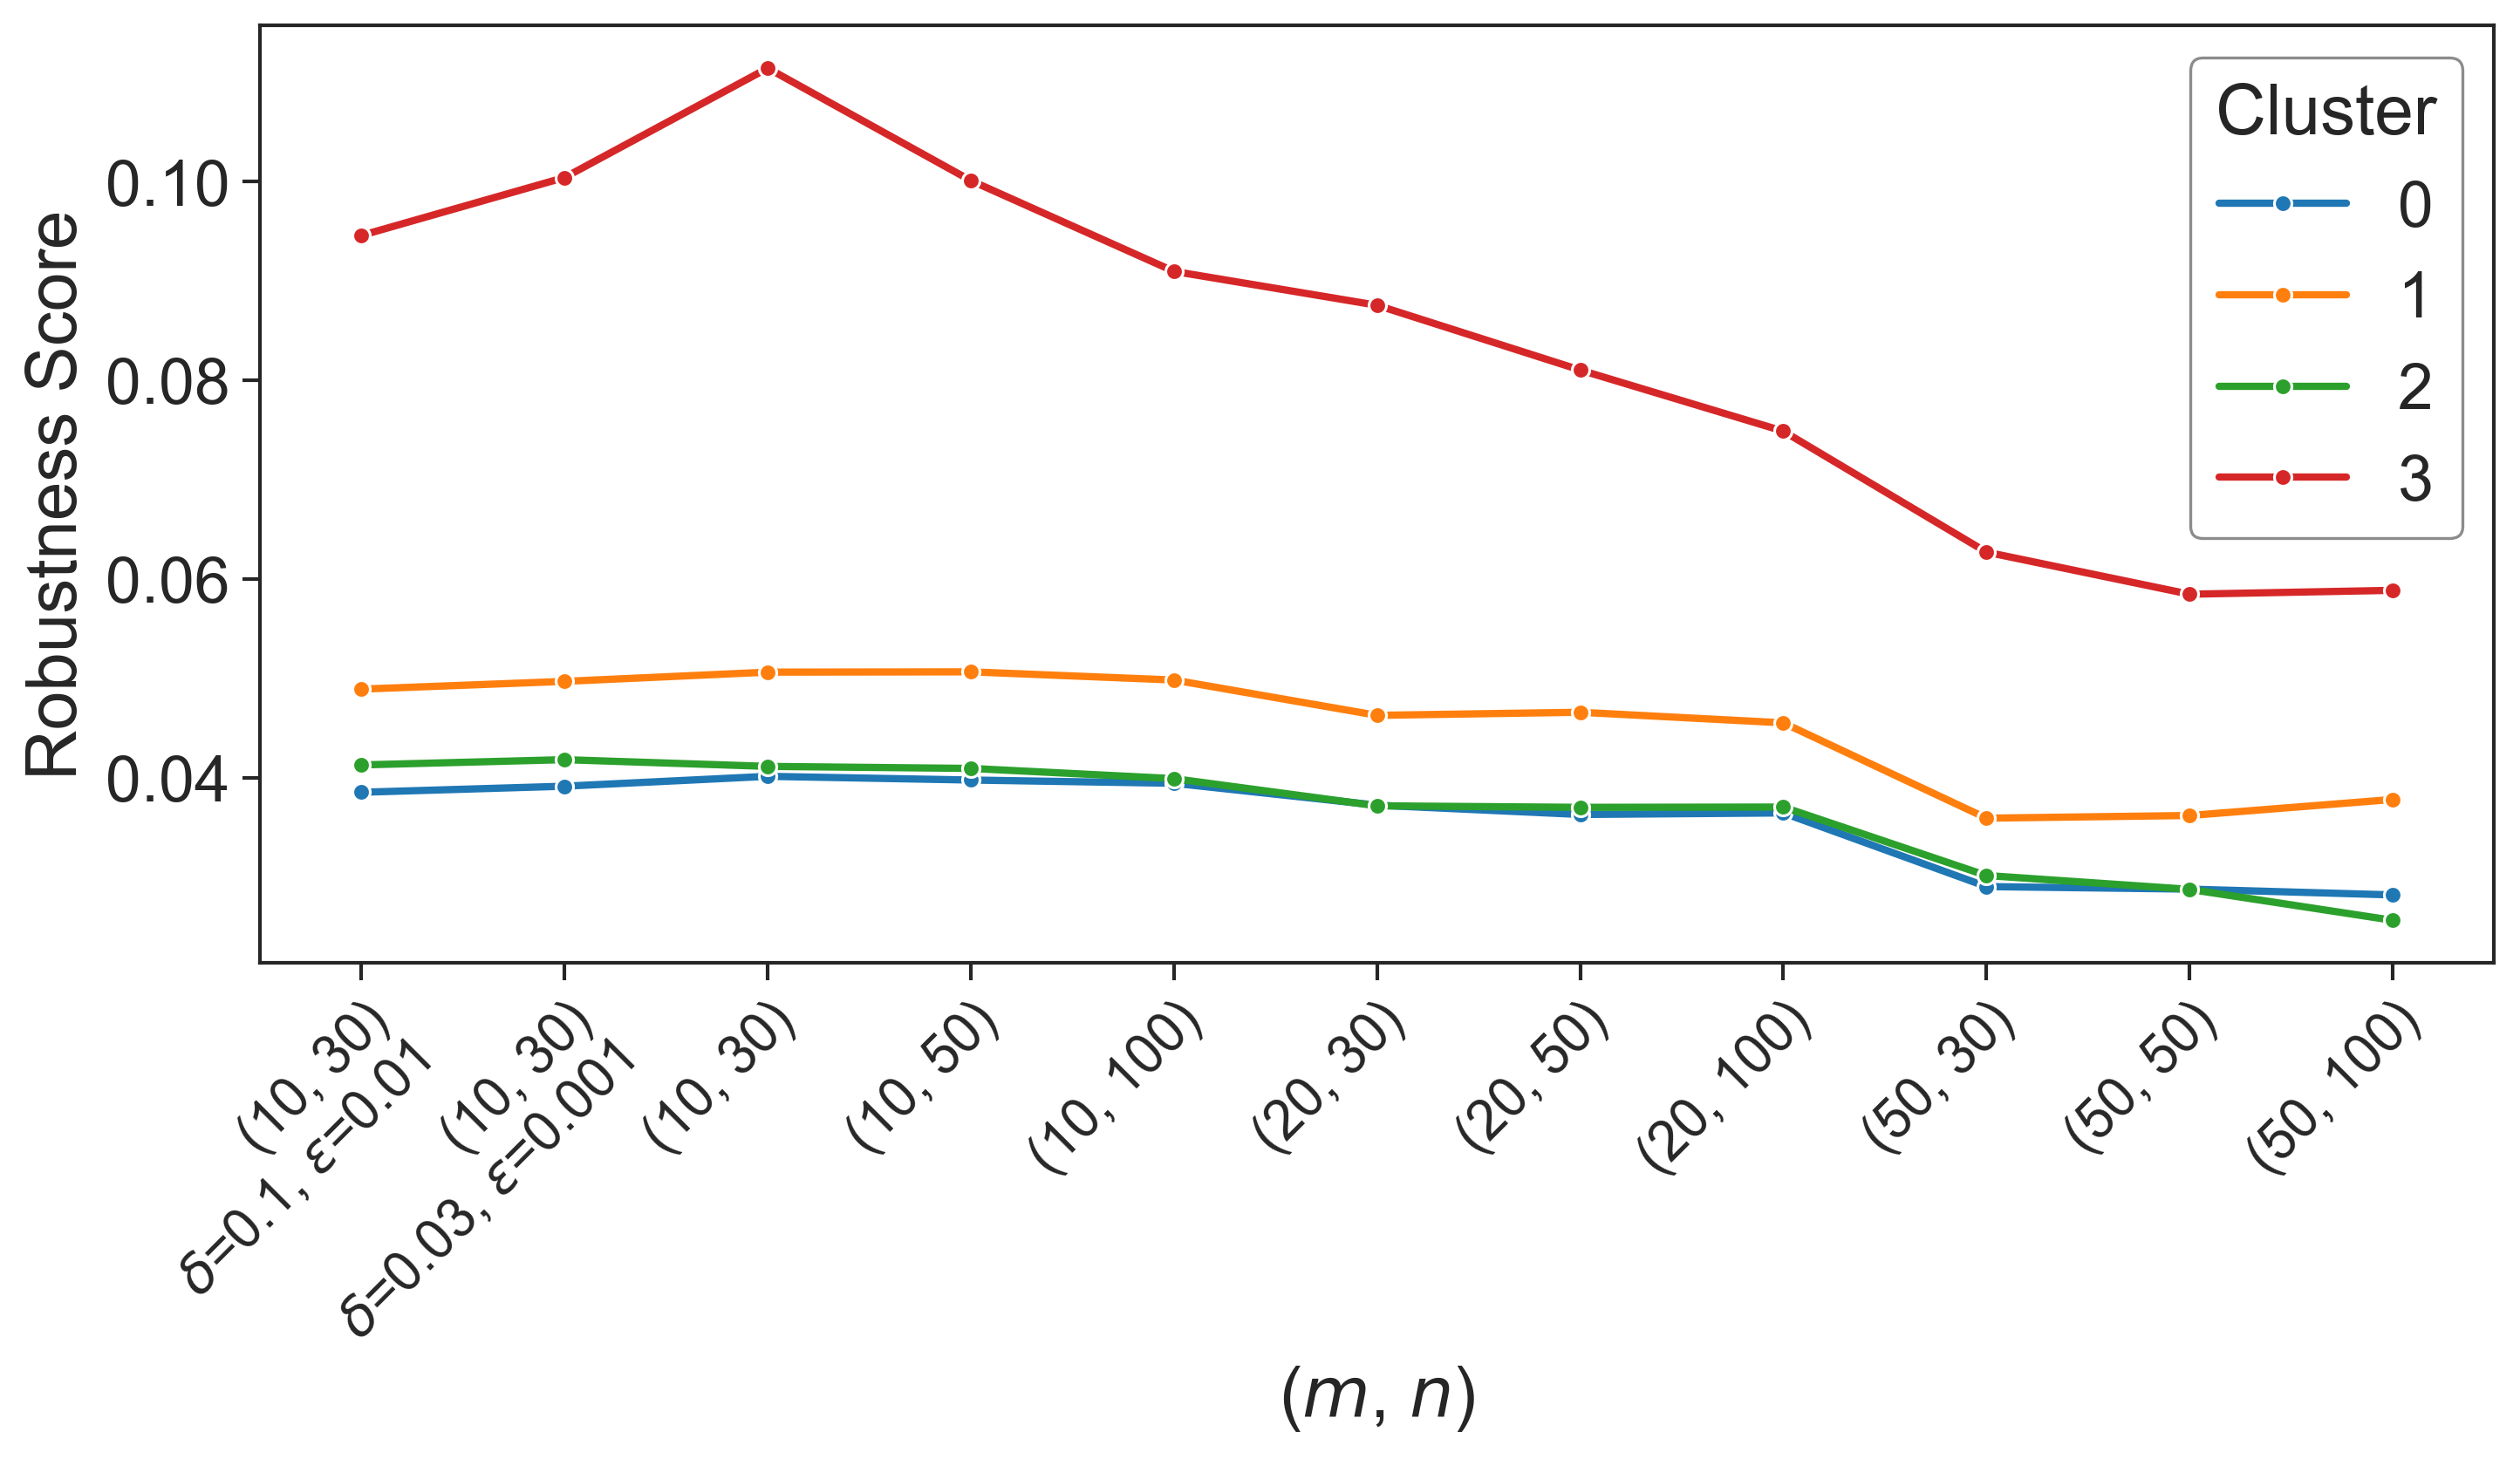

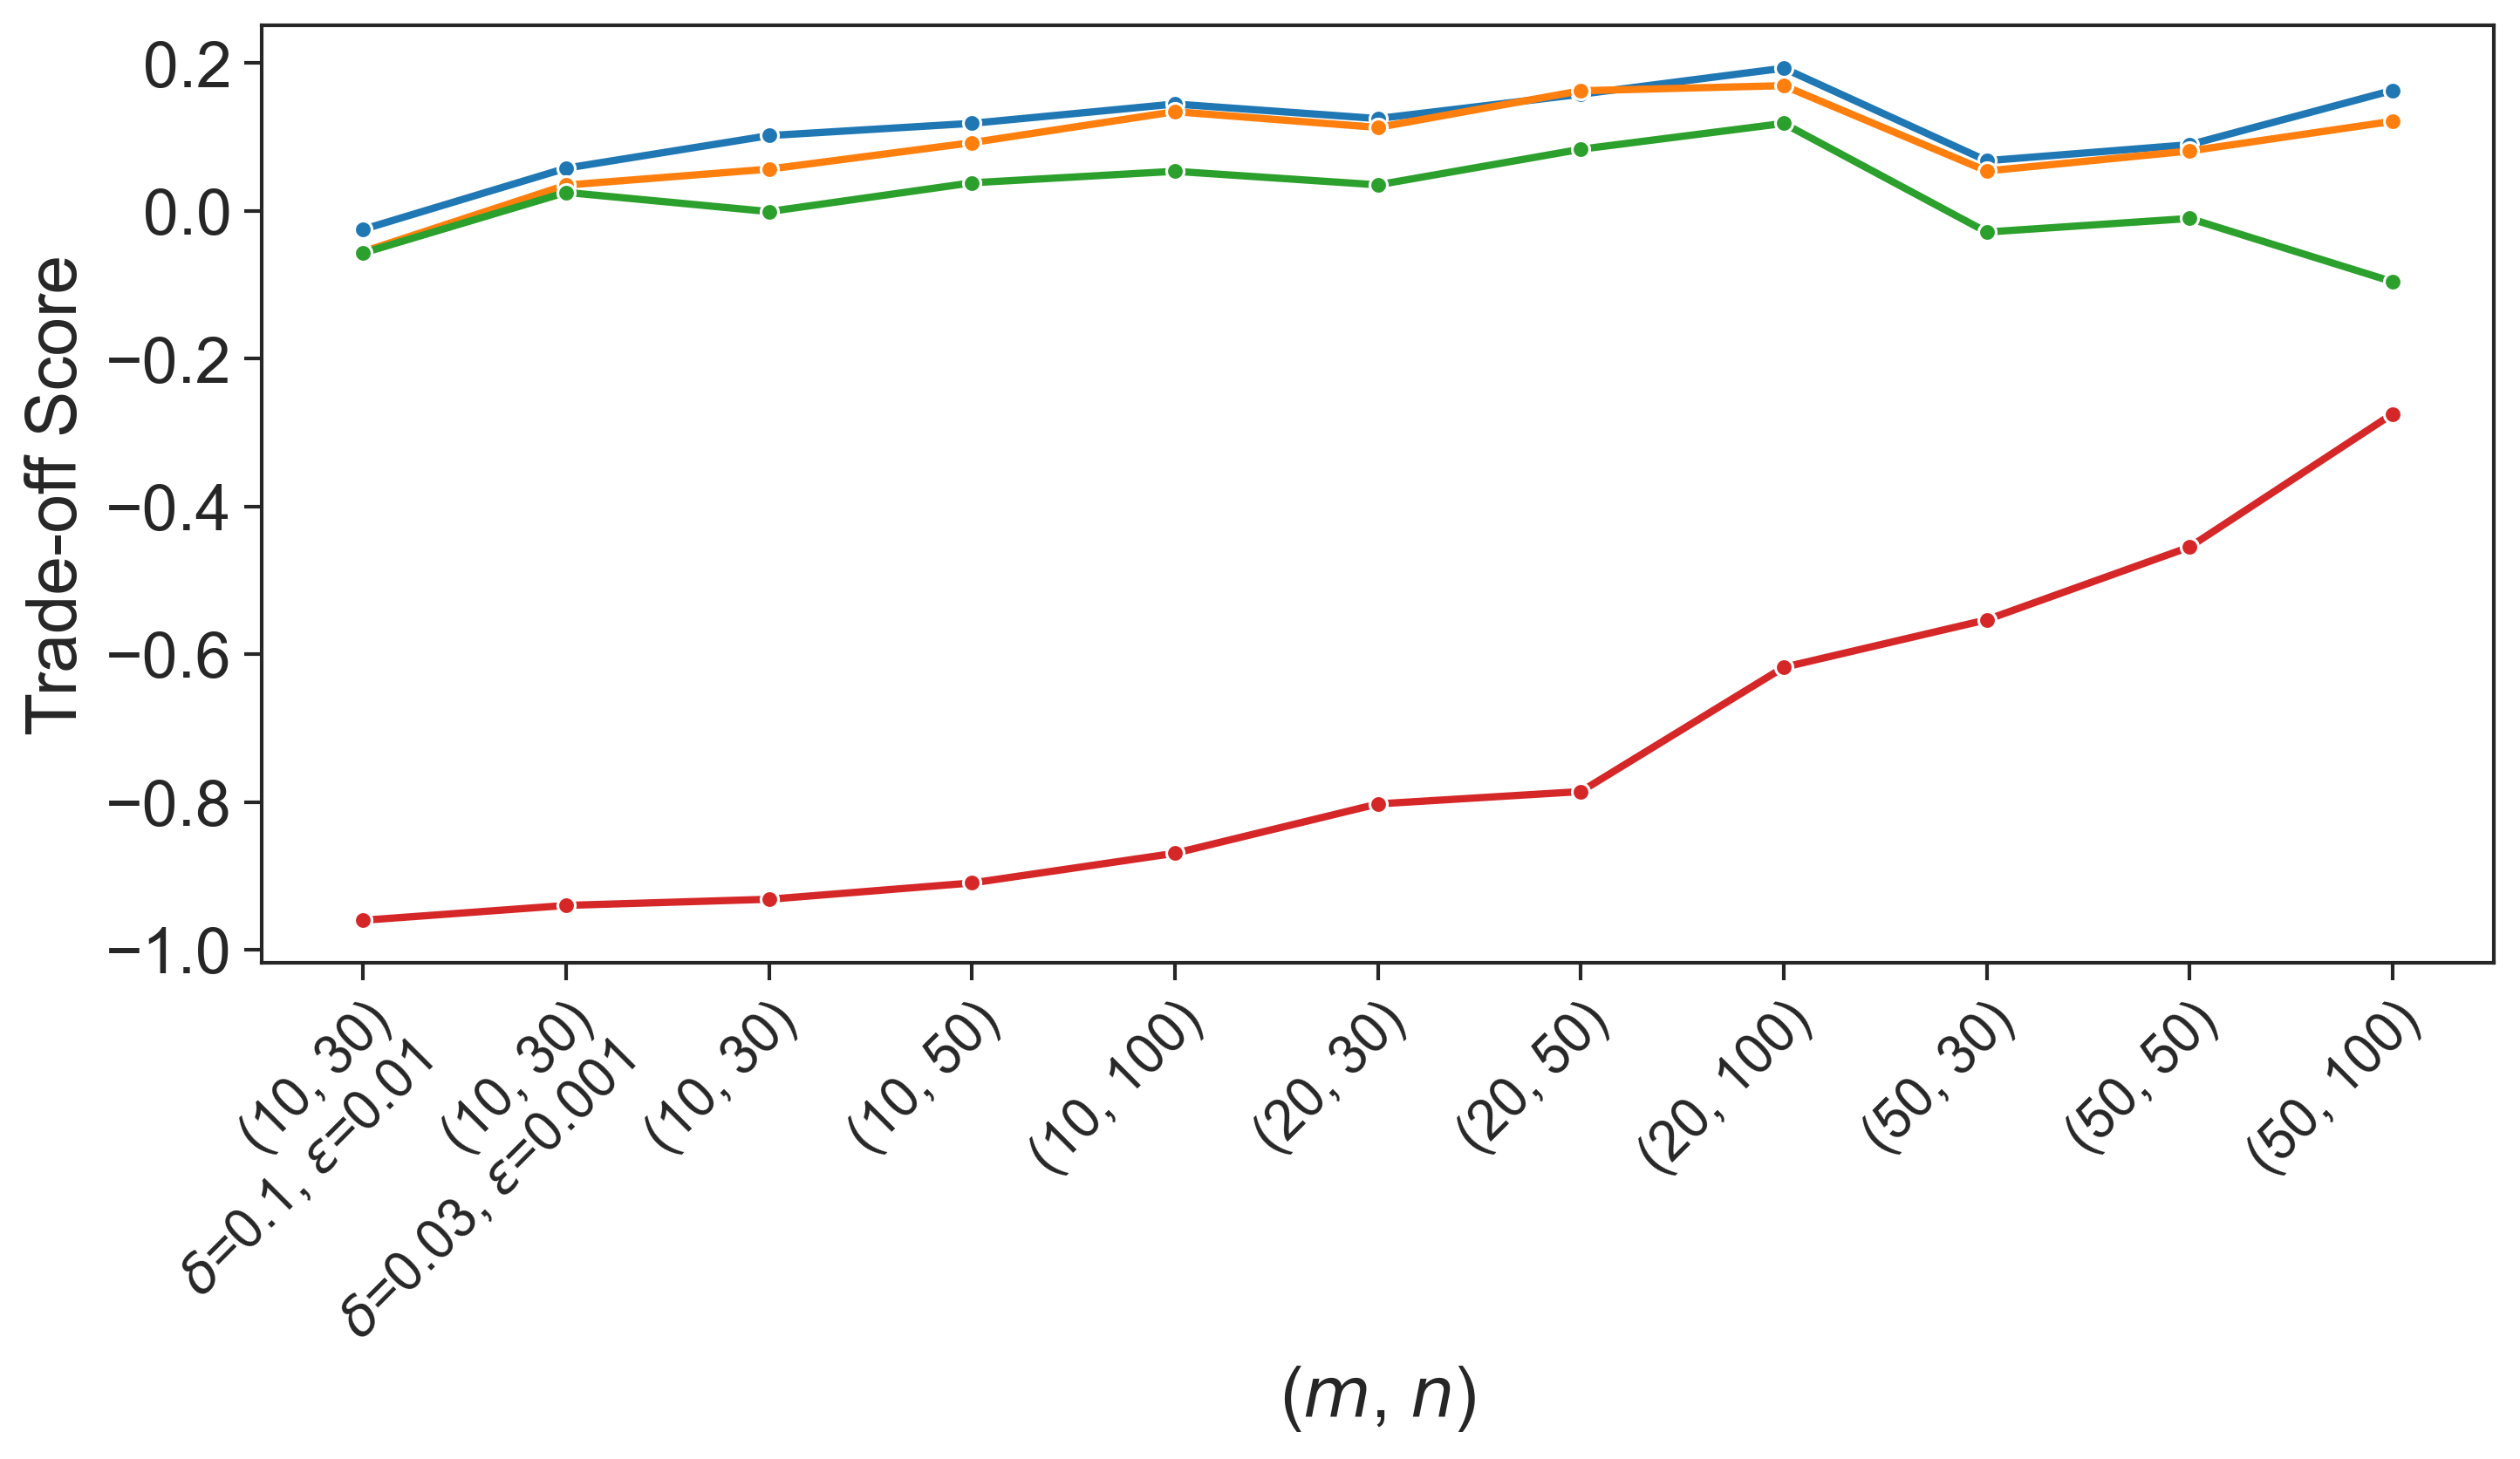

In [19]:
show_sensitivity_results(
    summary_df=prepare_aromatic_sensitivity_summary('PEA_ana', pea_cluster_result, SENSITIVITY_CONFIG_PATH),
    output_dir=AROMATIC_SENSITIVITY_DIR,
    output_prefix='pea_ana',
    group_col='cluster_id',
    legend_title='Cluster',
);


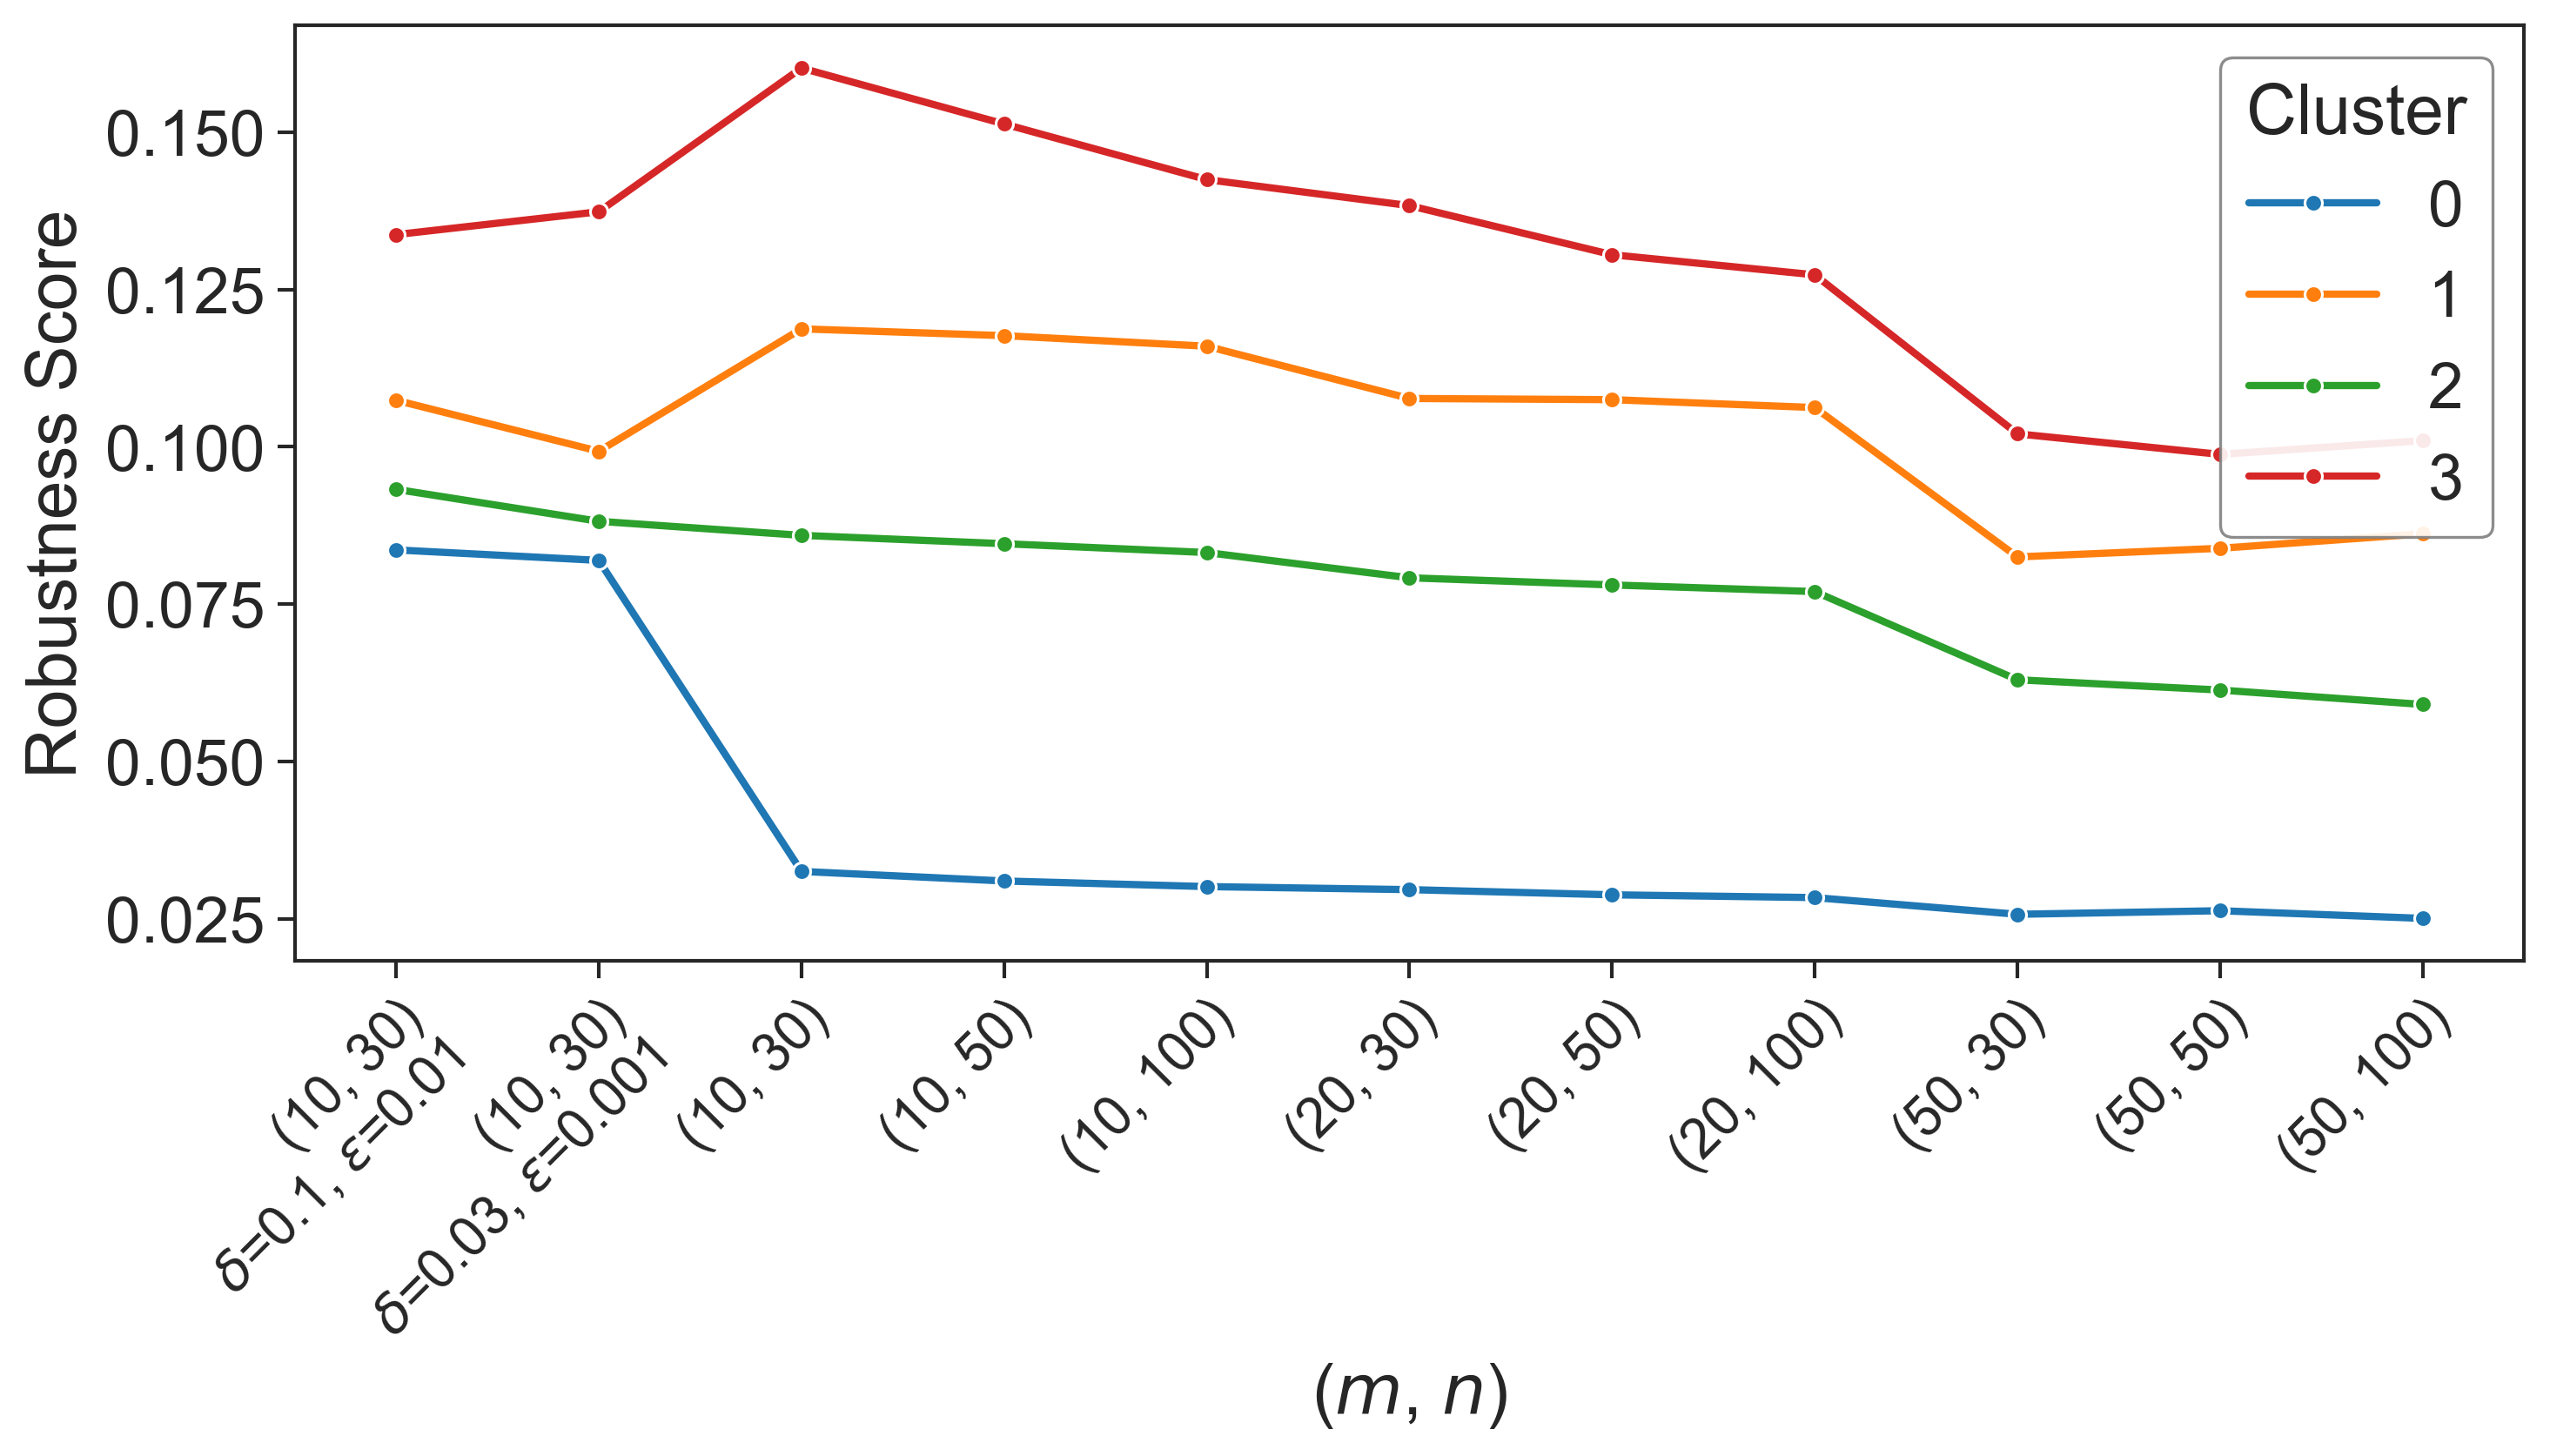

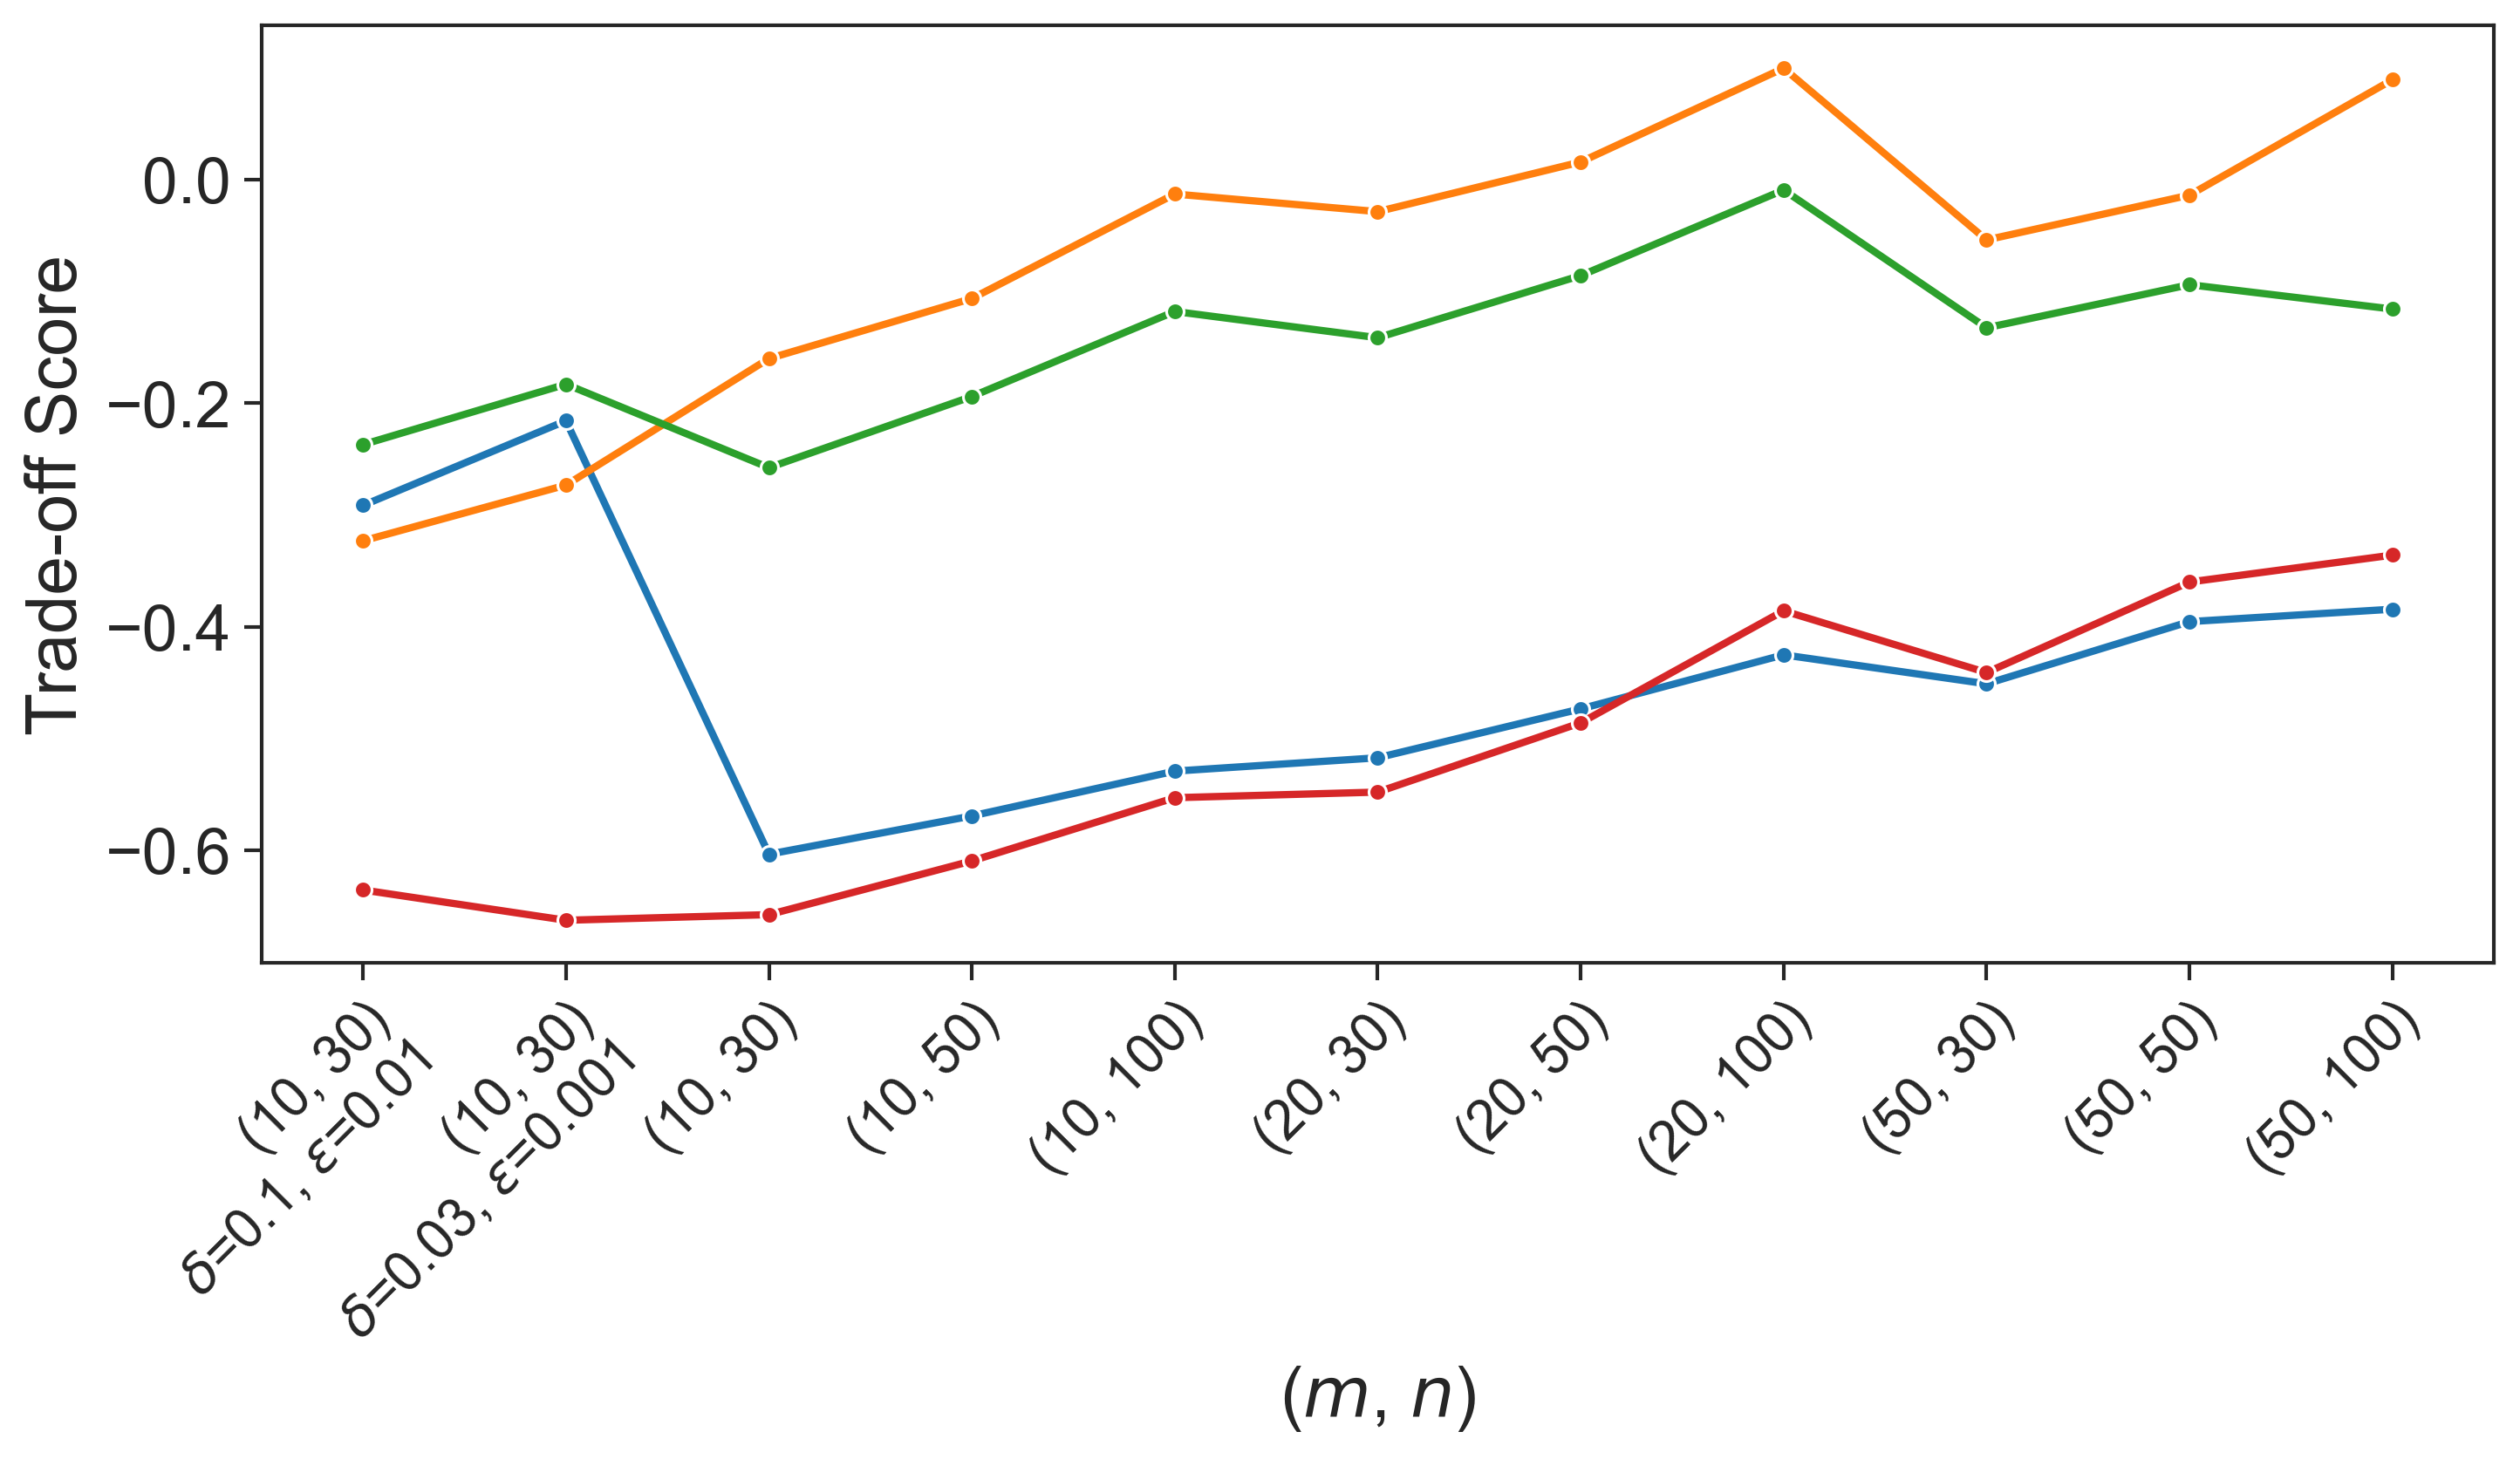

In [20]:
show_sensitivity_results(
    summary_df=prepare_aromatic_sensitivity_summary('BCHA_ana', bcha_cluster_result, SENSITIVITY_CONFIG_PATH),
    output_dir=AROMATIC_SENSITIVITY_DIR,
    output_prefix='bcha_ana',
    group_col='cluster_id',
    legend_title='Cluster',
);
